# COMP 3608 Project Analysis

Organization:

- three datasets
- three algorithms
- feature analysis
- experimental design


### Project setup

The project compares three machine learning approaches across three fraud-related datasets. The comparison focuses on how the models behave under different feature structures, class imbalance levels, and error trade-offs.

The target class is binary in each dataset:

- non-fraud
- fraud

### Algorithms selected

- Logistic Regression
- Random Forest
- XGBoost

### Reason for using these models

The three models give a useful spread of behaviour. Logistic Regression gives a simple baseline, Random Forest gives a bagging-based tree model, and XGBoost gives a boosting-based tree model. That makes it easier to compare a linear model against two nonlinear ensemble methods.

### Datasets used

1. `creditcard.csv`: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data
2. `onlinefraud.csv`: https://www.kaggle.com/datasets/jainilcoder/online-payment-fraud-detection?resource=download
3. `Base.csv`: https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/data?select=Base.csv

The three datasets are treated as separate fraud settings. The same model families are used, but the results are interpreted within the structure of each dataset.


## Imports

In [1]:
import os
import sys
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

from xgboost import XGBClassifier


## Load credit card dataset through KaggleHub

The credit-card dataset is downloaded directly through KaggleHub. The file path returned by KaggleHub is used to locate `creditcard.csv`, so the analysis no longer depends on the earlier zip-file extraction setup.


In [2]:
try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub

# Download latest version of the credit card fraud dataset from Kaggle.
credit_dataset_path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", credit_dataset_path)

# Find creditcard.csv inside the downloaded folder.
credit_card_csv_path = None
for root, dirs, files in os.walk(credit_dataset_path):
    for file_name in files:
        if file_name.lower() == "creditcard.csv":
            credit_card_csv_path = os.path.join(root, file_name)
            break
    if credit_card_csv_path is not None:
        break

if credit_card_csv_path is None:
    raise FileNotFoundError("creditcard.csv was not found in the KaggleHub download folder.")

print("Credit card CSV path:", credit_card_csv_path)


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
Credit card CSV path: /kaggle/input/creditcardfraud/creditcard.csv


## Set dataset paths and target columns


In [3]:
credit_target = "Class"

DATASETS = {
    "Credit Card Fraud": {
        "path": credit_card_csv_path,
        "target": credit_target
    },
    "Online Payment Fraud": {
        "path": None,
        "target": "isFraud"
    },
    "Bank Account Application Fraud": {
        "path": None,
        "target": "fraud_bool"
    }
}

for dataset_name, info in DATASETS.items():
    print(dataset_name, "->", info["path"], "| target =", info["target"])


Credit Card Fraud -> /kaggle/input/creditcardfraud/creditcard.csv | target = Class
Online Payment Fraud -> None | target = isFraud
Bank Account Application Fraud -> None | target = fraud_bool


## Helper Functions

In [4]:
def load_dataset(path):
    if path is None:
        raise ValueError("No file path was provided for this dataset in this notebook.")
    df = pd.read_csv(path)
    return df


def basic_overview(df, dataset_name, target_col):
    print("Dataset:", dataset_name)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(list(df.columns))
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nMissing values per column:")
    display(df.isnull().sum().sort_values(ascending=False).head(15))
    print("\nTarget distribution (counts):")
    display(df[target_col].value_counts(dropna=False))
    print("\nTarget distribution (%):")
    display((df[target_col].value_counts(normalize=True) * 100).round(4))

In [5]:
def plot_class_distribution(df, target_col, dataset_name):
    counts = df[target_col].value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

In [6]:
def get_feature_lists(df, target_col):
    X = df.drop(columns=[target_col])
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
    return numeric_cols, categorical_cols

In [7]:
def plot_top_numeric_correlations(df, target_col, dataset_name, top_n=10):
    numeric_df = df.select_dtypes(include=["number"]).copy()
    if target_col not in numeric_df.columns:
        print("Target is not numeric, correlation plot skipped.")
        return

    corr = numeric_df.corr(numeric_only=True)[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
    top_corr = corr.head(top_n)

    if len(top_corr) == 0:
        print("No numeric features available for correlation plot.")
        return

    plt.figure(figsize=(8, 5))
    top_corr.sort_values().plot(kind="barh")
    plt.title(f"{dataset_name} - Top Numeric Features by Correlation with {target_col}")
    plt.xlabel("Correlation")
    plt.ylabel("Feature")
    plt.show()

    display(top_corr.to_frame("correlation_with_target"))

In [8]:
def plot_top_skewed_features(df, target_col, dataset_name, top_n=8):
    numeric_df = df.select_dtypes(include=["number"]).drop(columns=[target_col], errors="ignore")
    if numeric_df.shape[1] == 0:
        print("No numeric features available for skew analysis.")
        return

    skewness = numeric_df.skew(numeric_only=True).sort_values(key=np.abs, ascending=False)
    top_skew = skewness.head(top_n)

    plt.figure(figsize=(8, 5))
    top_skew.sort_values().plot(kind="barh")
    plt.title(f"{dataset_name} - Most Skewed Numeric Features")
    plt.xlabel("Skewness")
    plt.ylabel("Feature")
    plt.show()

    display(top_skew.to_frame("skewness"))

In [9]:
def plot_numeric_feature_by_class(df, target_col, dataset_name, feature_name):
    if feature_name not in df.columns:
        print("Feature not found:", feature_name)
        return

    clean_df = df[[feature_name, target_col]].dropna().copy()
    classes = sorted(clean_df[target_col].unique())

    plt.figure(figsize=(8, 4))
    for class_value in classes:
        series = clean_df.loc[clean_df[target_col] == class_value, feature_name]
        plt.hist(series, bins=40, alpha=0.5, label=f"class={class_value}")
    plt.title(f"{dataset_name} - Distribution of {feature_name} by Class")
    plt.xlabel(feature_name)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [10]:
def show_top_categorical_fraud_rates(df, target_col, dataset_name, top_n=10):
    categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

    if len(categorical_cols) == 0:
        print("No categorical features available.")
        return

    for col in categorical_cols[:5]:
        print(f"\n{dataset_name} - Fraud rate by {col}")
        temp = df.groupby(col)[target_col].mean().sort_values(ascending=False).head(top_n)
        display(temp.to_frame("fraud_rate"))
        plt.figure(figsize=(8, 4))
        temp.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - Top Fraud Rates by {col}")
        plt.xlabel("Fraud rate")
        plt.ylabel(col)
        plt.show()

In [11]:
def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    X_processed = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    return X_processed, numeric_cols, categorical_cols

In [12]:
def preprocess_for_model(df, target_col):
    df = df.copy()

    X = df.drop(columns=[target_col])
    y = df[target_col]

    # simple one-hot encoding for categorical columns
    X = pd.get_dummies(X, drop_first=True)

    # fill missing numeric values with median
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    numeric_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()

    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    return X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test

In [13]:
def get_models():
    models = {}

    models["Logistic Regression"] = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    models["Random Forest"] = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    models["XGBoost"] = XGBClassifier(
          n_estimators=200,
          max_depth=6,
          learning_rate=0.1,
          subsample=0.8,
          colsample_bytree=0.8,
          eval_metric="logloss",
          random_state=42
    )


    return models

In [14]:
def train_and_evaluate_models(X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, dataset_name):
    models = get_models()
    rows = []
    fitted_models = {}

    for model_name, model in models.items():
        if model_name == "Logistic Regression":
            train_X = X_train_scaled
            test_X = X_test_scaled
        else:
            train_X = X_train
            test_X = X_test

        model.fit(train_X, y_train)

        y_pred = model.predict(test_X)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(test_X)[:, 1]
        else:
            y_prob = None

        result = {
            "dataset": dataset_name,
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
        }

        rows.append(result)
        fitted_models[model_name] = {
            "model": model,
            "y_pred": y_pred,
            "y_prob": y_prob
        }

    results_df = pd.DataFrame(rows).sort_values(by="f1", ascending=False)
    return results_df, fitted_models

In [15]:
def plot_confusion_matrices(fitted_models, X_test, X_test_scaled, y_test, dataset_name):
    for model_name, obj in fitted_models.items():
        model = obj["model"]
        y_pred = obj["y_pred"]

        plt.figure(figsize=(5, 4))
        disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
        disp.plot()
        plt.title(f"{dataset_name} - {model_name} Confusion Matrix")
        plt.show()

In [16]:
def plot_feature_importance(model, feature_names, dataset_name, model_name, top_n=15):
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
        plt.figure(figsize=(8, 5))
        importances.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - {model_name} Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()
        display(importances.to_frame("importance"))

    elif hasattr(model, "coef_"):
        coef = pd.Series(model.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False).head(top_n)
        plt.figure(figsize=(8, 5))
        coef.sort_values().plot(kind="barh")
        plt.title(f"{dataset_name} - {model_name} Largest Logistic Coefficients")
        plt.xlabel("Coefficient")
        plt.ylabel("Feature")
        plt.show()
        display(coef.to_frame("coefficient"))

    else:
        print("Feature importance not available for", model_name)

# Preliminary Run

## Evaluating dataset 1: Credit Card Fraud Dataset

The Credit Card Fraud dataset consists primarily of anonymized numerical features labeled V1 through V28, along with additional variables including Time, Amount, and a binary target variable Class indicating fraudulent or non-fraudulent transactions. The values and features had been anonimized and tranformed.
Most features are already in a numeric format, which reduces the need for extensive preprocessing such as encoding categorical variables. However, the dataset is highly imbalanced, with fraudulent transactions representing a very small proportion of the total observations. As a result, standard evaluation metrics such as accuracy are not sufficient for assessing model performance. Instead, metrics such as recall and F1-score are more appropriate, as they better capture the model's ability to correctly identify fraudulent cases while accounting for the imbalance in class distribution.

Dataset: Credit Card Fraud
Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values per column:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0



Target distribution (counts):


,count
Class,
0,284315
1,492



Target distribution (%):


,proportion
Class,
0,99.8273
1,0.1727


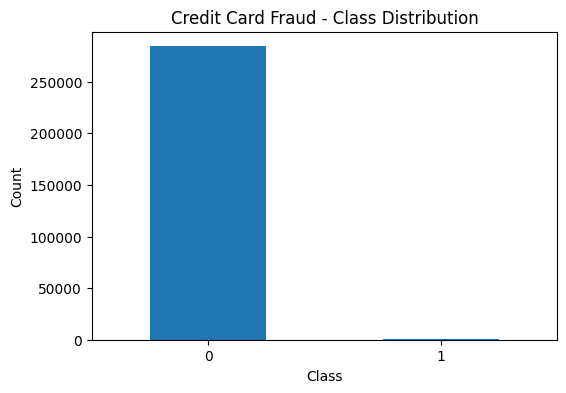

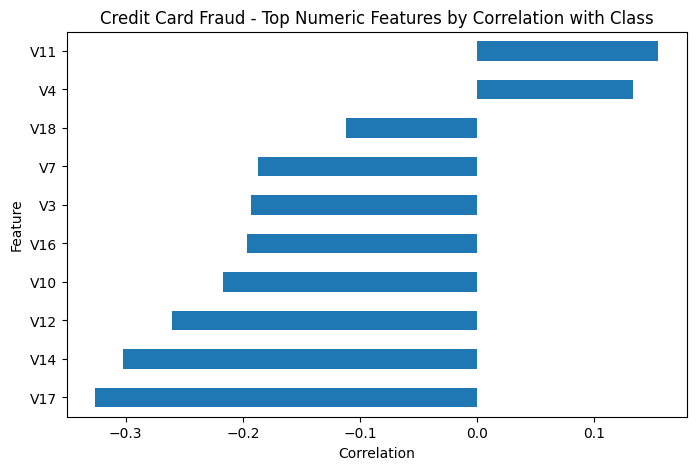

,correlation_with_target
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


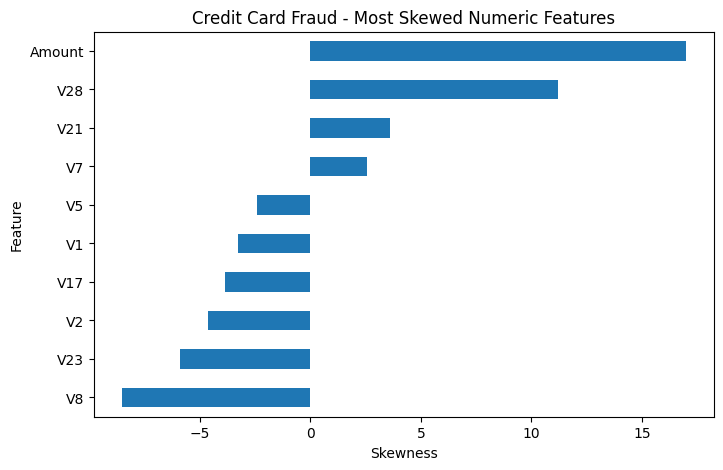

,skewness
Amount,16.977724
V28,11.192091
V8,-8.521944
V23,-5.875140
V2,-4.624866
V17,-3.844914
V21,3.592991
V1,-3.280667
V7,2.553907
V5,-2.425901


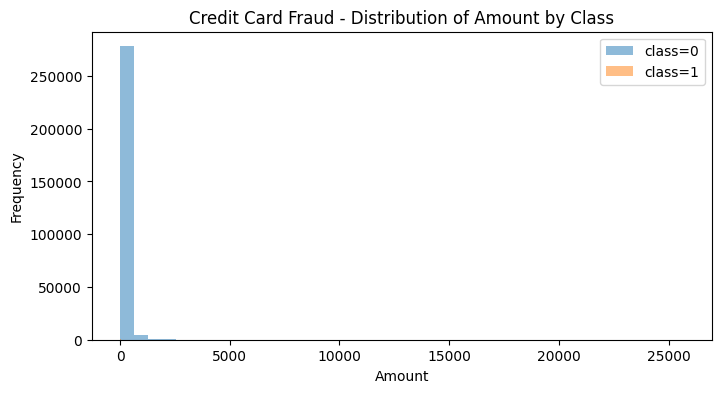

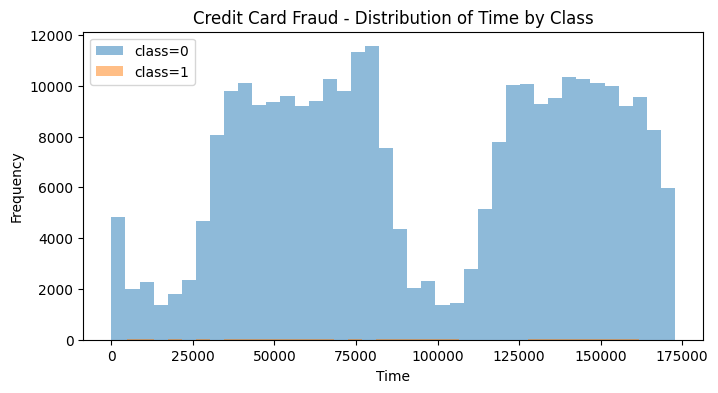

In [17]:
credit_info = DATASETS["Credit Card Fraud"]
credit_df = load_dataset(credit_info["path"])
basic_overview(credit_df, "Credit Card Fraud", credit_info["target"])
plot_class_distribution(credit_df, credit_info["target"], "Credit Card Fraud")
plot_top_numeric_correlations(credit_df, credit_info["target"], "Credit Card Fraud", top_n=10)
plot_top_skewed_features(credit_df, credit_info["target"], "Credit Card Fraud", top_n=10)
plot_numeric_feature_by_class(credit_df, credit_info["target"], "Credit Card Fraud", "Amount")
plot_numeric_feature_by_class(credit_df, credit_info["target"], "Credit Card Fraud", "Time")

### Credit Card Fraud Dataset Interpretation

Fraud transactions are extremely rare compared with normal transactions. That imbalance makes accuracy a weak measure because a model can predict almost everything as non-fraud and still look accurate. The analysis therefore needs to pay more attention to recall, precision, F1/F2, false negatives, and false positives.

`Amount` is strongly right-skewed. Most transactions are small, while a small number of transactions are much larger. That supports using log-scale views during EDA, although the original amount is still kept because it carries transaction-size information.

`Time` does not separate fraud cleanly by itself. Fraud and non-fraud transactions appear across similar time ranges, so time is better treated as a supporting feature rather than a main fraud indicator.

The strongest early class relationships come from anonymized `V` features such as `V17`, `V14`, `V12`, `V10`, `V16`, `V11`, and `V4`. Since those variables are anonymized, their business meaning cannot be explained directly, but their statistical separation still matters for modelling.


,dataset,model,accuracy,precision,recall,f1,roc_auc
2,Credit Card Fraud,XGBoost,0.999561,0.901099,0.836735,0.867725,0.977750
1,Credit Card Fraud,Random Forest,0.999526,0.961039,0.755102,0.845714,0.957189
0,Credit Card Fraud,Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972083


<Figure size 500x400 with 0 Axes>

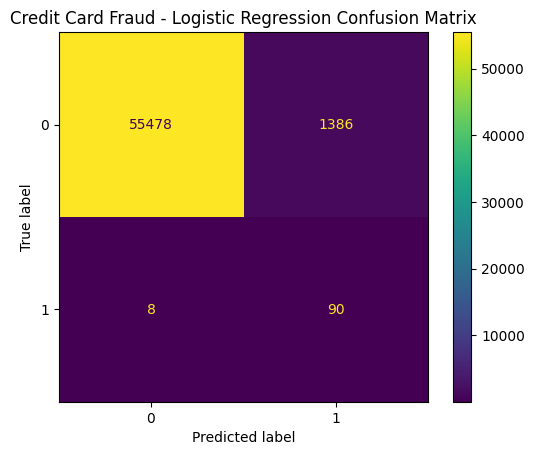

<Figure size 500x400 with 0 Axes>

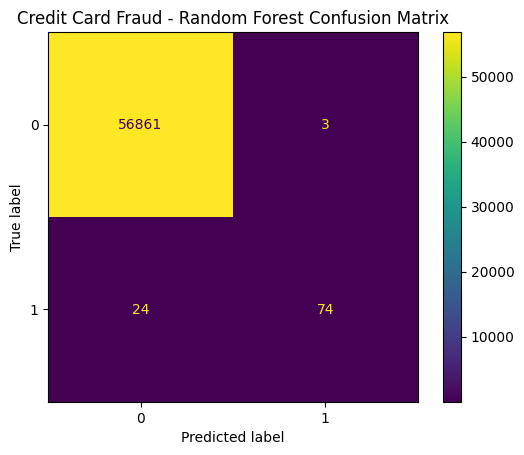

<Figure size 500x400 with 0 Axes>

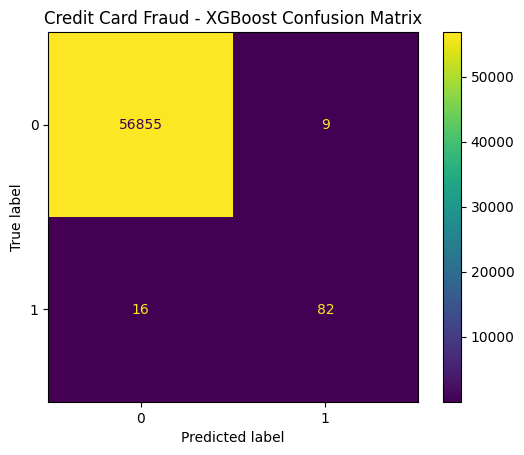

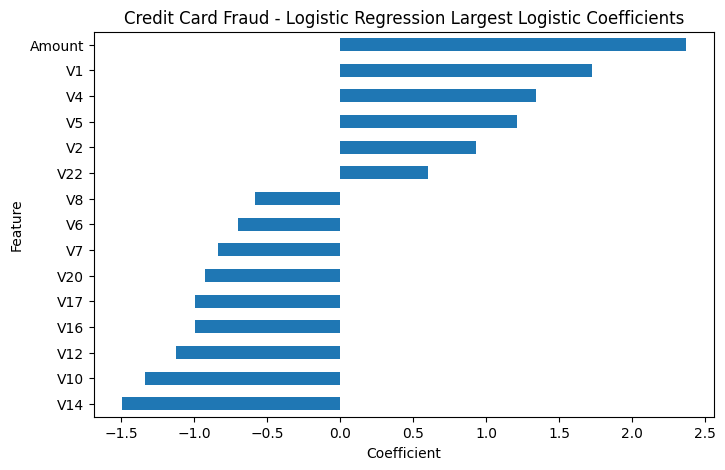

,coefficient
Amount,2.367276
V1,1.723862
V14,-1.494961
V4,1.339431
V10,-1.334996
V5,1.214379
V12,-1.127886
V16,-0.996376
V17,-0.992185
V2,0.932075


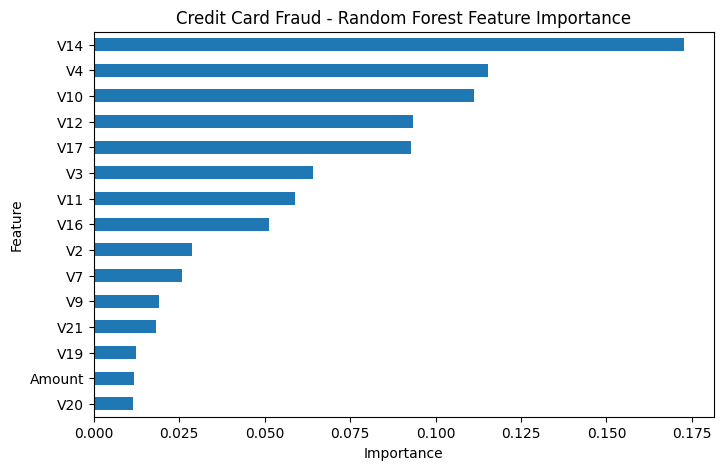

,importance
V14,0.172755
V4,0.115382
V10,0.111231
V12,0.093417
V17,0.092719
V3,0.064234
V11,0.058795
V16,0.051311
V2,0.028824
V7,0.025840


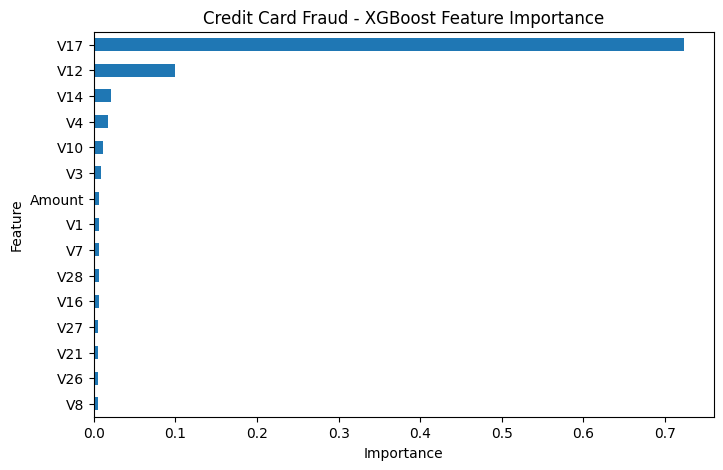

,importance
V17,0.723470
V12,0.098951
V14,0.021419
V4,0.017404
V10,0.011156
V3,0.008372
Amount,0.006742
V1,0.006711
V7,0.006553
V28,0.006461


In [18]:
X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = preprocess_for_model(credit_df, credit_info["target"])
credit_results, credit_models = train_and_evaluate_models(
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, "Credit Card Fraud"
)
display(credit_results)
plot_confusion_matrices(credit_models, X_test, X_test_scaled, y_test, "Credit Card Fraud")

for model_name, obj in credit_models.items():
    plot_feature_importance(obj["model"], X_train.columns, "Credit Card Fraud", model_name, top_n=15)

### Credit Card Fraud Model Evaluation

The first model comparison shows different types of behaviour. Logistic Regression catches the most fraud cases, but it also creates a very large number of false positives. Random Forest is much stricter. It has very high precision, but it misses more fraud. XGBoost gives the strongest middle ground in the first comparison, with high precision and better recall than Random Forest.

Accuracy is not a good deciding metric here because the dataset is heavily imbalanced. The large number of true negatives can make all models look strong even when the fraud class is not handled well. The more useful comparison is between recall, precision, false positives, and false negatives.

The early result already shows the main trade-off in the project. A loose model catches more fraud but flags too many normal transactions. A strict model keeps false positives low but misses more fraud. The later threshold and cost-based sections use that trade-off directly.


#

# After Preliminary Run

## 1. Credit Card Fraud Dataset

### 1.1 Credit Card Fraud Dataset Overview


Dataset: Credit Card Fraud
Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values per column:


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0



Target distribution (counts):


,count
Class,
0,284315
1,492



Target distribution (%):


,proportion
Class,
0,99.8273
1,0.1727


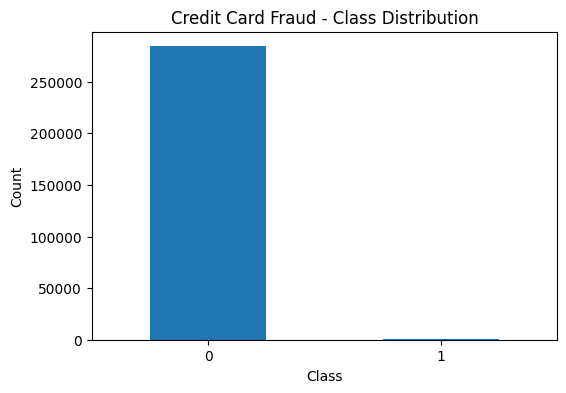

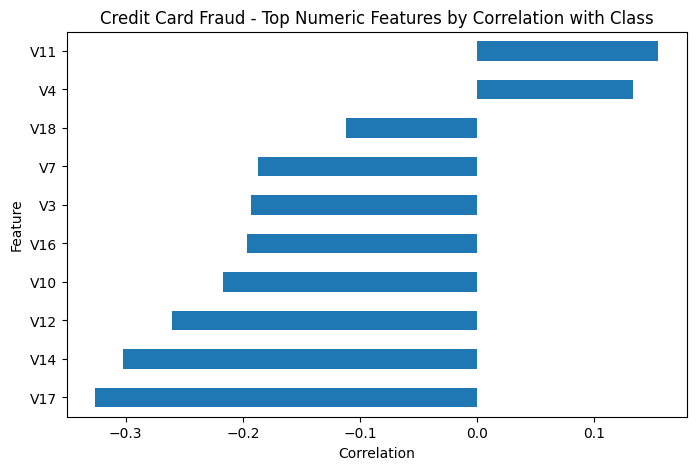

,correlation_with_target
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


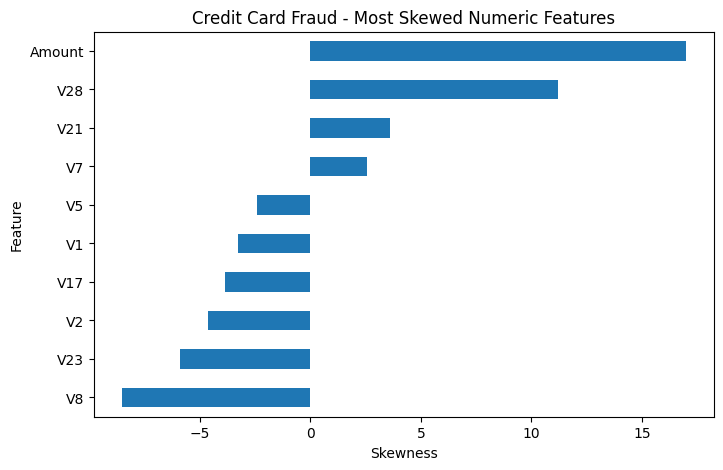

,skewness
Amount,16.977724
V28,11.192091
V8,-8.521944
V23,-5.875140
V2,-4.624866
V17,-3.844914
V21,3.592991
V1,-3.280667
V7,2.553907
V5,-2.425901


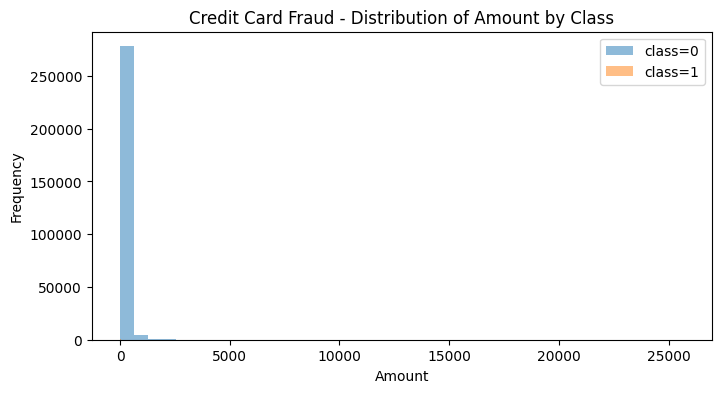

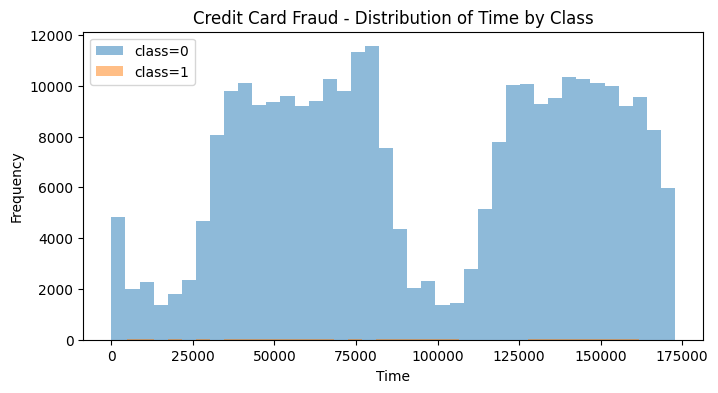

In [19]:
credit_info = DATASETS["Credit Card Fraud"]
credit_df = load_dataset(credit_info["path"])
basic_overview(credit_df, "Credit Card Fraud", credit_info["target"])
plot_class_distribution(credit_df, credit_info["target"], "Credit Card Fraud")
plot_top_numeric_correlations(credit_df, credit_info["target"], "Credit Card Fraud", top_n=10)
plot_top_skewed_features(credit_df, credit_info["target"], "Credit Card Fraud", top_n=10)
plot_numeric_feature_by_class(credit_df, credit_info["target"], "Credit Card Fraud", "Amount")
plot_numeric_feature_by_class(credit_df, credit_info["target"], "Credit Card Fraud", "Time")

### 1.2 Credit Card Fraud Data Quality Checks

The baseline analysis gave the first look at shape, column names, missing values, and target counts. Now, the checks below focus on issues that could affect the models later, mainly duplicate rows, invalid values, zero-amount transactions, scale differences, and low-variation columns. The checks give a clearer view of whether the data needs cleaning before modelling.

In [20]:
# Set target and feature variables for this dataset
credit_target = credit_info["target"]
credit_features = credit_df.drop(columns=[credit_target])
credit_numeric = credit_df.select_dtypes(include=[np.number])

print("Target column:", credit_target)
print("Number of feature columns:", credit_features.shape[1])
print("Number of numeric columns:", credit_numeric.shape[1])

Target column: Class
Number of feature columns: 30
Number of numeric columns: 31


#### 1.2.1 Duplicate row check

Duplicate rows need careful handling because repeated-looking transactions are not automatically errors. They may also represent repeated transaction behaviour.


In [21]:
# Check duplicate rows
duplicate_count = credit_df.duplicated().sum()
duplicate_rate = duplicate_count / len(credit_df) * 100

print("Duplicate rows:", duplicate_count)
print(f"Duplicate row percentage: {duplicate_rate:.4f}%")

print("\nDuplicate rows by class:")
display(credit_df[credit_df.duplicated()][credit_target].value_counts())

Duplicate rows: 1081
Duplicate row percentage: 0.3796%

Duplicate rows by class:


,count
Class,
0,1062
1,19


#### 1.2.2 Invalid value checks

For the credit card data, `Amount` and `Time` are checked for negative values. The target column is checked for the expected labels, where `0` represents non-fraud and `1` represents fraud. Invalid values in these columns would need to be fixed before scaling or training.


In [22]:
# Check for invalid values
invalid_checks = pd.DataFrame({
    "Check": [
        "Negative Amount values",
        "Negative Time values",
        "Invalid Class values"
    ],
    "Count": [
        (credit_df["Amount"] < 0).sum(),
        (credit_df["Time"] < 0).sum(),
        (~credit_df[credit_target].isin([0, 1])).sum()
    ]
})

#### 1.2.3 Zero-amount transaction check

Zero-amount transactions do not follow the usual transaction-value pattern. The rows are kept at this stage since a zero amount may still be a valid record or part of behaviour worth keeping for fraud detection.

In [23]:
# Check transactions where Amount is zero
zero_amount_df = credit_df[credit_df["Amount"] == 0]

print("Zero-amount transactions:", len(zero_amount_df))
print(f"Zero-amount percentage: {len(zero_amount_df) / len(credit_df) * 100:.4f}%")

print("\nZero-amount transactions by class:")
display(zero_amount_df[credit_target].value_counts())

Zero-amount transactions: 1825
Zero-amount percentage: 0.6408%

Zero-amount transactions by class:


,count
Class,
0,1798
1,27


#### 1.2.4 Infinite value check

Check for `inf` and `-inf` before the modelling stage.


In [24]:
# Check for infinite values in numeric columns
infinite_count = np.isinf(credit_numeric).sum().sum()

print("Total infinite values:", infinite_count)

Total infinite values: 0


#### 1.2.5 Descriptive statistics and feature ranges

The range table shows how far `Time` and `Amount` are from the anonymized `V` features in scale. That matters most for Logistic Regression and other models that react to feature scale.


In [25]:
# Descriptive statistics for all numeric columns
credit_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [26]:
# Compare feature ranges
feature_ranges = pd.DataFrame({
    "min": credit_numeric.min(),
    "max": credit_numeric.max(),
    "range": credit_numeric.max() - credit_numeric.min()
})

feature_ranges.sort_values("range", ascending=False)

,min,max,range
Time,0.000000,172792.000000,172792.000000
Amount,0.000000,25691.160000,25691.160000
V7,-43.557242,120.589494,164.146736
V5,-113.743307,34.801666,148.544973
V6,-26.160506,73.301626,99.462131
V2,-72.715728,22.057729,94.773457
V20,-54.497720,39.420904,93.918625
V8,-73.216718,20.007208,93.223927
V23,-44.807735,22.528412,67.336147
V21,-34.830382,27.202839,62.033221


#### 1.2.6 Constant and near-constant column checks

Columns with no variation do not help a classifier. Near-constant columns may also add very little signal because almost every row has the same value.


In [27]:
# Check for constant and near-constant columns
constant_cols = [col for col in credit_df.columns if credit_df[col].nunique() == 1]

near_constant_cols = []
for col in credit_df.columns:
    top_frequency = credit_df[col].value_counts(normalize=True).iloc[0]
    if top_frequency > 0.99:
        near_constant_cols.append((col, top_frequency))

print("Constant columns:")
print(constant_cols)

print("\nNear-constant columns with top value frequency greater than 99%:")
near_constant_df = pd.DataFrame(near_constant_cols, columns=["column", "top_value_frequency"])
display(near_constant_df.sort_values("top_value_frequency", ascending=False))

Constant columns:
[]

Near-constant columns with top value frequency greater than 99%:


,column,top_value_frequency
0,Class,0.998273


#### 1.2.7 Duplicated column check

Duplicated columns repeat the same values. If two columns carry identical information, keeping both would only add extra input without adding new signal.


In [28]:
# Check for duplicated columns
duplicated_columns = []
cols = credit_df.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if credit_df[cols[i]].equals(credit_df[cols[j]]):
            duplicated_columns.append((cols[i], cols[j]))

print("Duplicated column pairs:")
print(duplicated_columns)

Duplicated column pairs:
[]


#### 1.2.8 Data quality summary

One summary table keeps the main quality checks together: missing values, duplicate rows, invalid values, zero amounts, infinite values, and constant columns.


In [29]:
# Summary of additional data quality checks
quality_summary = pd.DataFrame({
    "Check": [
        "Duplicate rows",
        "Negative Amount values",
        "Negative Time values",
        "Invalid Class values",
        "Zero-amount transactions",
        "Infinite values",
        "Constant columns",
        "Near-constant columns",
        "Duplicated column pairs"
    ],
    "Result": [
        credit_df.duplicated().sum(),
        (credit_df["Amount"] < 0).sum(),
        (credit_df["Time"] < 0).sum(),
        (~credit_df[credit_target].isin([0, 1])).sum(),
        (credit_df["Amount"] == 0).sum(),
        np.isinf(credit_numeric).sum().sum(),
        len(constant_cols),
        len(near_constant_cols),
        len(duplicated_columns)
    ]
})

quality_summary

,Check,Result
0,Duplicate rows,1081
1,Negative Amount values,0
2,Negative Time values,0
3,Invalid Class values,0
4,Zero-amount transactions,1825
5,Infinite values,0
6,Constant columns,0
7,Near-constant columns,1
8,Duplicated column pairs,0


#### 1.2.9 Data quality findings

The extra checks found 1,081 duplicate rows: 1,062 non-fraud rows and 19 fraud rows. No invalid values were found in `Amount`, `Time`, or `Class`, and no infinite values appeared in the numerical columns. Zero-amount transactions were present as well, with 1,798 non-fraud rows and 27 fraud rows.

The main data quality concern is not missing or invalid values. The more useful findings are the duplicate records, the zero-amount transactions, the wide scale difference between features, and the severe imbalance in the target class. Those points have to be carried into preprocessing and model evaluation rather than treated as simple rows to delete.


### 1.3 Credit Card Fraud Class Imbalance Analysis

The class split from the baseline analysis is strongly uneven. The imbalance is measured more directly here, with a no-skill baseline added to show how easily accuracy can look good while fraud detection fails.

Fraud is the class that matters most for the detection task, yet it has very few examples compared with normal transactions.

#### 1.3.1 Class count and imbalance ratio

The exact class counts are calculated first. Raw counts show the size of each class, while percentages and the imbalance ratio make the gap easier to compare.

In [30]:
# Detailed class imbalance table
class_counts = credit_df[credit_target].value_counts().sort_index()
class_percentages = credit_df[credit_target].value_counts(normalize=True).sort_index() * 100

class_balance_table = pd.DataFrame({
    "class_label": class_counts.index,
    "meaning": ["Non-fraud", "Fraud"],
    "count": class_counts.values,
    "percentage": class_percentages.values
})

class_balance_table["percentage"] = class_balance_table["percentage"].round(4)
class_balance_table

,class_label,meaning,count,percentage
0,0,Non-fraud,284315,99.8273
1,1,Fraud,492,0.1727


In [31]:
# Calculate imbalance ratio
non_fraud_count = class_counts.loc[0]
fraud_count = class_counts.loc[1]
imbalance_ratio = non_fraud_count / fraud_count

print("Non-fraud transactions:", non_fraud_count)
print("Fraud transactions:", fraud_count)
print(f"Imbalance ratio: {imbalance_ratio:.2f} non-fraud transactions for every 1 fraud transaction")

Non-fraud transactions: 284315
Fraud transactions: 492
Imbalance ratio: 577.88 non-fraud transactions for every 1 fraud transaction


The fraud class is much smaller than the non-fraud class. A model can look strong when only accuracy is used, even if it misses the fraud cases. For the credit card data, the stronger question is whether the model can detect the rare fraud transactions without creating too many false alarms.

#### 1.3.2 Log-scale class distribution

With a normal scale, the non-fraud bar dominates the chart and the fraud bar becomes hard to read. A log-scale view keeps the counts intact while making the minority class visible.


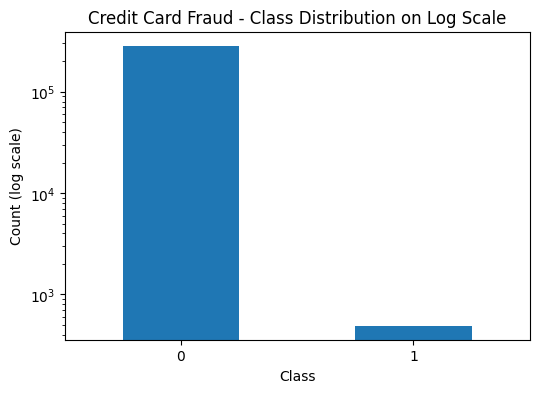

In [32]:
# Log-scale class distribution
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.yscale("log")
plt.title("Credit Card Fraud - Class Distribution on Log Scale")
plt.xlabel("Class")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=0)
plt.show()

The log-scale plot makes the fraud class visible without changing the actual counts. The gap remains very large, so the visual change only helps readability; it does not make the data less imbalanced.


#### 1.3.3 No-skill baseline

Predicting every transaction as non-fraud gives a simple no-skill reference point. It is useless for fraud detection, but it exposes the weakness of accuracy on this dataset.


In [33]:
# No-skill baseline: predict every transaction as non-fraud
from sklearn.metrics import classification_report

baseline_y_true = credit_df[credit_target]
baseline_y_pred = np.zeros(len(baseline_y_true), dtype=int)

baseline_results = pd.DataFrame({
    "model": ["Always predict non-fraud"],
    "accuracy": [accuracy_score(baseline_y_true, baseline_y_pred)],
    "precision": [precision_score(baseline_y_true, baseline_y_pred, zero_division=0)],
    "recall": [recall_score(baseline_y_true, baseline_y_pred, zero_division=0)],
    "f1": [f1_score(baseline_y_true, baseline_y_pred, zero_division=0)]
})

baseline_results

,model,accuracy,precision,recall,f1
0,Always predict non-fraud,0.998273,0.0,0.0,0.0


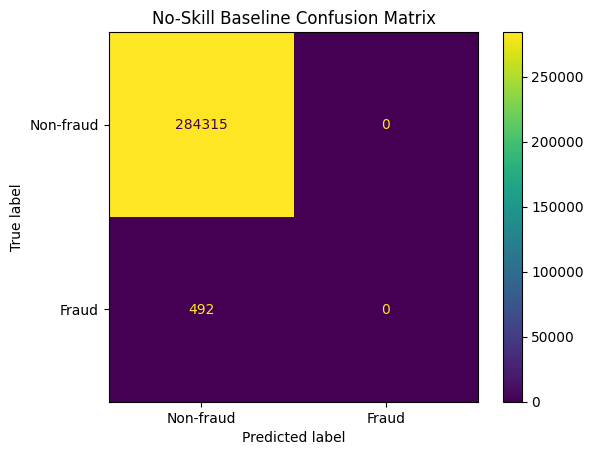

In [34]:
# Confusion matrix for the no-skill baseline
baseline_cm = confusion_matrix(baseline_y_true, baseline_y_pred)

ConfusionMatrixDisplay(baseline_cm, display_labels=["Non-fraud", "Fraud"]).plot()
plt.title("No-Skill Baseline Confusion Matrix")
plt.show()

The no-skill baseline reaches high accuracy because almost every transaction is non-fraud. Its recall is still 0 because it catches no fraud cases. For that reason, accuracy is not the main metric. Recall, precision, F1-score, confusion matrix, and PR-AUC give a better view of fraud detection performance.

#### 1.3.4 Class weights

Class weights penalize mistakes on the smaller class more heavily during training. They do not add new fraud examples, but they can reduce the tendency to learn mostly the non-fraud class.


In [35]:
# Estimate balanced class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=credit_df[credit_target]
)

class_weight_table = pd.DataFrame({
    "class_label": classes,
    "meaning": ["Non-fraud", "Fraud"],
    "balanced_weight": weights
})

class_weight_table

,class_label,meaning,balanced_weight
0,0,Non-fraud,0.500865
1,1,Fraud,289.438008


The fraud class receives a much larger weight because it has far fewer examples. That supports using options such as `class_weight="balanced"` for Logistic Regression and Random Forest. For XGBoost, a similar idea can be handled using a positive-class weight such as `scale_pos_weight`.

#### 1.3.5 Stratified train-test split check

Stratification keeps the fraud ratio similar in the training and test sets. Without it, the test set could have too few fraud cases, making recall and precision unstable.


In [36]:
# Check that a stratified split preserves the class ratio
imbalance_X = credit_df.drop(columns=[credit_target])
imbalance_y = credit_df[credit_target]

X_temp_train, X_temp_test, y_temp_train, y_temp_test = train_test_split(
    imbalance_X,
    imbalance_y,
    test_size=0.2,
    random_state=42,
    stratify=imbalance_y
)

split_balance = pd.DataFrame({
    "full_dataset_%": (imbalance_y.value_counts(normalize=True).sort_index() * 100).round(4),
    "train_set_%": (y_temp_train.value_counts(normalize=True).sort_index() * 100).round(4),
    "test_set_%": (y_temp_test.value_counts(normalize=True).sort_index() * 100).round(4),
    "train_count": y_temp_train.value_counts().sort_index(),
    "test_count": y_temp_test.value_counts().sort_index()
})

split_balance.index = ["Non-fraud", "Fraud"]
split_balance

,full_dataset_%,train_set_%,test_set_%,train_count,test_count
Non-fraud,99.8273,99.8271,99.828,227451,56864
Fraud,0.1727,0.1729,0.172,394,98


The stratified split keeps the fraud percentage almost the same in the full dataset, training set, and test set. That gives the model fraud examples during training and leaves enough fraud cases in the test set to measure performance properly.

#### 1.3.6 Class imbalance findings

The class split is extremely uneven: 284,315 transactions are non-fraud and only 492 are fraud. Fraud makes up about 0.173% of the dataset, which gives an imbalance ratio of roughly 578 non-fraud transactions for every fraud transaction.

The no-skill baseline reaches about 99.83% accuracy by predicting every row as non-fraud, but it catches 0 fraud cases. Its recall, precision, and F1-score for fraud are all 0. That result shows why accuracy cannot be the main success measure here. The stratified split keeps the fraud percentage almost the same in both training and testing, so the later model evaluation is more reliable.

### 1.4 Credit Card Fraud Univariate Analysis

Each variable is checked on its own before relationships between variables are studied. The univariate stage focuses on the behaviour of `Amount`, `Time`, and the anonymized `V` features. The individual distributions help show where skew, extreme values, or unusual spread may affect the later modelling work.


#### 1.4.1 Amount distribution

`Amount` has one of the few clear real-world meanings in the credit card data. The raw distribution is checked first, and a log-transformed version is added so the overall shape can be read more clearly.

In [37]:
# Amount distribution and log-transformed Amount
credit_df["LogAmount"] = np.log1p(credit_df["Amount"])

amount_summary = credit_df[["Amount", "LogAmount"]].describe().T
amount_summary["skew"] = credit_df[["Amount", "LogAmount"]].skew()
amount_summary

,count,mean,std,min,25%,50%,75%,max,skew
Amount,284807.0,88.349619,250.120109,0.0,5.60000,22.000000,77.165000,25691.160000,16.977724
LogAmount,284807.0,3.152188,1.656648,0.0,1.88707,3.135494,4.358822,10.153941,0.162703


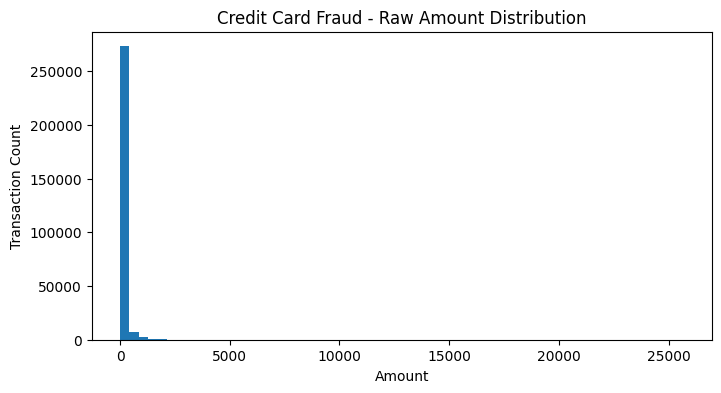

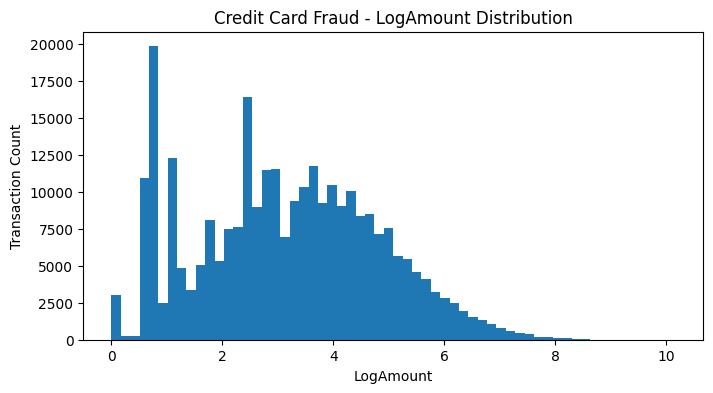

In [38]:
# Raw Amount distribution
plt.figure(figsize=(8, 4))
plt.hist(credit_df["Amount"], bins=60)
plt.title("Credit Card Fraud - Raw Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Transaction Count")
plt.show()

# Log Amount distribution
plt.figure(figsize=(8, 4))
plt.hist(credit_df["LogAmount"], bins=60)
plt.title("Credit Card Fraud - LogAmount Distribution")
plt.xlabel("LogAmount")
plt.ylabel("Transaction Count")
plt.show()

The raw `Amount` values are heavily right-skewed. The median transaction amount is 22.00, while the mean is 88.35 and the maximum reaches 25,691.16. That large gap between the median, mean, and maximum shows that a small number of very large transactions pull the average upward.

`LogAmount` has a much cleaner shape, with skewness dropping from about 16.98 to about 0.16. The original amount still carries useful transaction-size information, but the raw scale would be rough for models that are affected by large feature ranges.

#### 1.4.2 Amount percentiles

Percentiles make the skew in transaction amount easier to read. The mean alone does not show what a typical transaction looks like when a few very large values stretch the distribution.


In [39]:
# Amount percentiles
amount_percentiles = credit_df["Amount"].quantile([
    0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00
]).to_frame("Amount")

amount_percentiles

,Amount
0.00,0.000
0.01,0.120
0.05,0.920
0.25,5.600
0.50,22.000
0.75,77.165
0.95,365.000
0.99,1017.970
1.00,25691.160


#### 1.4.3 Time distribution

`Time` represents the number of seconds since the first transaction in the dataset. Seconds are not very easy to interpret, so an `Hour` column is created for the exploratory analysis.

In [40]:
# Time summary and derived hour feature
credit_df["Hour"] = ((credit_df["Time"] / 3600) % 24).astype(int)

credit_df[["Time", "Hour"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.5,172792.0
Hour,284807.0,14.046470,5.835854,0.0,10.0,15.0,19.0,23.0


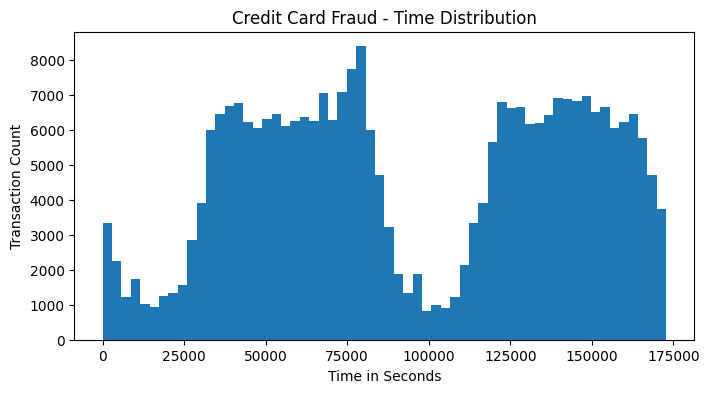

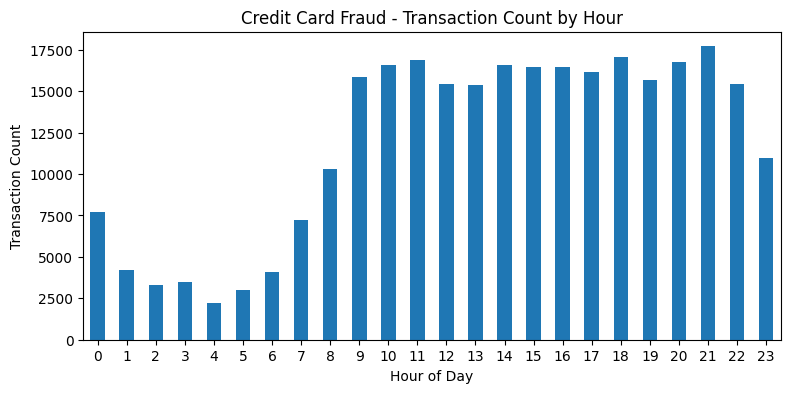

In [41]:
# Time distribution
plt.figure(figsize=(8, 4))
plt.hist(credit_df["Time"], bins=60)
plt.title("Credit Card Fraud - Time Distribution")
plt.xlabel("Time in Seconds")
plt.ylabel("Transaction Count")
plt.show()

# Hour distribution
hour_counts = credit_df["Hour"].value_counts().sort_index()

plt.figure(figsize=(9, 4))
hour_counts.plot(kind="bar")
plt.title("Credit Card Fraud - Transaction Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.xticks(rotation=0)
plt.show()

The time values cover the full collection period from 0 to 172,792 seconds. After converting the values to `Hour`, the transaction counts are not evenly spread across the day. Some hours have much lighter activity, such as hour 4 with 2,209 transactions, while later hours such as hour 21 have much heavier activity with 17,703 transactions.

The hour feature gives a more readable time pattern than raw seconds, although it is still only a rough time signal because the original date and cardholder context are not available.

#### 1.4.4 PCA feature summary

The `V1` to `V28` columns are anonymized PCA-transformed features. Their original meanings are hidden, so the analysis focuses on their statistical behaviour instead of assigning business meanings to them.

In [42]:
# Summary table for anonymized V features
v_features = [col for col in credit_df.columns if col.startswith("V")]

v_summary = pd.DataFrame({
    "mean": credit_df[v_features].mean(),
    "median": credit_df[v_features].median(),
    "std": credit_df[v_features].std(),
    "min": credit_df[v_features].min(),
    "max": credit_df[v_features].max(),
    "skew": credit_df[v_features].skew(),
    "kurtosis": credit_df[v_features].kurtosis()
})

v_summary.sort_values("skew", key=lambda x: x.abs(), ascending=False).head(10)

,mean,median,std,min,max,skew,kurtosis
V28,-1.227390e-16,0.011244,0.330083,-15.430084,33.847808,11.192091,933.397502
V8,1.213481e-16,0.022358,1.194353,-73.216718,20.007208,-8.521944,220.586974
V23,2.578648e-16,-0.011193,0.624460,-44.807735,22.528412,-5.875140,440.088659
V2,3.416908e-16,0.065486,1.651309,-72.715728,22.057729,-4.624866,95.773106
V17,-3.772171e-16,-0.065676,0.849337,-25.162799,9.253526,-3.844914,94.799719
V21,1.654067e-16,-0.029450,0.734524,-34.830382,27.202839,3.592991,207.287040
V1,1.168375e-15,0.018109,1.958696,-56.407510,2.454930,-3.280667,32.486679
V7,-5.556467e-16,0.040103,1.237094,-43.557242,120.589494,2.553907,405.607417
V5,9.604066e-16,-0.054336,1.380247,-113.743307,34.801666,-2.425901,206.904560
V12,-1.247012e-15,0.140033,0.999201,-18.683715,7.848392,-2.278401,20.241870


The strongest skewness appears in `V28`, `V8`, `V23`, `V2`, `V17`, `V21`, `V1`, and `V7`. Features with high kurtosis, especially `V28`, `V23`, and `V7`, point to long tails and rare extreme values.

Most of the `V` feature means stay close to zero, which fits the transformed nature of the variables. The main issue is not missing values or invalid values, but the uneven shapes and extreme tails in some of the transformed features.


#### 1.4.5 Distribution plots for selected V features

Only the most skewed `V` features are plotted first. They stand out most in the univariate summary and show where the extreme tails are strongest.


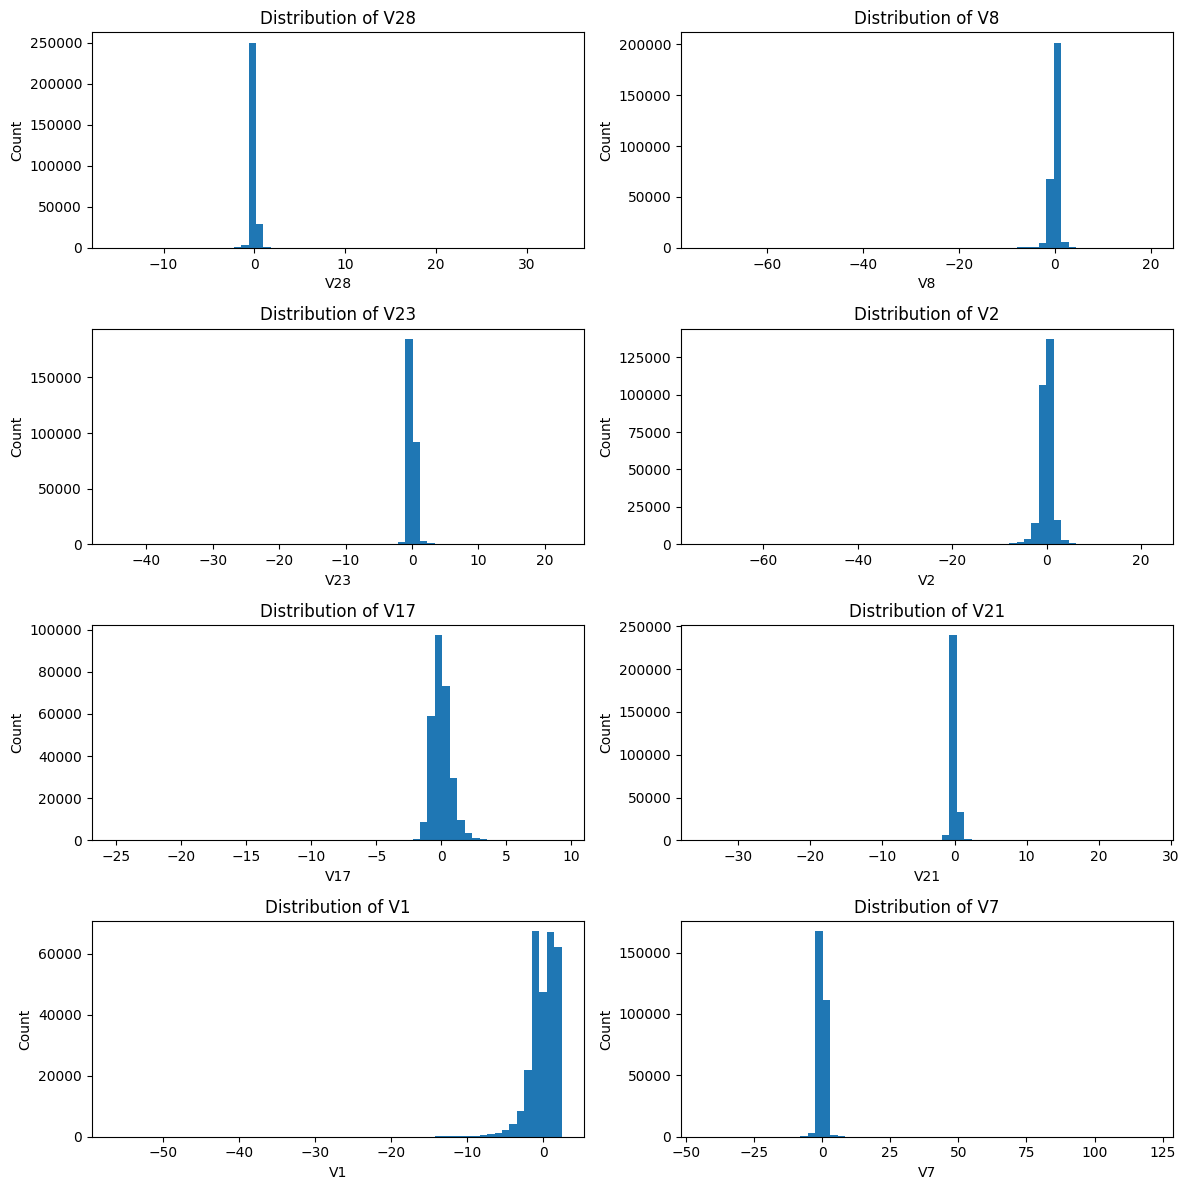

['V28', 'V8', 'V23', 'V2', 'V17', 'V21', 'V1', 'V7']

In [43]:
# Plot distributions for the most skewed V features
most_skewed_v_features = v_summary.reindex(
    v_summary["skew"].abs().sort_values(ascending=False).index
).head(8).index.tolist()

fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, col in zip(axes, most_skewed_v_features):
    ax.hist(credit_df[col], bins=60)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

most_skewed_v_features

The selected histograms show that the most skewed `V` features are not shaped the same way. `V28` has a strong positive tail, while features such as `V8`, `V23`, `V2`, and `V17` have stronger negative tails. Most values still sit near the center, but a small number of extreme values stretch the distributions.

Those tails are not removed automatically. In a fraud problem, rare extreme patterns may be part of the signal rather than simple noise.

#### 1.4.6 Full V-feature histogram grid

The full grid places all transformed features in one view, so the distribution shapes can be compared quickly.


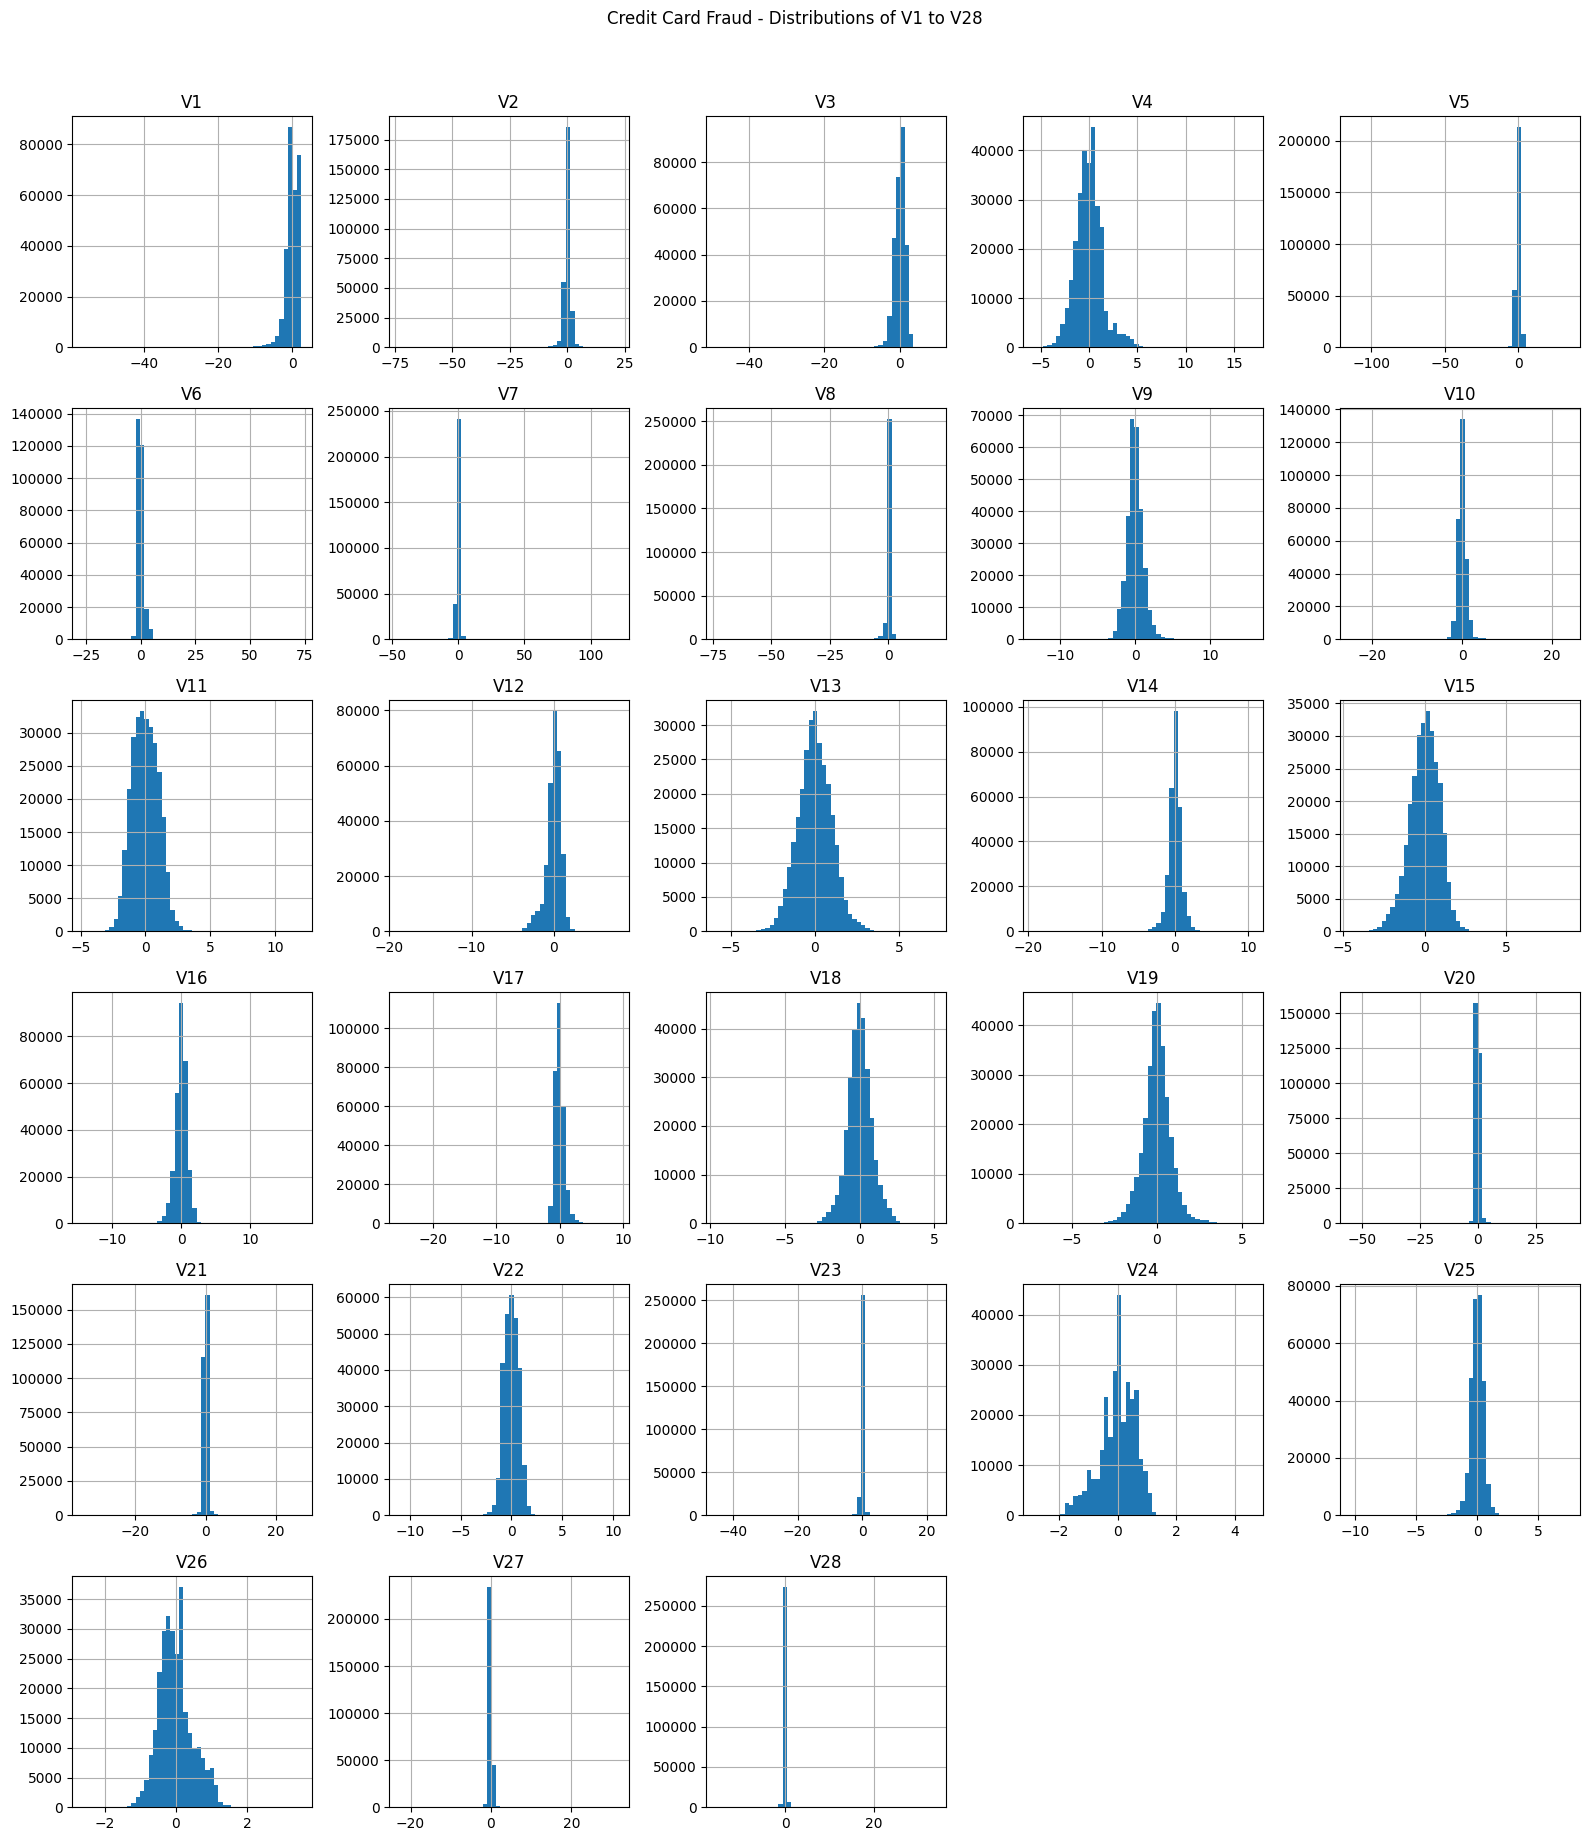

In [44]:
# Histogram grid for all V features
credit_df[v_features].hist(figsize=(16, 18), bins=50)
plt.suptitle("Credit Card Fraud - Distributions of V1 to V28", y=1.02)
plt.tight_layout()
plt.show()

#### 1.4.7 Univariate analysis findings

The strongest univariate pattern is the shape of `Amount`. With a median of 22.00, a mean of 88.35, and a maximum above 25,000, the average is pulled upward by a small number of large transactions. The log version gives a more readable shape and reduces the effect of the long right tail.

After converting `Time` into `Hour`, transaction activity is not evenly spread across the day. Some hours have much lower volume than others, so time-related features may still contain useful information even if they do not separate fraud perfectly.

The anonymized `V` features have different tails and spreads, with `V28`, `V8`, `V23`, `V2`, and `V17` standing out by skewness. The univariate findings point toward three preprocessing needs: scaling, careful treatment of skewed amount values, and evaluation methods that account for the rare fraud class.


### 1.5 Credit Card Fraud Bivariate Analysis

Bivariate analysis checks how each feature behaves in relation to the target class. For the credit card data, the main comparison is between non-fraud and fraud transactions. The class imbalance has to be handled carefully during plotting, because the fraud class can disappear visually when all non-fraud rows are plotted beside it.

The focus here is on `Amount`, `LogAmount`, `Hour`, and the anonymized `V` features. Since the `V` features do not have real-world labels, the analysis looks for statistical separation between the two classes rather than trying to assign a business meaning to each feature.

#### 1.5.1 Balanced plotting sample

The full dataset has far more non-fraud transactions than fraud transactions. For class comparison plots, all 492 fraud cases are kept and 5,000 non-fraud cases are sampled. That keeps the plots readable without changing the original data used for modelling.

In [45]:
# Create a smaller plotting set for class comparison plots
if "LogAmount" not in credit_df.columns:
    credit_df["LogAmount"] = np.log1p(credit_df["Amount"])

if "Hour" not in credit_df.columns:
    credit_df["Hour"] = ((credit_df["Time"] / 3600) % 24).astype(int)

v_features = [col for col in credit_df.columns if col.startswith("V")]

credit_fraud_df = credit_df[credit_df[credit_target] == 1]
credit_nonfraud_sample = credit_df[credit_df[credit_target] == 0].sample(
    n=min(5000, (credit_df[credit_target] == 0).sum()),
    random_state=42
)

credit_plot_df = pd.concat([credit_nonfraud_sample, credit_fraud_df], axis=0)

print("Fraud rows in plotting data:", (credit_plot_df[credit_target] == 1).sum())
print("Non-fraud rows in plotting data:", (credit_plot_df[credit_target] == 0).sum())


Fraud rows in plotting data: 492
Non-fraud rows in plotting data: 5000


#### 1.5.2 Amount compared with Class

`Amount` is compared against the class label because transaction size may still carry some fraud-related information. Both the raw amount and the log-transformed amount are checked because the raw feature is heavily skewed.

In [46]:
# Amount and LogAmount summary by class
amount_by_class = credit_df.groupby(credit_target)[["Amount", "LogAmount"]].agg([
    "count", "mean", "median", "std", "min", "max"
])

amount_by_class


Amount                                               LogAmount  \
        count        mean median         std  min       max     count   
Class                                                                   
0      284315   88.291022  22.00  250.105092  0.0  25691.16    284315   
1         492  122.211321   9.25  256.683288  0.0   2125.87       492   

                                                     
           mean    median       std  min        max  
Class                                                
0      3.152762  3.135494  1.655468  0.0  10.153941  
1      2.820596  2.327270  2.214342  0.0   7.662407

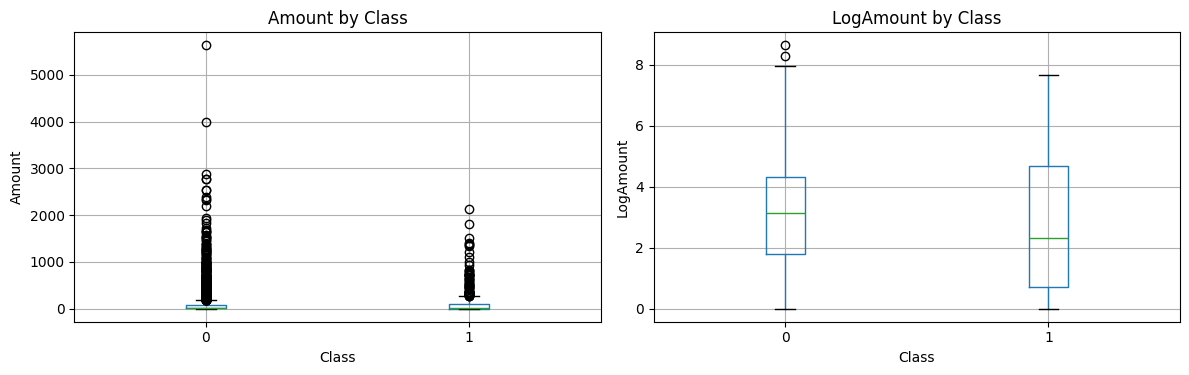

In [47]:
# Boxplots of Amount and LogAmount by class using the plotting sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

credit_plot_df.boxplot(column="Amount", by=credit_target, ax=axes[0])
axes[0].set_title("Amount by Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Amount")

credit_plot_df.boxplot(column="LogAmount", by=credit_target, ax=axes[1])
axes[1].set_title("LogAmount by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("LogAmount")

plt.suptitle("")
plt.tight_layout()
plt.show()


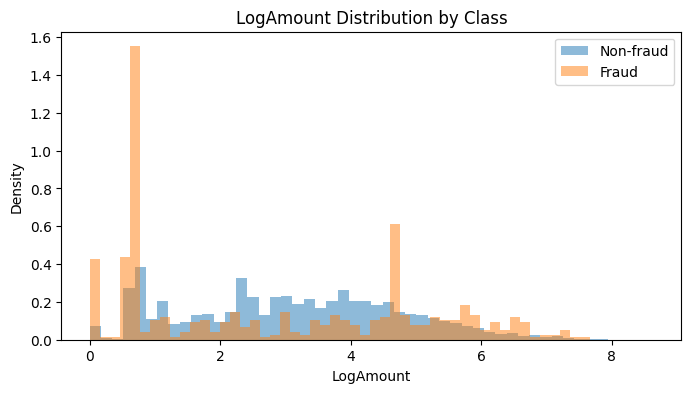

In [48]:
# Density-style histograms for LogAmount by class
plt.figure(figsize=(8, 4))

for class_value, label in [(0, "Non-fraud"), (1, "Fraud")]:
    values = credit_plot_df.loc[credit_plot_df[credit_target] == class_value, "LogAmount"]
    plt.hist(values, bins=50, density=True, alpha=0.5, label=label)

plt.title("LogAmount Distribution by Class")
plt.xlabel("LogAmount")
plt.ylabel("Density")
plt.legend()
plt.show()


The class summary does not support a simple “larger amount means fraud” rule. Fraud transactions have a higher mean amount than non-fraud transactions, 122.21 compared with 88.29, but the fraud median is lower, 9.25 compared with 22.00 for non-fraud.

That pattern suggests that many fraud transactions are small, while a smaller number of larger fraud transactions pull the mean upward. The plots also show heavy overlap between the two classes, so `Amount` is better treated as supporting context.

#### 1.5.3 Hour compared with Class

The derived `Hour` feature is used to check whether fraud appears more often during certain parts of the day. Fraud rate gives a fairer comparison than raw fraud count because some hours naturally contain more total transactions than others.

In [49]:
# Fraud count and fraud rate by hour
hour_class_summary = credit_df.groupby("Hour")[credit_target].agg(
    transaction_count="count",
    fraud_count="sum",
    fraud_rate="mean"
).reset_index()

hour_class_summary["fraud_rate_percent"] = hour_class_summary["fraud_rate"] * 100
hour_class_summary


,Hour,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
0,0,7695,6,0.000780,0.077973
1,1,4220,10,0.002370,0.236967
2,2,3328,57,0.017127,1.712740
3,3,3492,17,0.004868,0.486827
4,4,2209,23,0.010412,1.041195
5,5,2990,11,0.003679,0.367893
6,6,4101,9,0.002195,0.219459
7,7,7243,23,0.003175,0.317548
8,8,10276,9,0.000876,0.087583
9,9,15838,16,0.001010,0.101023


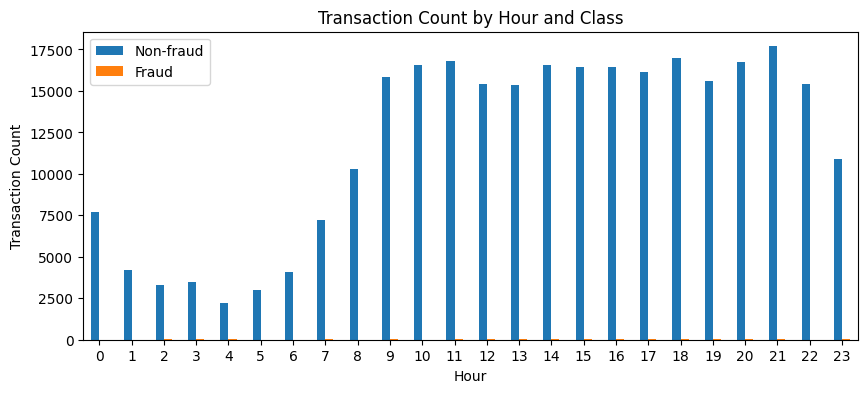

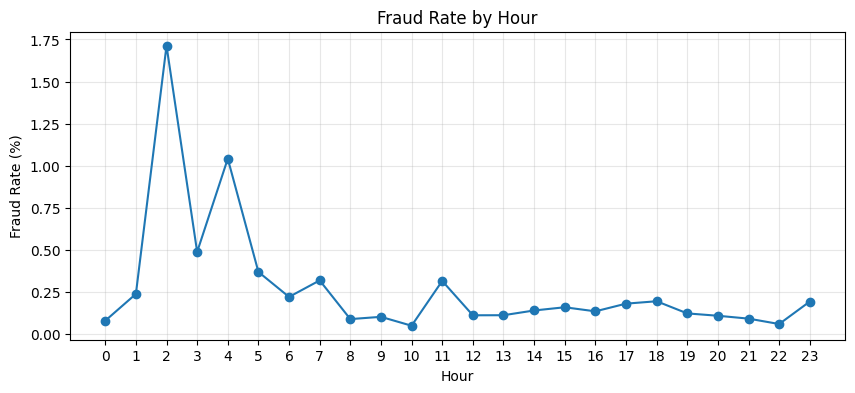

In [50]:
# Transaction count by hour split by class
hour_class_counts = pd.crosstab(credit_df["Hour"], credit_df[credit_target])
hour_class_counts.columns = ["Non-fraud", "Fraud"]

hour_class_counts.plot(kind="bar", figsize=(10, 4))
plt.title("Transaction Count by Hour and Class")
plt.xlabel("Hour")
plt.ylabel("Transaction Count")
plt.xticks(rotation=0)
plt.show()

# Fraud rate by hour
plt.figure(figsize=(10, 4))
plt.plot(hour_class_summary["Hour"], hour_class_summary["fraud_rate_percent"], marker="o")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()


The fraud rate is not flat across the day. Hour 2 has the highest fraud rate at about 1.71%, followed by hour 4 at about 1.04%. Hours 3 and 5 are also higher than many of the daytime hours. Raw transaction volume is much larger later in the day, but the proportion of fraud is higher in some early-hour periods.

Hour still cannot separate fraud by itself because fraud rates remain low across all hours. Even so, the early-hour spike gives the model a useful time-based signal to combine with the other features.

#### 1.5.4 V features compared with Class

The anonymized `V` features are compared with the target by measuring how different their fraud and non-fraud distributions are. Since the original feature meanings are hidden, the analysis focuses on separation between classes.

In [51]:
# Compare V-feature means and medians by class
rows = []

for col in v_features:
    nonfraud_values = credit_df.loc[credit_df[credit_target] == 0, col]
    fraud_values = credit_df.loc[credit_df[credit_target] == 1, col]

    nonfraud_mean = nonfraud_values.mean()
    fraud_mean = fraud_values.mean()
    nonfraud_median = nonfraud_values.median()
    fraud_median = fraud_values.median()

    nonfraud_std = nonfraud_values.std()
    fraud_std = fraud_values.std()
    pooled_std = np.sqrt((nonfraud_std ** 2 + fraud_std ** 2) / 2)

    rows.append({
        "feature": col,
        "nonfraud_mean": nonfraud_mean,
        "fraud_mean": fraud_mean,
        "abs_mean_difference": abs(fraud_mean - nonfraud_mean),
        "nonfraud_median": nonfraud_median,
        "fraud_median": fraud_median,
        "abs_median_difference": abs(fraud_median - nonfraud_median),
        "standardized_mean_difference": (fraud_mean - nonfraud_mean) / pooled_std if pooled_std != 0 else np.nan
    })

v_class_difference = pd.DataFrame(rows)
v_class_difference = v_class_difference.sort_values("abs_mean_difference", ascending=False)

v_class_difference.head(12)


,feature,nonfraud_mean,fraud_mean,abs_mean_difference,nonfraud_median,fraud_median,abs_median_difference,standardized_mean_difference
2,V3,0.012171,-7.033281,7.045452,0.182158,-5.075257,5.257415,-1.372580
13,V14,0.012064,-6.971723,6.983787,0.051947,-6.729720,6.781667,-2.259076
16,V17,0.011535,-6.665836,6.677371,-0.064833,-5.302949,5.238115,-1.346956
11,V12,0.010832,-6.259393,6.270225,0.141679,-5.502530,5.644208,-1.866983
9,V10,0.009824,-5.676883,5.686707,-0.091872,-4.578825,4.486953,-1.606058
6,V7,0.009637,-5.568731,5.578368,0.041138,-3.034402,3.075540,-1.080309
0,V1,0.008258,-4.771948,4.780206,0.020023,-2.342497,2.362521,-0.958512
3,V4,-0.007860,4.542029,4.549889,-0.022405,4.177147,4.199552,2.013335
15,V16,0.007164,-4.139946,4.147110,0.067377,-3.549795,3.617172,-1.482429
10,V11,-0.006576,3.800173,3.806749,-0.034923,3.586218,3.621142,1.882183


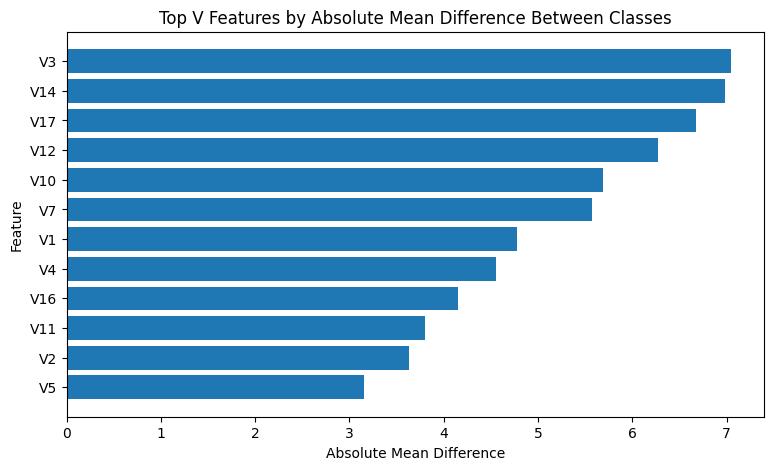

['V3', 'V14', 'V17', 'V12', 'V10', 'V7', 'V1', 'V4']

In [52]:
# Plot the V features with the largest mean differences between classes
top_bivariate_v_features = v_class_difference.head(8)["feature"].tolist()

plt.figure(figsize=(9, 5))
plt.barh(
    v_class_difference.head(12)["feature"][::-1],
    v_class_difference.head(12)["abs_mean_difference"][::-1]
)
plt.title("Top V Features by Absolute Mean Difference Between Classes")
plt.xlabel("Absolute Mean Difference")
plt.ylabel("Feature")
plt.show()

top_bivariate_v_features


The largest mean differences appear in `V3`, `V14`, `V17`, `V12`, `V10`, `V7`, `V1`, and `V4`. Fraud transactions have much lower average values than non-fraud transactions for several of those features, especially `V3`, `V14`, `V17`, and `V12`. `V4` moves in the opposite direction, with fraud values generally higher than non-fraud values.

The ranking helps choose variables for closer plotting, but it is not final feature selection. A weaker individual feature may still help once it is combined with the others.


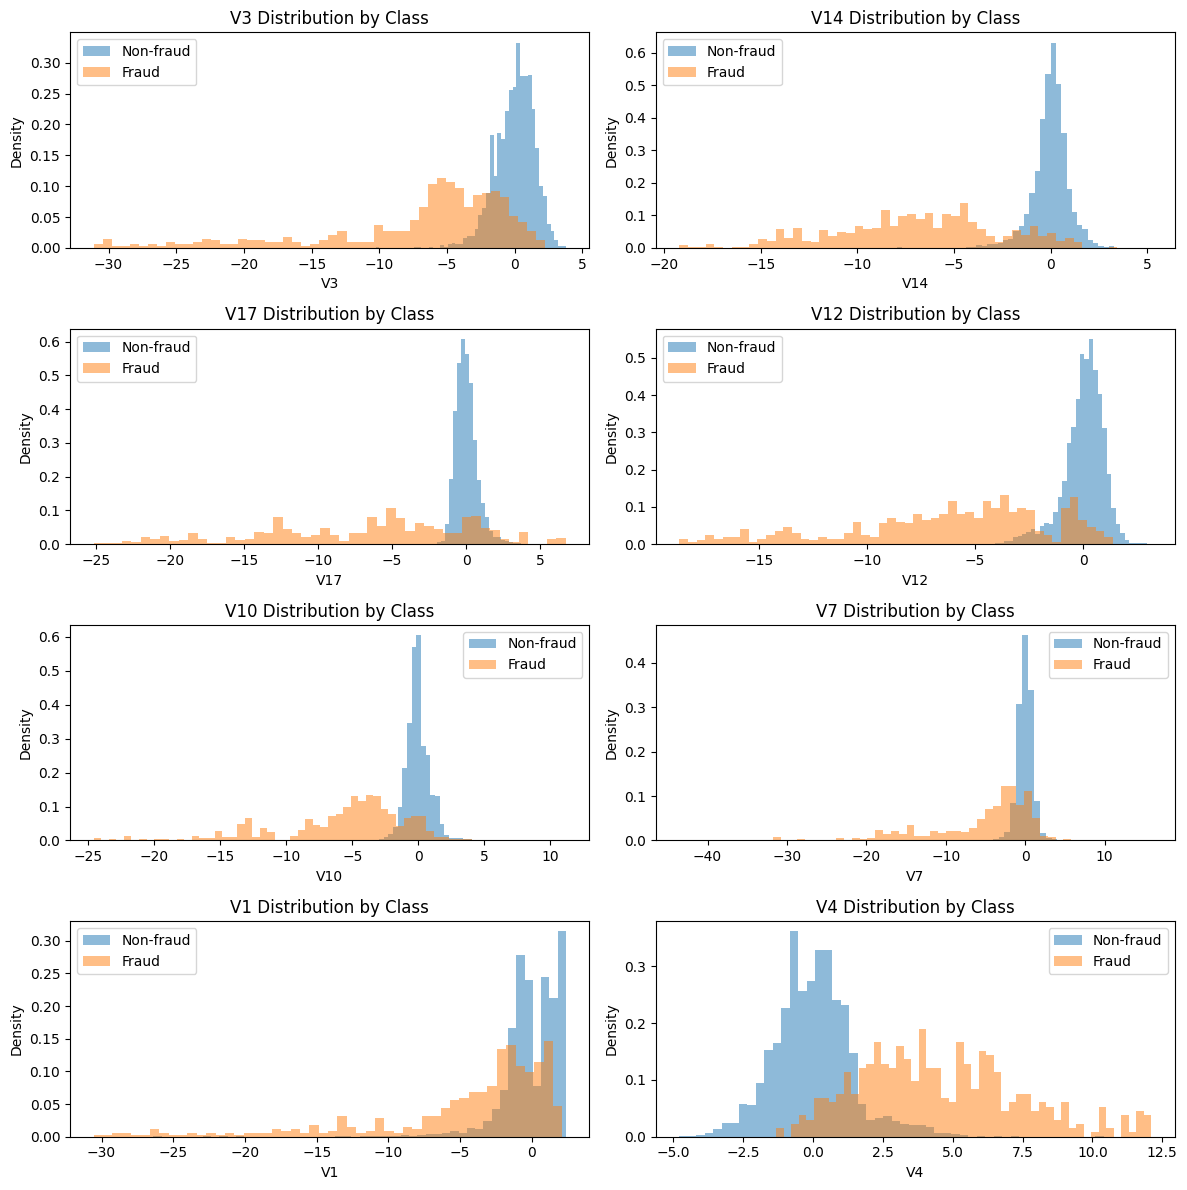

In [53]:
# Distribution comparison for the top V features
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, col in zip(axes, top_bivariate_v_features):
    nonfraud_values = credit_plot_df.loc[credit_plot_df[credit_target] == 0, col]
    fraud_values = credit_plot_df.loc[credit_plot_df[credit_target] == 1, col]

    ax.hist(nonfraud_values, bins=50, density=True, alpha=0.5, label="Non-fraud")
    ax.hist(fraud_values, bins=50, density=True, alpha=0.5, label="Fraud")
    ax.set_title(f"{col} Distribution by Class")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()


<Figure size 600x400 with 0 Axes>

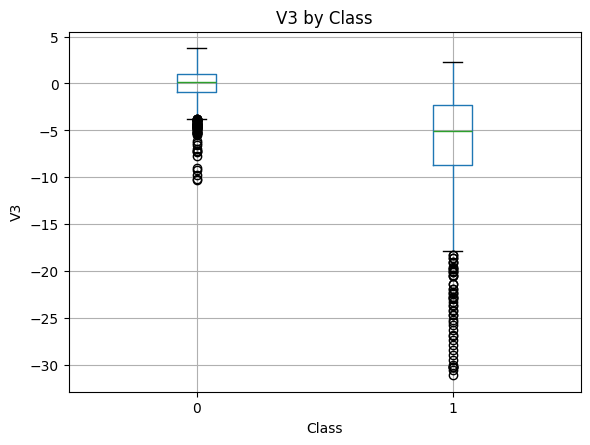

<Figure size 600x400 with 0 Axes>

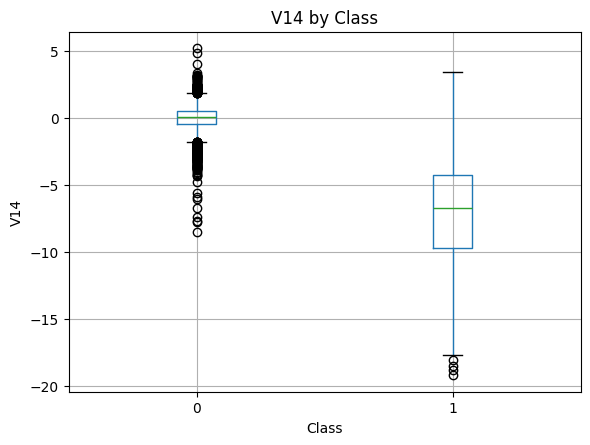

<Figure size 600x400 with 0 Axes>

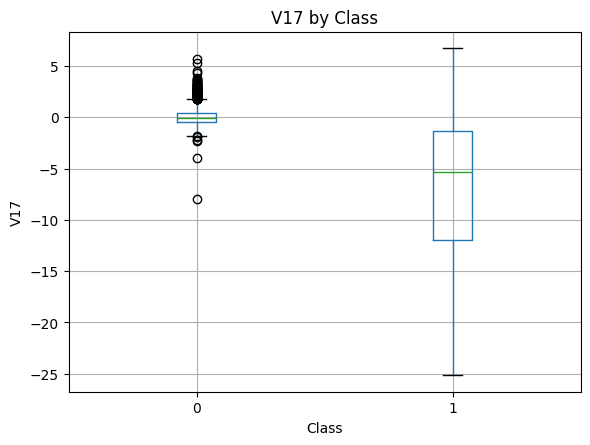

<Figure size 600x400 with 0 Axes>

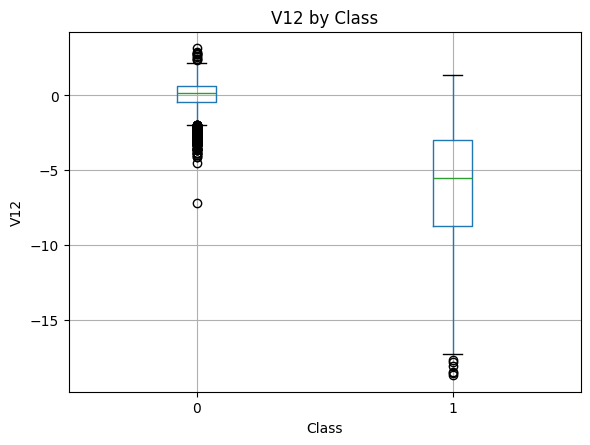

<Figure size 600x400 with 0 Axes>

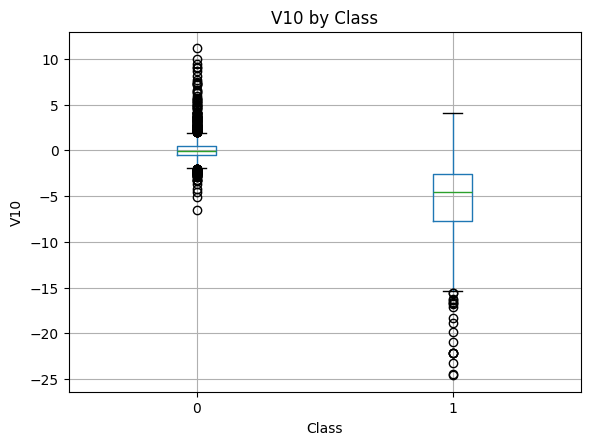

<Figure size 600x400 with 0 Axes>

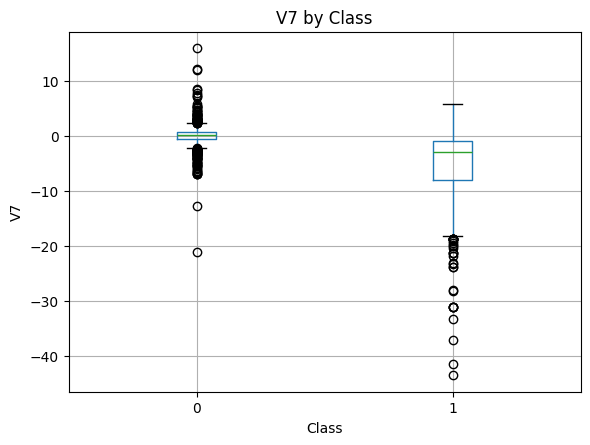

In [54]:
# Boxplots for top V features by class
for col in top_bivariate_v_features[:6]:
    plt.figure(figsize=(6, 4))
    credit_plot_df.boxplot(column=col, by=credit_target)
    plt.title(f"{col} by Class")
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel(col)
    plt.show()


The distribution and boxplot comparisons show visible shifts between fraud and non-fraud for the selected `V` features. Fraud cases tend to sit in lower ranges for `V3`, `V14`, `V17`, `V12`, `V10`, and `V7`, while `V4` moves in the opposite direction.

The classes still overlap, so none of those variables gives a perfect split on its own. The overlap matters for modelling as a one-feature rule would be too weak, but the selected `V` features still carry useful fraud-related signal.


#### 1.5.5 Correlation with the target


In [55]:
# Correlation of numeric features with the target
credit_target_corr = credit_df.corr(numeric_only=True)[credit_target].drop(credit_target)
credit_target_corr_abs = credit_target_corr.abs().sort_values(ascending=False)

credit_corr_summary = pd.DataFrame({
    "correlation_with_class": credit_target_corr,
    "absolute_correlation": credit_target_corr.abs()
}).sort_values("absolute_correlation", ascending=False)

credit_corr_summary.head(15)


,correlation_with_class,absolute_correlation
V17,-0.326481,0.326481
V14,-0.302544,0.302544
V12,-0.260593,0.260593
V10,-0.216883,0.216883
V16,-0.196539,0.196539
V3,-0.192961,0.192961
V7,-0.187257,0.187257
V11,0.154876,0.154876
V4,0.133447,0.133447
V18,-0.111485,0.111485


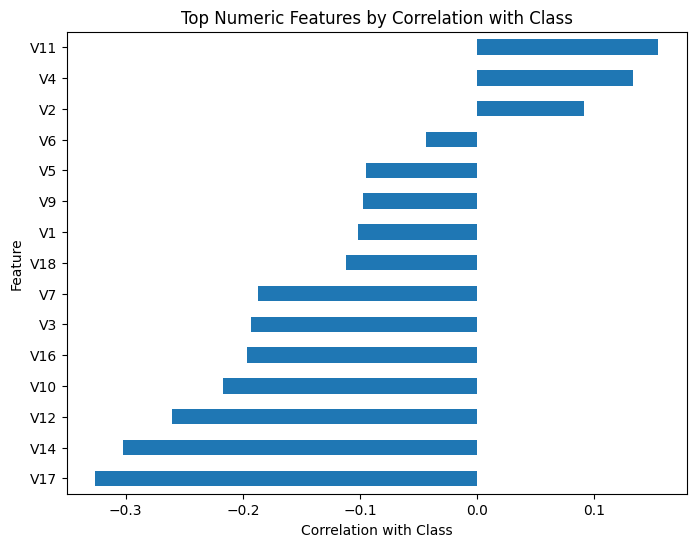

In [56]:
# Plot top absolute correlations with Class
credit_corr_summary.head(15)["correlation_with_class"].sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)
plt.title("Top Numeric Features by Correlation with Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")
plt.show()


#### 1.5.6 Bivariate analysis findings

The bivariate results show that `Amount` and `Hour` provide some context, but they are not strong enough to separate fraud alone. `Amount` has a higher mean for fraud but a lower median, so transaction size does not follow a simple pattern. `Hour` shows a clearer early-hour fraud-rate spike, especially around hour 2, but fraud remains rare in every hour.

The stronger individual signals come from the anonymized `V` features. `V17`, `V14`, `V12`, `V10`, `V16`, `V3`, and `V7` have the strongest absolute correlations with `Class`, with `V17` around -0.326 and `V14` around -0.303. The bivariate stage therefore points toward a modelling problem where several transformed features need to work together, rather than one obvious transaction feature solving the task.

### 1.6 Multivariate Analysis

Multivariate analysis checks whether several features together give a clearer fraud pattern than one feature on its own. A single feature may overlap heavily between fraud and non-fraud, but a combination of features can still create useful separation.

For the credit card data, the main focus is on selected `V` features, `LogAmount`, and `Hour`. Since the `V` variables are anonymized, the analysis stays statistical rather than trying to attach real-world meanings to the feature names.

#### 1.6.1 Feature set used for multivariate checks

The selected features come from the strongest bivariate differences and strongest target correlations. That keeps the analysis focused instead of plotting every possible feature pair.

In [57]:
# Prepare selected features for multivariate analysis
if "LogAmount" not in credit_df.columns:
    credit_df["LogAmount"] = np.log1p(credit_df["Amount"])

if "Hour" not in credit_df.columns:
    credit_df["Hour"] = ((credit_df["Time"] / 3600) % 24).astype(int)

v_features = [col for col in credit_df.columns if col.startswith("V")]

# Recalculate V-feature class differences if the earlier table is not available
if "v_class_difference" not in globals():
    rows = []
    for col in v_features:
        nonfraud_values = credit_df.loc[credit_df[credit_target] == 0, col]
        fraud_values = credit_df.loc[credit_df[credit_target] == 1, col]
        nonfraud_mean = nonfraud_values.mean()
        fraud_mean = fraud_values.mean()
        nonfraud_std = nonfraud_values.std()
        fraud_std = fraud_values.std()
        pooled_std = np.sqrt((nonfraud_std ** 2 + fraud_std ** 2) / 2)
        rows.append({
            "feature": col,
            "nonfraud_mean": nonfraud_mean,
            "fraud_mean": fraud_mean,
            "abs_mean_difference": abs(fraud_mean - nonfraud_mean),
            "standardized_mean_difference": (fraud_mean - nonfraud_mean) / pooled_std if pooled_std != 0 else np.nan
        })
    v_class_difference = pd.DataFrame(rows).sort_values("abs_mean_difference", ascending=False)

# Recalculate target correlations if needed
if "credit_corr_summary" not in globals():
    credit_target_corr = credit_df.corr(numeric_only=True)[credit_target].drop(credit_target)
    credit_corr_summary = pd.DataFrame({
        "correlation_with_class": credit_target_corr,
        "absolute_correlation": credit_target_corr.abs()
    }).sort_values("absolute_correlation", ascending=False)

selected_by_difference = v_class_difference.head(6)["feature"].tolist()
selected_by_correlation = credit_corr_summary.head(6).index.tolist()

multivariate_features = []
for col in selected_by_difference + selected_by_correlation + ["LogAmount", "Hour"]:
    if col != credit_target and col in credit_df.columns and col not in multivariate_features:
        multivariate_features.append(col)

multivariate_features


['V3', 'V14', 'V17', 'V12', 'V10', 'V7', 'V16', 'LogAmount', 'Hour']

#### 1.6.2 Correlation pattern among selected features


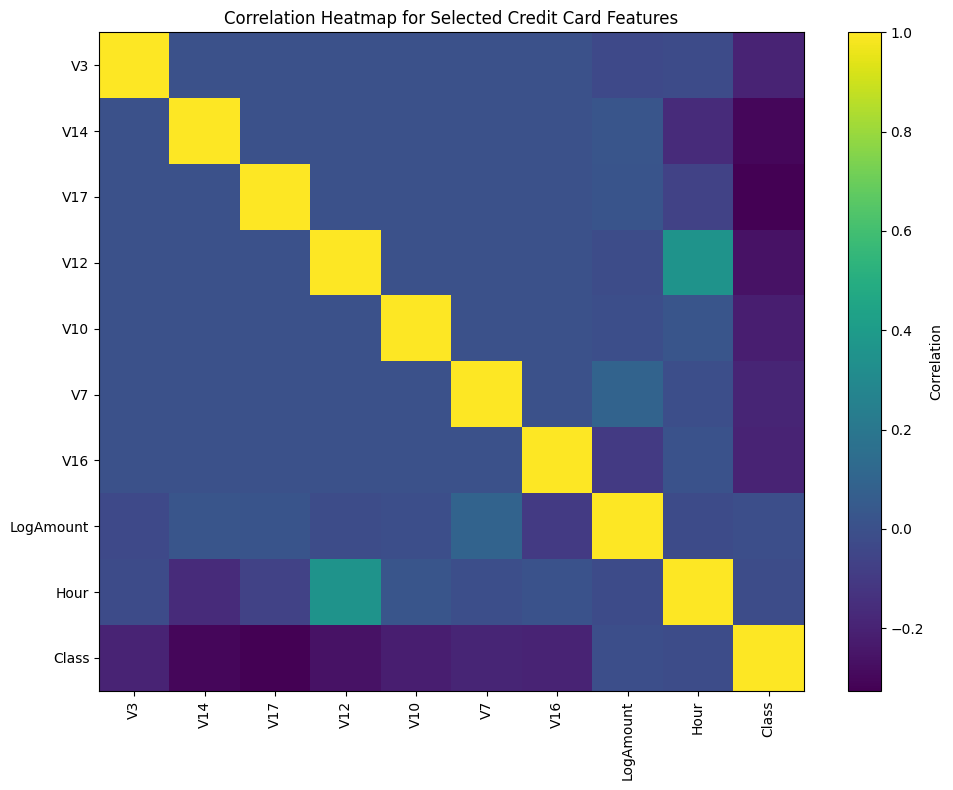

,V3,V14,V17,V12,V10,V7,V16,LogAmount,Hour,Class
V3,1.000000e+00,4.739859e-16,7.614712e-16,6.310231e-16,1.156587e-15,4.895305e-16,8.299445e-16,-0.033913,-0.021569,-0.192961
V14,4.739859e-16,1.000000e+00,1.162529e-15,6.179953e-18,2.450689e-16,2.534982e-16,-1.439858e-15,0.024120,-0.162918,-0.302544
V17,7.614712e-16,1.162529e-15,1.000000e+00,5.616813e-16,1.531868e-15,2.422937e-16,2.468303e-15,0.017123,-0.064803,-0.326481
V12,6.310231e-16,6.179953e-18,5.616813e-16,1.000000e+00,1.772270e-15,7.973266e-19,5.335134e-16,-0.018930,0.352459,-0.260593
V10,1.156587e-15,2.450689e-16,1.531868e-15,1.772270e-15,1.000000e+00,-1.074424e-16,3.545450e-16,-0.009621,0.024177,-0.216883
V7,4.895305e-16,2.534982e-16,2.422937e-16,7.973266e-19,-1.074424e-16,1.000000e+00,5.869302e-17,0.095758,-0.009729,-0.187257
V16,8.299445e-16,-1.439858e-15,2.468303e-15,5.335134e-16,3.545450e-16,5.869302e-17,1.000000e+00,-0.099295,0.005517,-0.196539
LogAmount,-3.391303e-02,2.412015e-02,1.712343e-02,-1.892987e-02,-9.620577e-03,9.575759e-02,-9.929519e-02,1.000000,-0.024402,-0.008326
Hour,-2.156874e-02,-1.629179e-01,-6.480333e-02,3.524592e-01,2.417660e-02,-9.729167e-03,5.517040e-03,-0.024402,1.000000,-0.017109
Class,-1.929608e-01,-3.025437e-01,-3.264811e-01,-2.605929e-01,-2.168829e-01,-1.872566e-01,-1.965389e-01,-0.008326,-0.017109,1.000000


In [58]:
# Correlation heatmap for selected features plus target
corr_features = multivariate_features + [credit_target]
selected_corr = credit_df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(selected_corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(selected_corr.columns)), selected_corr.columns, rotation=90)
plt.yticks(range(len(selected_corr.index)), selected_corr.index)
plt.title("Correlation Heatmap for Selected Credit Card Features")
plt.tight_layout()
plt.show()

selected_corr


#### 1.6.3 Correlation heatmap reading

The heatmap shows that the selected `V` features barely correlate with each other which fits the PCA-transformed structure of the dataset. The stronger relationships are with the target instead of with each other. `V17` has the strongest selected correlation with `Class` at about -0.326, followed by `V14` at about -0.303 and `V12` at about -0.261.

`LogAmount` and `Hour` barely correlate with `Class`, with values close to zero. They may still add context, but the main class signal in the selected set is coming from the transformed `V` variables.

#### 1.6.4 Pairwise feature interaction plots

The scatter plots use all fraud cases and a sample of non-fraud cases to make the fraud points easier to inspect without changing the training data.

In [59]:
# Balanced plotting set for interaction plots
if "credit_plot_df" not in globals():
    credit_fraud_df = credit_df[credit_df[credit_target] == 1]
    credit_nonfraud_sample = credit_df[credit_df[credit_target] == 0].sample(
        n=min(5000, (credit_df[credit_target] == 0).sum()),
        random_state=42
    )
    credit_plot_df = pd.concat([credit_nonfraud_sample, credit_fraud_df], axis=0)

# Create feature pairs from the selected V features
pair_features = [col for col in multivariate_features if col.startswith("V")]
feature_pairs = []

for i in range(0, min(len(pair_features) - 1, 6), 2):
    feature_pairs.append((pair_features[i], pair_features[i + 1]))

feature_pairs


[('V3', 'V14'), ('V17', 'V12'), ('V10', 'V7')]

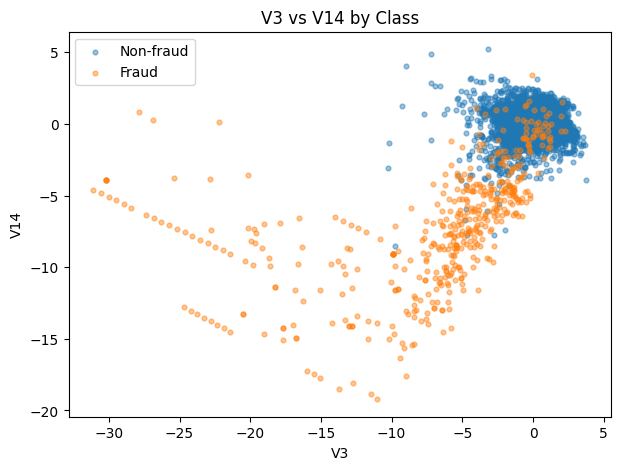

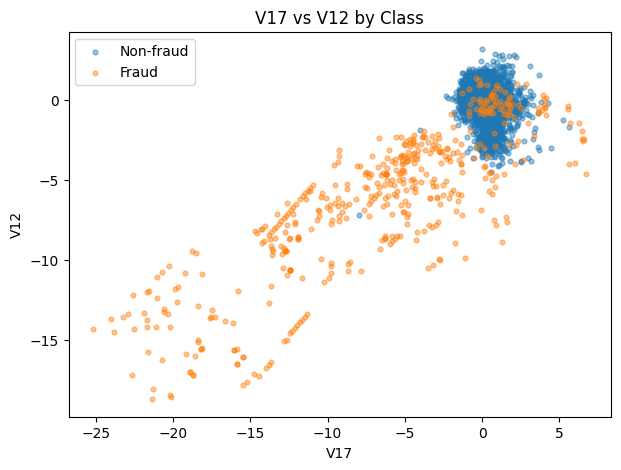

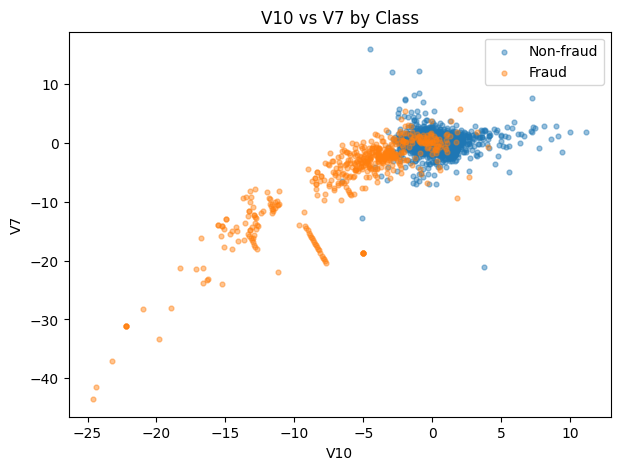

In [60]:
# Scatter plots for selected feature pairs
for x_col, y_col in feature_pairs:
    plt.figure(figsize=(7, 5))

    for class_value, label in [(0, "Non-fraud"), (1, "Fraud")]:
        subset = credit_plot_df[credit_plot_df[credit_target] == class_value]
        plt.scatter(
            subset[x_col],
            subset[y_col],
            s=12,
            alpha=0.45,
            label=label
        )

    plt.title(f"{x_col} vs {y_col} by Class")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.show()


#### 1.6.5 Pairwise plot reading

The scatter plots show that fraud points are not randomly spread in exactly the same way as the non-fraud sample. Some fraud points group away from the densest non-fraud areas, especially in pairs such as `V3`/`V14` and `V17`/`V12`. The separation is still not clean, since the two classes overlap in several regions.

That kind of pattern fits the fraud problem well. A model will probably need to combine several features and thresholds rather than use one simple line or one individual variable.

#### 1.6.6 Fraud rate by amount range and hour

Raw counts can hide the actual pattern because some amount ranges and hours have more transactions overall. Fraud rate gives a fairer comparison because it uses the proportion of fraud inside each group.

In [61]:
# Fraud rate by amount range and hour
credit_df["AmountBin"] = pd.qcut(credit_df["Amount"], q=10, duplicates="drop")

amount_hour_fraud = credit_df.groupby(["AmountBin", "Hour"])[credit_target].agg(
    transaction_count="count",
    fraud_count="sum",
    fraud_rate="mean"
).reset_index()

amount_hour_fraud["fraud_rate_percent"] = amount_hour_fraud["fraud_rate"] * 100
amount_hour_fraud.head(10)


,AmountBin,Hour,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
0,"(-0.001, 1.0]",0,1301,1,0.000769,0.076864
1,"(-0.001, 1.0]",1,272,2,0.007353,0.735294
2,"(-0.001, 1.0]",2,469,29,0.061834,6.183369
3,"(-0.001, 1.0]",3,192,13,0.067708,6.770833
4,"(-0.001, 1.0]",4,145,9,0.062069,6.206897
5,"(-0.001, 1.0]",5,182,9,0.049451,4.945055
6,"(-0.001, 1.0]",6,569,4,0.007030,0.702988
7,"(-0.001, 1.0]",7,1430,0,0.000000,0.000000
8,"(-0.001, 1.0]",8,910,3,0.003297,0.329670
9,"(-0.001, 1.0]",9,1343,3,0.002234,0.223380


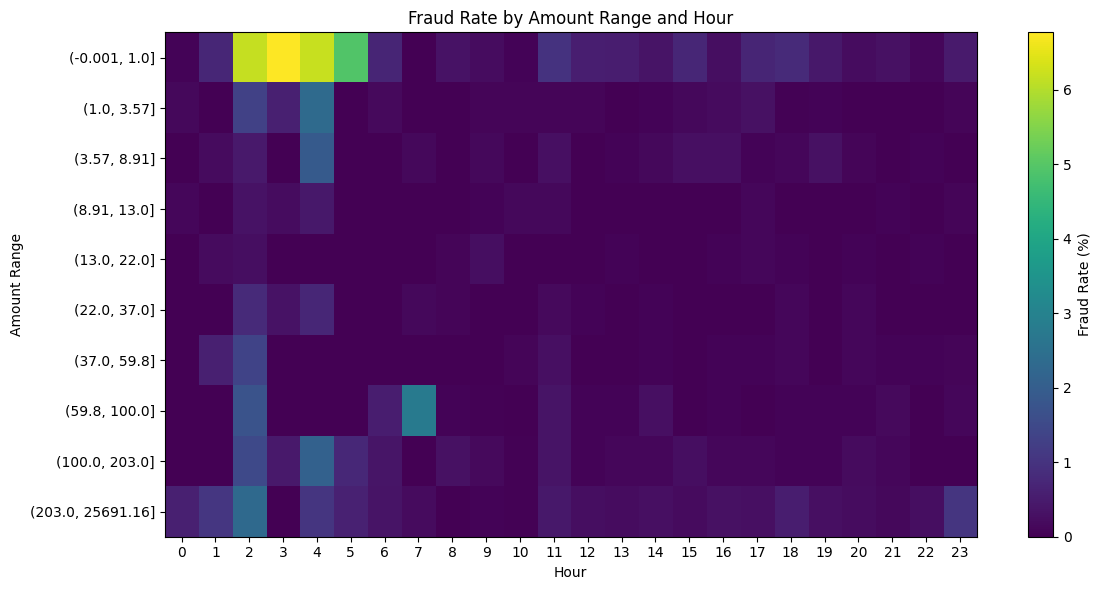

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
AmountBin,,,,,,,,,,,,,,,,,,,,,
"(-0.001, 1.0]",0.076864,0.735294,6.183369,6.770833,6.206897,4.945055,0.702988,0.000000,0.329670,0.223380,...,0.352941,0.725594,0.260417,0.692259,0.817439,0.433974,0.227531,0.291060,0.128315,0.494438
"(1.0, 3.57]",0.133869,0.000000,1.298701,0.591716,2.343750,0.000000,0.176678,0.000000,0.000000,0.087489,...,0.072993,0.150150,0.205339,0.306748,0.051867,0.058858,0.000000,0.000000,0.000000,0.083195
"(3.57, 8.91]",0.000000,0.191205,0.451467,0.000000,1.923077,0.000000,0.000000,0.157480,0.000000,0.144404,...,0.133958,0.264725,0.264901,0.065232,0.105988,0.299043,0.104548,0.000000,0.058582,0.000000
"(8.91, 13.0]",0.124378,0.000000,0.324675,0.230415,0.429185,0.000000,0.000000,0.000000,0.000000,0.076746,...,0.000000,0.000000,0.000000,0.119332,0.000000,0.000000,0.000000,0.059382,0.000000,0.083682
"(13.0, 22.0]",0.000000,0.207469,0.263852,0.000000,0.000000,0.000000,0.000000,0.000000,0.094340,0.247372,...,0.000000,0.000000,0.062344,0.128617,0.056561,0.000000,0.058309,0.000000,0.069109,0.000000
"(22.0, 37.0]",0.000000,0.000000,0.816327,0.317460,0.729927,0.000000,0.000000,0.150602,0.092764,0.000000,...,0.058928,0.000000,0.000000,0.000000,0.126103,0.000000,0.121507,0.000000,0.000000,0.000000
"(37.0, 59.8]",0.000000,0.589391,1.369863,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.060386,0.000000,0.060060,0.063331,0.125313,0.000000,0.124922,0.059172,0.070077,0.101937
"(59.8, 100.0]",0.000000,0.000000,1.724138,0.000000,0.000000,0.000000,0.533333,2.770083,0.077640,0.051600,...,0.269978,0.000000,0.059418,0.000000,0.058824,0.068166,0.065020,0.181708,0.000000,0.115875
"(100.0, 203.0]",0.000000,0.000000,1.498127,0.473934,2.112676,0.763359,0.371747,0.000000,0.295276,0.160858,...,0.110497,0.263992,0.114416,0.121212,0.065660,0.074239,0.197368,0.126502,0.000000,0.000000


In [62]:
# Heatmap-style table of fraud rate by amount bin and hour
fraud_rate_pivot = amount_hour_fraud.pivot(
    index="AmountBin",
    columns="Hour",
    values="fraud_rate_percent"
)

plt.figure(figsize=(12, 6))
plt.imshow(fraud_rate_pivot, aspect="auto")
plt.colorbar(label="Fraud Rate (%)")
plt.xticks(range(len(fraud_rate_pivot.columns)), fraud_rate_pivot.columns)
plt.yticks(range(len(fraud_rate_pivot.index)), [str(idx) for idx in fraud_rate_pivot.index])
plt.title("Fraud Rate by Amount Range and Hour")
plt.xlabel("Hour")
plt.ylabel("Amount Range")
plt.tight_layout()
plt.show()

fraud_rate_pivot


#### 1.6.7 Amount-hour fraud-rate reading

The amount-hour table shows its biggest fraud-rate spikes in the very low amount range during early hours. The `(-0.001, 1.0]` amount bin reaches about 6.77% at hour 3, 6.21% at hour 4, and 6.18% at hour 2. That is much higher than the overall fraud rate of about 0.173%.

Some larger amount bins also show raised fraud rates, such as `(203.0, 25691.16]` at hour 2 with about 2.30%, but the clearest spike appears in the very low amount and early-hour area. `Amount` and `Hour` look weak on their own, but together they reveal a more useful pattern.

#### 1.6.8 Combined unusual-feature score

The individual `V` features can look noisy on their own so a simple combined score is added. It counts how many selected `V` features have values far from the typical range. It gives another way to check whether fraud cases tend to look more unusual across several transformed variables at the same time.

In [63]:
# Simple combined unusual-feature score using selected V features
selected_v_for_score = [col for col in multivariate_features if col.startswith("V")]

z_score_table = pd.DataFrame(index=credit_df.index)

for col in selected_v_for_score:
    mean_value = credit_df[col].mean()
    std_value = credit_df[col].std()
    z_score_table[col] = (credit_df[col] - mean_value) / std_value

credit_df["SelectedV_WeirdCount"] = (z_score_table.abs() > 3).sum(axis=1)

weird_count_summary = credit_df.groupby(credit_target)["SelectedV_WeirdCount"].agg(
    count="count",
    mean="mean",
    median="median",
    max="max"
)

weird_count_summary


,count,mean,median,max
Class,,,,
0,284315,0.063257,0.0,7
1,492,4.585366,5.0,7


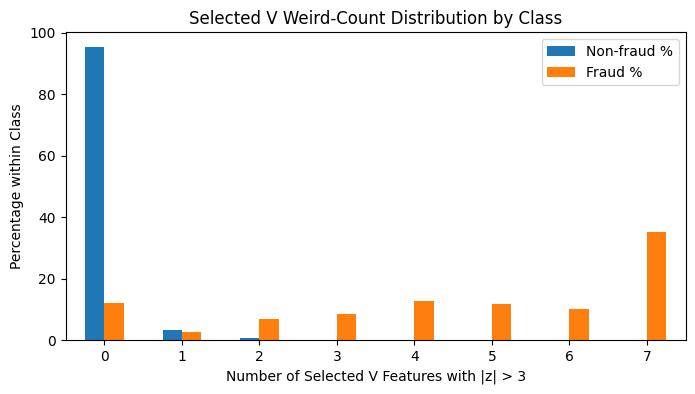

,Non-fraud %,Fraud %
SelectedV_WeirdCount,,
0,95.422683,12.195122
1,3.440198,2.642276
2,0.805445,6.910569
3,0.166716,8.536585
4,0.096020,12.601626
5,0.038689,11.788618
6,0.014772,10.162602
7,0.015476,35.162602


In [64]:
# Visual comparison of the combined unusual-feature score by class
score_counts = pd.crosstab(
    credit_df["SelectedV_WeirdCount"],
    credit_df[credit_target],
    normalize="columns"
) * 100

score_counts.columns = ["Non-fraud %", "Fraud %"]

score_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Selected V Weird-Count Distribution by Class")
plt.xlabel("Number of Selected V Features with |z| > 3")
plt.ylabel("Percentage within Class")
plt.xticks(rotation=0)
plt.show()

score_counts


#### 1.6.9 Weird-count reading

The weird-count result gives a much clearer class difference than most single-feature plots. Non-fraud transactions average only 0.06 selected unusual features and have a median score of 0. Fraud transactions average 4.59 and have a median score of 5.

The percentage table makes the gap even clearer. About 95.4% of non-fraud transactions have a score of 0, while only 12.2% of fraud transactions have a score of 0. At the highest score, 35.2% of fraud transactions hit 7 unusual selected features, compared with almost none of the non-fraud rows. That gives a strong reason to keep multivariate/extreme-value behaviour in the analysis.

#### 1.6.10 Multivariate analysis findings

The multivariate results give a stronger explanation of the fraud pattern than the one-feature plots. The selected PCA-style variables have almost no correlation with each other but several of them still have noticeable relationships with `Class`. `V17`, `V14`, `V12`, and `V10` stand out most in the selected set while `LogAmount` and `Hour` have very weak direct correlation with the target.

The scatter plots show some fraud cases moving away from the densest non-fraud regions, especially in pairs such as `V3`/`V14` and `V17`/`V12`. The separation is still not clean, so the problem does not look like one simple boundary. The amount-hour table adds another useful detail: very low amount transactions during early hours have the highest fraud rates, with the `(-0.001, 1.0]` amount bin reaching about 6.77% at hour 3, 6.21% at hour 4, and 6.18% at hour 2.

The combined unusual-feature score gives one of the clearest multivariate signals. Non-fraud transactions average only 0.06 selected unusual features while fraud transactions average 4.59 and have a median score of 5. About 95.4% of non-fraud transactions score 0 compared with only 12.2% of fraud transactions. That supports using models that can combine several weak and medium signals rather than relying on a single feature.

### 1.7 Credit Card Fraud Weirdness and Outlier Analysis

The previous sections show that fraud does not separate cleanly through one simple variable like `Amount`. A stronger check is to look for transactions that are unusual across several features at the same time.

Unusual values are treated as signals to inspect and not as rows to remove. In a fraud problem, extreme records may carry useful information because fraud often appears as behaviour outside the normal transaction pattern.

#### 1.7.1 Amount outliers using the IQR rule

`Amount` is checked first because it is the most direct transaction variable. The raw amount distribution is very skewed, so the IQR rule gives a rough way to mark unusually large transaction amounts. It will give a useful starting point for comparing the two classes.

In [65]:
# Amount outliers using the IQR rule
if "LogAmount" not in credit_df.columns:
    credit_df["LogAmount"] = np.log1p(credit_df["Amount"])

amount_q1 = credit_df["Amount"].quantile(0.25)
amount_q3 = credit_df["Amount"].quantile(0.75)
amount_iqr = amount_q3 - amount_q1

amount_lower_bound = amount_q1 - 1.5 * amount_iqr
amount_upper_bound = amount_q3 + 1.5 * amount_iqr

credit_df["Amount_IQR_Outlier"] = (
    (credit_df["Amount"] < amount_lower_bound) |
    (credit_df["Amount"] > amount_upper_bound)
)

amount_outlier_summary = credit_df.groupby(credit_target)["Amount_IQR_Outlier"].agg(
    total_transactions="count",
    outlier_count="sum",
    outlier_rate="mean"
)

amount_outlier_summary["outlier_rate_percent"] = amount_outlier_summary["outlier_rate"] * 100

print("Amount Q1:", amount_q1)
print("Amount Q3:", amount_q3)
print("Amount IQR:", amount_iqr)
print("Lower bound:", amount_lower_bound)
print("Upper bound:", amount_upper_bound)

amount_outlier_summary

Amount Q1: 5.6
Amount Q3: 77.16499999999999
Amount IQR: 71.565
Lower bound: -101.7475
Upper bound: 184.5125


,total_transactions,outlier_count,outlier_rate,outlier_rate_percent
Class,,,,
0,284315,31813,0.111893,11.189350
1,492,91,0.184959,18.495935


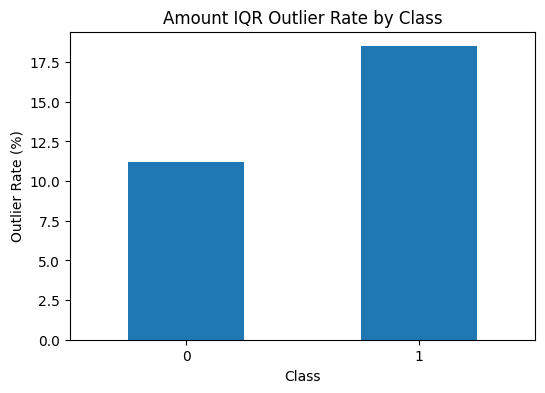

<Figure size 700x400 with 0 Axes>

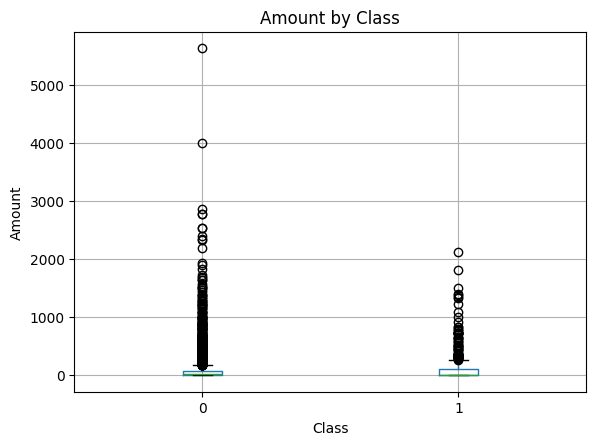

In [66]:
# Visual comparison of Amount outlier rate by class
amount_outlier_summary["outlier_rate_percent"].plot(kind="bar", figsize=(6, 4))
plt.title("Amount IQR Outlier Rate by Class")
plt.xlabel("Class")
plt.ylabel("Outlier Rate (%)")
plt.xticks(rotation=0)
plt.show()

# Boxplot view of Amount by class using the balanced plotting set
if "credit_plot_df" not in globals():
    credit_fraud_df = credit_df[credit_df[credit_target] == 1]
    credit_nonfraud_sample = credit_df[credit_df[credit_target] == 0].sample(
        n=min(5000, (credit_df[credit_target] == 0).sum()),
        random_state=42
    )
    credit_plot_df = pd.concat([credit_nonfraud_sample, credit_fraud_df], axis=0)

plt.figure(figsize=(7, 4))
credit_plot_df.boxplot(column="Amount", by=credit_target)
plt.title("Amount by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

The IQR check places the raw `Amount` upper outlier boundary at about 184.51. Fraud transactions have a higher outlier rate than non-fraud transactions, about 18.5% compared with about 11.2%. That suggests larger transaction amounts appear more often in the fraud class but most fraud cases still do not depend only on having a very large amount.

#### 1.7.2 LogAmount outlier check

The raw `Amount` values are heavily stretched by a small number of large transactions. The log version compresses that range so the same outlier check can show whether the earlier outliers are mostly caused by scale rather than a clear fraud pattern.

In [67]:
# LogAmount outliers using the IQR rule
log_amount_q1 = credit_df["LogAmount"].quantile(0.25)
log_amount_q3 = credit_df["LogAmount"].quantile(0.75)
log_amount_iqr = log_amount_q3 - log_amount_q1

log_amount_lower_bound = log_amount_q1 - 1.5 * log_amount_iqr
log_amount_upper_bound = log_amount_q3 + 1.5 * log_amount_iqr

credit_df["LogAmount_IQR_Outlier"] = (
    (credit_df["LogAmount"] < log_amount_lower_bound) |
    (credit_df["LogAmount"] > log_amount_upper_bound)
)

log_amount_outlier_summary = credit_df.groupby(credit_target)["LogAmount_IQR_Outlier"].agg(
    total_transactions="count",
    outlier_count="sum",
    outlier_rate="mean"
)

log_amount_outlier_summary["outlier_rate_percent"] = log_amount_outlier_summary["outlier_rate"] * 100

print("LogAmount Q1:", log_amount_q1)
print("LogAmount Q3:", log_amount_q3)
print("LogAmount IQR:", log_amount_iqr)
print("Lower bound:", log_amount_lower_bound)
print("Upper bound:", log_amount_upper_bound)

log_amount_outlier_summary

LogAmount Q1: 1.8870696490323797
LogAmount Q3: 4.358821974983384
LogAmount IQR: 2.471752325951004
Lower bound: -1.8205588398941264
Upper bound: 8.06645046390989


,total_transactions,outlier_count,outlier_rate,outlier_rate_percent
Class,,,,
0,284315,245,0.000862,0.086172
1,492,0,0.000000,0.000000


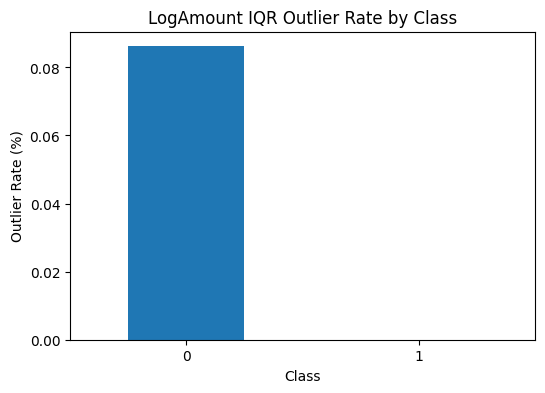

<Figure size 700x400 with 0 Axes>

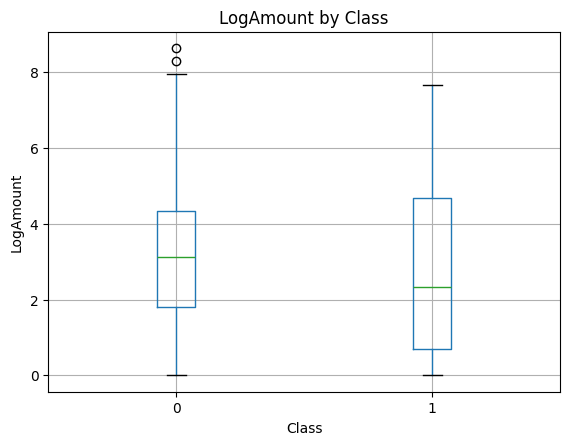

In [68]:
# Visual comparison of LogAmount outlier rate by class
log_amount_outlier_summary["outlier_rate_percent"].plot(kind="bar", figsize=(6, 4))
plt.title("LogAmount IQR Outlier Rate by Class")
plt.xlabel("Class")
plt.ylabel("Outlier Rate (%)")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(7, 4))
credit_plot_df.boxplot(column="LogAmount", by=credit_target)
plt.title("LogAmount by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("LogAmount")
plt.show()

After applying the log transform, the IQR outlier count drops sharply. The fraud class does not appear as a log-amount outlier group under that rule. That makes the raw amount outlier result look partly driven by the long right tail of transaction amounts rather than by a clean fraud/non-fraud split.

#### 1.7.3 Weirdness score across all V features

The anonymized `V1` to `V28` features are harder to interpret directly, so a transaction-level score is used. Each transaction gets one point for every V feature where the absolute z-score is greater than 3. A larger count means the transaction is unusual across more PCA-transformed features.

In [69]:
# Weirdness score across all V features using standard z-scores
v_features = [col for col in credit_df.columns if col.startswith("V")]

v_means = credit_df[v_features].mean()
v_stds = credit_df[v_features].std(ddof=0)

v_z_scores = (credit_df[v_features] - v_means) / v_stds

credit_df["AllV_WeirdCount_Z3"] = (v_z_scores.abs() > 3).sum(axis=1)

weird_count_summary = credit_df.groupby(credit_target)["AllV_WeirdCount_Z3"].agg(
    total_transactions="count",
    mean_weird_count="mean",
    median_weird_count="median",
    max_weird_count="max"
)

weird_count_summary

,total_transactions,mean_weird_count,median_weird_count,max_weird_count
Class,,,,
0,284315,0.264963,0.0,26
1,492,8.514228,7.0,22


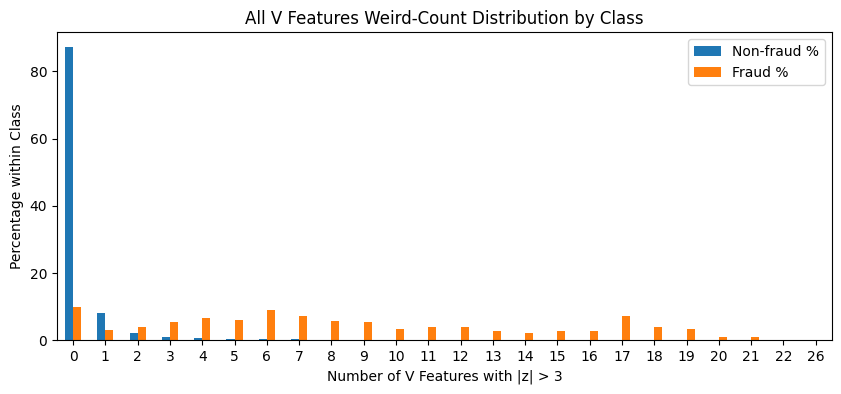

,Non-fraud %,Fraud %
AllV_WeirdCount_Z3,,
0,87.270105,9.959350
1,7.999578,3.048780
2,2.035418,3.861789
3,0.854686,5.487805
4,0.514218,6.504065
5,0.333785,6.097561
6,0.283488,8.943089
7,0.238820,7.113821
8,0.165661,5.691057


In [70]:
# Distribution of V-feature weird counts by class
weird_count_distribution = pd.crosstab(
    credit_df["AllV_WeirdCount_Z3"],
    credit_df[credit_target],
    normalize="columns"
) * 100

weird_count_distribution.columns = ["Non-fraud %", "Fraud %"]

weird_count_distribution.plot(kind="bar", figsize=(10, 4))
plt.title("All V Features Weird-Count Distribution by Class")
plt.xlabel("Number of V Features with |z| > 3")
plt.ylabel("Percentage within Class")
plt.xticks(rotation=0)
plt.show()

weird_count_distribution

The z-score weirdness result gives a much clearer class difference than `Amount`. Non-fraud transactions usually have no extreme V values with an average weird-count close to 0.26. Fraud transactions have an average weird-count above 8 and a median of 7. That suggests fraudulent transactions are not only slightly different in one feature. Many fraud cases sit far from the normal pattern across several anonymized features at the same time.

#### 1.7.4 Weird-count threshold comparison

A threshold table gives a more direct view of how often each class crosses different weirdness levels. It also shows whether a simple rule like “at least 3 weird V features” catches many fraud cases and how many non-fraud cases would also be flagged.


In [71]:
# Compare different weird-count thresholds
weird_threshold_rows = []

for threshold in [1, 2, 3, 4, 5, 6, 8, 10]:
    row = {"weird_count_threshold": threshold}

    for class_value, label in [(0, "nonfraud"), (1, "fraud")]:
        class_values = credit_df.loc[
            credit_df[credit_target] == class_value,
            "AllV_WeirdCount_Z3"
        ]

        row[f"{label}_count_at_or_above"] = (class_values >= threshold).sum()
        row[f"{label}_percent_at_or_above"] = (class_values >= threshold).mean() * 100

    weird_threshold_rows.append(row)

weird_threshold_table = pd.DataFrame(weird_threshold_rows)
weird_threshold_table

,weird_count_threshold,nonfraud_count_at_or_above,nonfraud_percent_at_or_above,fraud_count_at_or_above,fraud_percent_at_or_above
0,1,36193,12.729895,443,90.040650
1,2,13449,4.730317,428,86.991870
2,3,7662,2.694898,409,83.130081
3,4,5232,1.840212,382,77.642276
4,5,3770,1.325994,350,71.138211
5,6,2821,0.992209,320,65.040650
6,8,1336,0.469901,241,48.983740
7,10,574,0.201889,187,38.008130


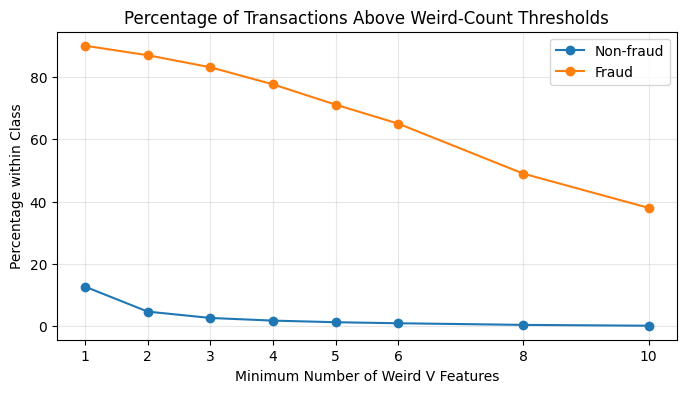

In [72]:
# Plot fraud and non-fraud percentages above each weird-count threshold
plt.figure(figsize=(8, 4))
plt.plot(
    weird_threshold_table["weird_count_threshold"],
    weird_threshold_table["nonfraud_percent_at_or_above"],
    marker="o",
    label="Non-fraud"
)
plt.plot(
    weird_threshold_table["weird_count_threshold"],
    weird_threshold_table["fraud_percent_at_or_above"],
    marker="o",
    label="Fraud"
)

plt.title("Percentage of Transactions Above Weird-Count Thresholds")
plt.xlabel("Minimum Number of Weird V Features")
plt.ylabel("Percentage within Class")
plt.xticks(weird_threshold_table["weird_count_threshold"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The threshold comparison shows a strong separation. At least 3 weird V features captures about 83% of fraud transactions but only about 2.7% of non-fraud transactions. Even at 8 weird V features, close to half of the fraud class still remains above the threshold, while less than 1% of non-fraud transactions does. That makes the weird-count score a useful engineered signal for later modelling or interpretation.

#### 1.7.5 Robust weirdness score

A normal z-score uses the mean and standard deviation, which can be pulled by extreme values. A robust version uses the median and median absolute deviation instead. That gives a second check for whether the same pattern remains when the score is less affected by outliers.


In [73]:
# Robust z-score weirdness using median and MAD
robust_z_scores = pd.DataFrame(index=credit_df.index)

for col in v_features:
    median_value = credit_df[col].median()
    mad_value = np.median(np.abs(credit_df[col] - median_value))

    if mad_value == 0:
        robust_z_scores[col] = 0
    else:
        robust_z_scores[col] = 0.6745 * (credit_df[col] - median_value) / mad_value

credit_df["AllV_WeirdCount_Robust3_5"] = (robust_z_scores.abs() > 3.5).sum(axis=1)

robust_weird_summary = credit_df.groupby(credit_target)["AllV_WeirdCount_Robust3_5"].agg(
    total_transactions="count",
    mean_robust_weird_count="mean",
    median_robust_weird_count="median",
    max_robust_weird_count="max"
)

robust_weird_summary

,total_transactions,mean_robust_weird_count,median_robust_weird_count,max_robust_weird_count
Class,,,,
0,284315,0.670781,0.0,27
1,492,10.485772,10.0,22


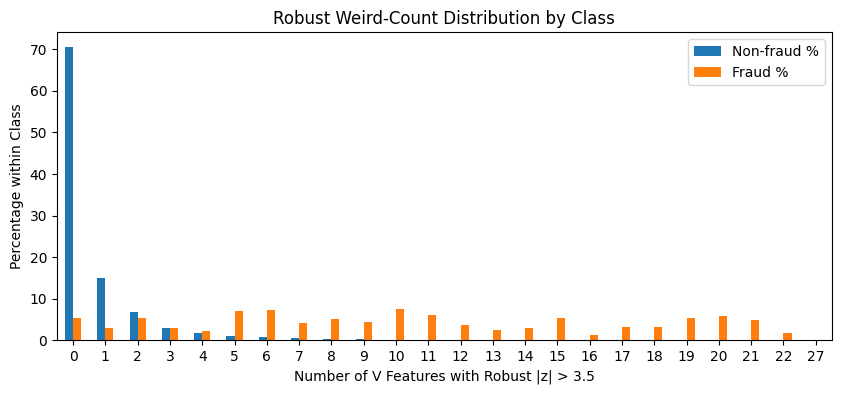

,Non-fraud %,Fraud %
AllV_WeirdCount_Robust3_5,,
0,70.560470,5.284553
1,14.863092,3.048780
2,6.754832,5.284553
3,3.015669,2.845528
4,1.645358,2.235772
5,0.901465,6.910569
6,0.657721,7.317073
7,0.466032,4.065041
8,0.368254,5.081301


In [74]:
# Visual comparison of robust weird-count by class
robust_weird_distribution = pd.crosstab(
    credit_df["AllV_WeirdCount_Robust3_5"],
    credit_df[credit_target],
    normalize="columns"
) * 100

robust_weird_distribution.columns = ["Non-fraud %", "Fraud %"]

robust_weird_distribution.plot(kind="bar", figsize=(10, 4))
plt.title("Robust Weird-Count Distribution by Class")
plt.xlabel("Number of V Features with Robust |z| > 3.5")
plt.ylabel("Percentage within Class")
plt.xticks(rotation=0)
plt.show()

robust_weird_distribution

The robust score supports the same general pattern as the standard z-score method. Fraud transactions still have a much higher weird-count than non-fraud transactions. The median robust weird-count is around 10 for fraud and 0 for non-fraud, so the difference is not only caused by the standard deviation method being sensitive to extreme rows.

#### 1.7.6 V features with the strongest extreme-value difference

The feature-level table checks which V features most often become extreme for fraud compared with non-fraud. That gives a more detailed view of where the weirdness score is coming from.


In [75]:
# Identify V features where extreme values are much more common in fraud
extreme_feature_rows = []

for col in v_features:
    extreme_flag = v_z_scores[col].abs() > 3

    nonfraud_extreme_rate = extreme_flag[credit_df[credit_target] == 0].mean() * 100
    fraud_extreme_rate = extreme_flag[credit_df[credit_target] == 1].mean() * 100

    extreme_feature_rows.append({
        "feature": col,
        "nonfraud_extreme_percent": nonfraud_extreme_rate,
        "fraud_extreme_percent": fraud_extreme_rate,
        "percentage_point_difference": fraud_extreme_rate - nonfraud_extreme_rate,
        "nonfraud_extreme_count": extreme_flag[credit_df[credit_target] == 0].sum(),
        "fraud_extreme_count": extreme_flag[credit_df[credit_target] == 1].sum()
    })

extreme_feature_table = pd.DataFrame(extreme_feature_rows).sort_values(
    "percentage_point_difference",
    ascending=False
)

extreme_feature_table.head(12)

,feature,nonfraud_extreme_percent,fraud_extreme_percent,percentage_point_difference,nonfraud_extreme_count,fraud_extreme_count
13,V14,1.044264,83.536585,82.492321,2969,411
16,V17,0.754797,75.000000,74.245203,2146,369
11,V12,1.063609,75.000000,73.936391,3024,369
9,V10,1.112147,66.260163,65.148016,3162,326
10,V11,0.138579,58.943089,58.804511,394,290
15,V16,0.627825,59.349593,58.721769,1785,292
2,V3,0.603556,55.081301,54.477745,1716,271
3,V4,1.003464,48.983740,47.980275,2853,241
6,V7,1.119533,44.308943,43.189410,3183,218
17,V18,0.517736,43.292683,42.774947,1472,213


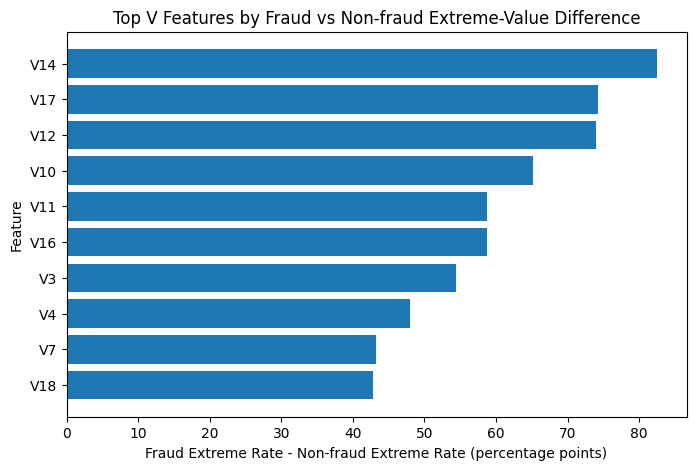

In [76]:
# Plot strongest V features by extreme-value difference
top_extreme_features = extreme_feature_table.head(10).copy()

plt.figure(figsize=(8, 5))
plt.barh(
    top_extreme_features["feature"][::-1],
    top_extreme_features["percentage_point_difference"][::-1]
)
plt.title("Top V Features by Fraud vs Non-fraud Extreme-Value Difference")
plt.xlabel("Fraud Extreme Rate - Non-fraud Extreme Rate (percentage points)")
plt.ylabel("Feature")
plt.show()

The strongest extreme-value differences come from features such as `V14`, `V17`, `V12`, `V10`, `V11`, and `V16`. For example, `V14` is extreme for a large share of fraud transactions but only a small share of non-fraud transactions.

That result matches the bivariate and multivariate findings where several of the same V features showed stronger class separation.


#### 1.7.7 Weirdness and outlier findings

The outlier analysis gives two different results. Raw `Amount` has some relationship with fraud, but the separation is not strong enough by itself. The stronger result comes from the anonymized V features where fraud transactions tend to have more extreme values across several columns. That supports the idea that fraud is not only a high-amount problem. It shows up more clearly when several weak signals are considered together.


### 1.8 Preprocessing and Modelling Decisions

A conservative first modelling setup rather than heavy cleaning will be done. The data has no missing or invalid numeric values, but it has severe class imbalance, skewed transaction amounts, large scale differences, and extreme V-feature patterns linked to fraud.

The decisions below connect those findings to the first modelling setup. Later experiments can add engineered features or threshold tuning, but the first run stays controlled enough to compare the three models fairly.

#### 1.8.1 Decision summary from the analysis

The table below turns the main findings into preprocessing and modelling choices.


In [77]:
# Preprocessing and modelling decisions based on the credit card EDA
credit_target = credit_info["target"] if "credit_info" in globals() else "Class"
v_features = [f"V{i}" for i in range(1, 29) if f"V{i}" in credit_df.columns]

preprocessing_decisions = pd.DataFrame({
    "Finding": [
        "No missing or invalid numeric values",
        "1,081 duplicate rows were found",
        "Amount is heavily right-skewed",
        "Time is easier to read after converting to Hour",
        "Fraud is about 0.173% of the data",
        "Some V features show stronger class separation",
        "Fraud has much higher V-feature weirdness scores",
        "EDA helper columns were created during analysis",
        "The minority fraud class has very few examples"
    ],
    "Decision for modelling": [
        "No imputation needed for the credit card data",
        "Keep duplicates in the first run; removal would be a separate experiment",
        "Scale numeric features; test LogAmount later as engineered input",
        "Keep Time in the baseline; test Hour later as engineered input",
        "Use stratified splitting and imbalance-aware metrics",
        "Keep the anonymized V features in the model input",
        "Keep outliers; do not cap or remove extreme rows automatically",
        "Exclude helper columns from the first baseline model run",
        "Test class weights and SMOTE as separate imbalance-handling approaches"
    ],
    "Reason": [
        "The quality checks did not show missing values, negative Amount/Time values, or invalid class labels.",
        "Repeated-looking transactions may still represent real behaviour, especially in a fraud dataset.",
        "Large transaction values can dominate scale-sensitive models if left untreated.",
        "Hour gives a readable time pattern, but it should be tested separately from the baseline.",
        "Accuracy can look strong while missing almost every fraud case.",
        "Features such as V14, V17, V12, and V10 showed stronger separation than Amount or Hour alone.",
        "Fraud cases often sit far from the normal pattern across several transformed features.",
        "Some helper columns were calculated from the full data during EDA, so using them directly could weaken the evaluation.",
        "SMOTE can create extra minority-class training examples, but it has to be applied only after the train-test split."
    ]
})

pd.set_option("display.max_colwidth", 120)
display(preprocessing_decisions)


,Finding,Decision for modelling,Reason
0,No missing or invalid numeric values,No imputation needed for the credit card data,"The quality checks did not show missing values, negative Amount/Time values, or invalid class labels."
1,"1,081 duplicate rows were found",Keep duplicates in the first run; removal would be a separate experiment,"Repeated-looking transactions may still represent real behaviour, especially in a fraud dataset."
2,Amount is heavily right-skewed,Scale numeric features; test LogAmount later as engineered input,Large transaction values can dominate scale-sensitive models if left untreated.
3,Time is easier to read after converting to Hour,Keep Time in the baseline; test Hour later as engineered input,"Hour gives a readable time pattern, but it should be tested separately from the baseline."
4,Fraud is about 0.173% of the data,Use stratified splitting and imbalance-aware metrics,Accuracy can look strong while missing almost every fraud case.
5,Some V features show stronger class separation,Keep the anonymized V features in the model input,"Features such as V14, V17, V12, and V10 showed stronger separation than Amount or Hour alone."
6,Fraud has much higher V-feature weirdness scores,Keep outliers; do not cap or remove extreme rows automatically,Fraud cases often sit far from the normal pattern across several transformed features.
7,EDA helper columns were created during analysis,Exclude helper columns from the first baseline model run,"Some helper columns were calculated from the full data during EDA, so using them directly could weaken the evaluation."
8,The minority fraud class has very few examples,Test class weights and SMOTE as separate imbalance-handling approaches,"SMOTE can create extra minority-class training examples, but it has to be applied only after the train-test split."


The first model run stays close to the original credit card feature set. Outlier flags and weirdness scores helped describe the data but they were created during analysis and are better treated as engineered-feature experiments later. SMOTE is also kept as a separate experiment because it changes the training distribution instead of simply cleaning the data.

#### 1.8.2 Feature set for the first credit card model run

The first model run uses the original credit card variables only: `Time`, `Amount`, and `V1` to `V28`. Engineered features such as `LogAmount`, `Hour`, and weirdness scores can be tested later as a separate experiment.


In [78]:
# Build a clean modelling dataframe for the first credit card model run
credit_base_feature_cols = ["Time"] + v_features + ["Amount"]
credit_model_df = credit_df[credit_base_feature_cols + [credit_target]].copy()

# EDA columns are useful for analysis but are not used in the first baseline model run
eda_helper_cols = [
    col for col in credit_df.columns
    if col not in credit_base_feature_cols + [credit_target]
]

model_feature_summary = pd.DataFrame({
    "Item": [
        "Rows used",
        "Feature columns used",
        "Target column",
        "EDA/helper columns excluded"
    ],
    "Value": [
        credit_model_df.shape[0],
        len(credit_base_feature_cols),
        credit_target,
        len(eda_helper_cols)
    ]
})

display(model_feature_summary)
print("Feature columns used:")
print(credit_base_feature_cols)
print("\nAnalysis/helper columns excluded from the first model run:")
print(eda_helper_cols)


,Item,Value
0,Rows used,284807
1,Feature columns used,30
2,Target column,Class
3,EDA/helper columns excluded,8


Feature columns used:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Analysis/helper columns excluded from the first model run:
['LogAmount', 'Hour', 'AmountBin', 'SelectedV_WeirdCount', 'Amount_IQR_Outlier', 'LogAmount_IQR_Outlier', 'AllV_WeirdCount_Z3', 'AllV_WeirdCount_Robust3_5']


Using the original feature set gives a fair baseline for Logistic Regression, Random Forest, and XGBoost. The engineered columns are not being ignored permanently. They are just held back so their effect can be tested later instead of mixed into the first comparison.


#### 1.8.3 Train-test split and leakage control

The split must stay stratified because fraud cases are rare. Any preprocessing step that learns from the data, such as scaling or resampling, is fitted only on the training set. That avoids test data influencing the training process.


In [79]:
# Check the class ratio after the modelling split
X_credit_base = credit_model_df.drop(columns=[credit_target])
y_credit_base = credit_model_df[credit_target]

X_credit_train_base, X_credit_test_base, y_credit_train_base, y_credit_test_base = train_test_split(
    X_credit_base,
    y_credit_base,
    test_size=0.2,
    random_state=42,
    stratify=y_credit_base
)

split_ratio_check = pd.DataFrame({
    "Dataset part": ["Full data", "Training set", "Test set"],
    "Rows": [len(y_credit_base), len(y_credit_train_base), len(y_credit_test_base)],
    "Fraud count": [
        int((y_credit_base == 1).sum()),
        int((y_credit_train_base == 1).sum()),
        int((y_credit_test_base == 1).sum())
    ],
    "Fraud percent": [
        (y_credit_base == 1).mean() * 100,
        (y_credit_train_base == 1).mean() * 100,
        (y_credit_test_base == 1).mean() * 100
    ]
})

display(split_ratio_check)


,Dataset part,Rows,Fraud count,Fraud percent
0,Full data,284807,492,0.172749
1,Training set,227845,394,0.172925
2,Test set,56962,98,0.172045


The stratified split keeps the fraud percentage close to the full dataset ratio in both training and testing. That gives the models fraud examples to learn from and keeps the test set useful for recall, precision, and F1-score.


#### 1.8.4 Imbalance settings for the models

The first three-model comparison already uses class weighting for Logistic Regression and Random Forest. XGBoost can also use the imbalance ratio through `scale_pos_weight`. SMOTE will be tested separately because it creates synthetic fraud examples and may change the recall/precision balance.

In [80]:
# Imbalance ratio that can be used for class weighting or XGBoost scale_pos_weight
nonfraud_count = int((y_credit_base == 0).sum())
fraud_count = int((y_credit_base == 1).sum())
credit_scale_pos_weight = nonfraud_count / fraud_count

imbalance_settings = pd.DataFrame({
    "Item": [
        "Non-fraud count",
        "Fraud count",
        "Non-fraud to fraud ratio",
        "Suggested XGBoost scale_pos_weight"
    ],
    "Value": [
        nonfraud_count,
        fraud_count,
        round(credit_scale_pos_weight, 2),
        round(credit_scale_pos_weight, 2)
    ]
})

display(imbalance_settings)


,Item,Value
0,Non-fraud count,284315.00
1,Fraud count,492.00
2,Non-fraud to fraud ratio,577.88
3,Suggested XGBoost scale_pos_weight,577.88


The imbalance ratio is large enough that a normal accuracy-focused setup would be pointless. The first model comparison is read as a recall/precision trade-off.

#### 1.8.5 Preprocessing decision summary

The preprocessing plan keeps the first model run controlled. The original features are used first, scaling is applied inside the preprocessing function, and the train-test split remains stratified. Outliers and unusual values are kept because they may contain useful fraud patterns. Class imbalance is handled through class weights, SMOTE experiments, threshold tuning, and later a cost-based comparison instead of relying on accuracy alone.


### 1.9 Credit Card Fraud Baseline Model Run

The first credit card experiment uses the baseline feature set: `Time`, `Amount`, and the anonymized `V1` to `V28` variables. The EDA helper columns are left out so the first comparison is not mixed with engineered features that were created during analysis.

The analysis results point toward recall, precision, F1-score, ROC-AUC, and later threshold/cost checks as the more useful way to read the model results. `Amount` and `Hour` give some useful context but the stronger fraud signals appear across several transformed V features and in the combined extreme-value behaviour.

,dataset,model,accuracy,precision,recall,f1,roc_auc
2,Credit Card Fraud,XGBoost,0.999561,0.901099,0.836735,0.867725,0.977750
1,Credit Card Fraud,Random Forest,0.999526,0.961039,0.755102,0.845714,0.957189
0,Credit Card Fraud,Logistic Regression,0.975528,0.060976,0.918367,0.114358,0.972083


<Figure size 500x400 with 0 Axes>

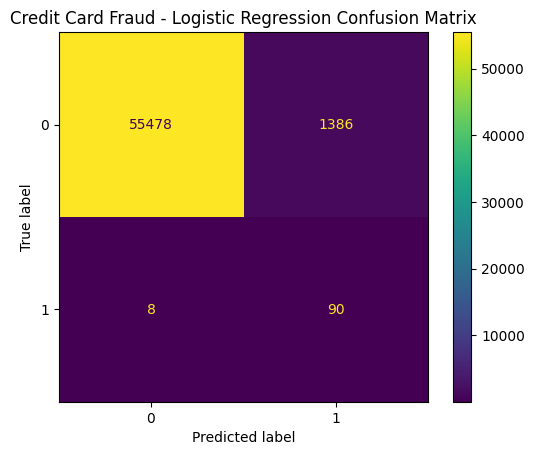

<Figure size 500x400 with 0 Axes>

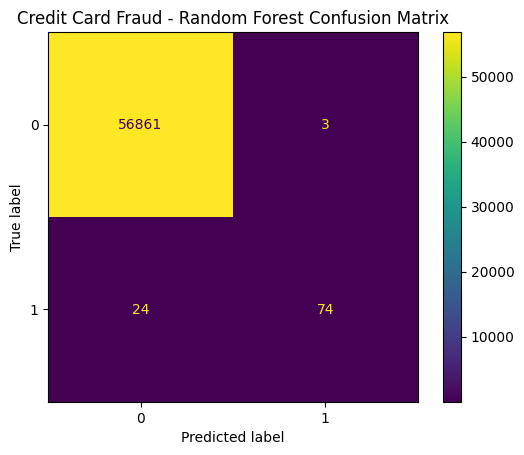

<Figure size 500x400 with 0 Axes>

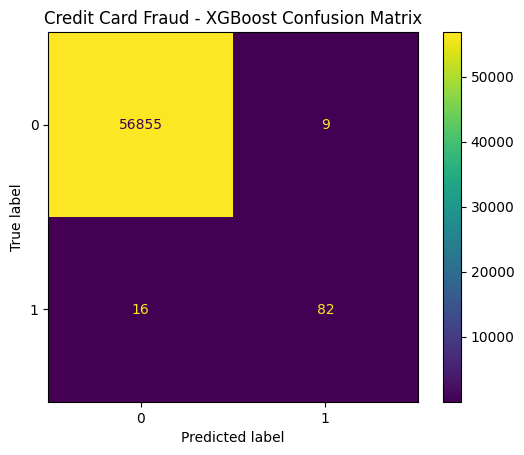

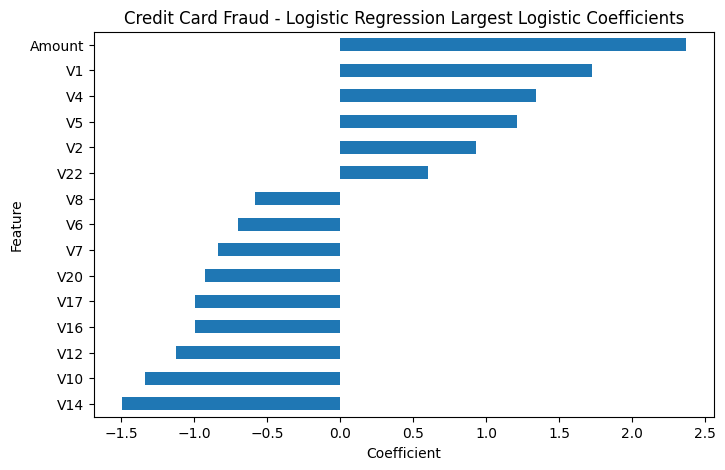

,coefficient
Amount,2.367276
V1,1.723862
V14,-1.494961
V4,1.339431
V10,-1.334996
V5,1.214379
V12,-1.127886
V16,-0.996376
V17,-0.992185
V2,0.932075


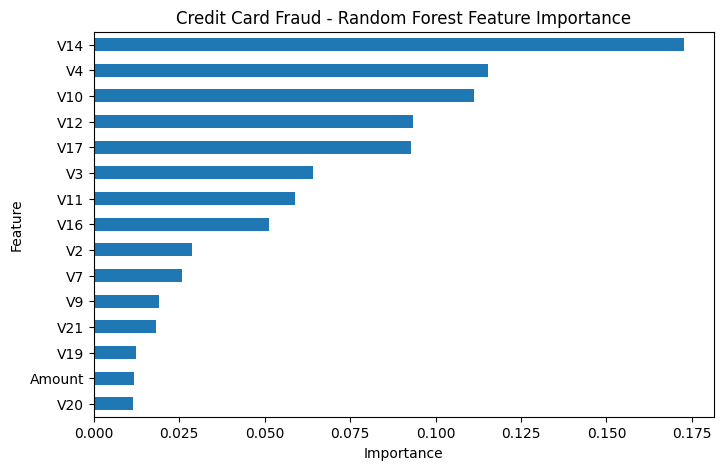

,importance
V14,0.172755
V4,0.115382
V10,0.111231
V12,0.093417
V17,0.092719
V3,0.064234
V11,0.058795
V16,0.051311
V2,0.028824
V7,0.025840


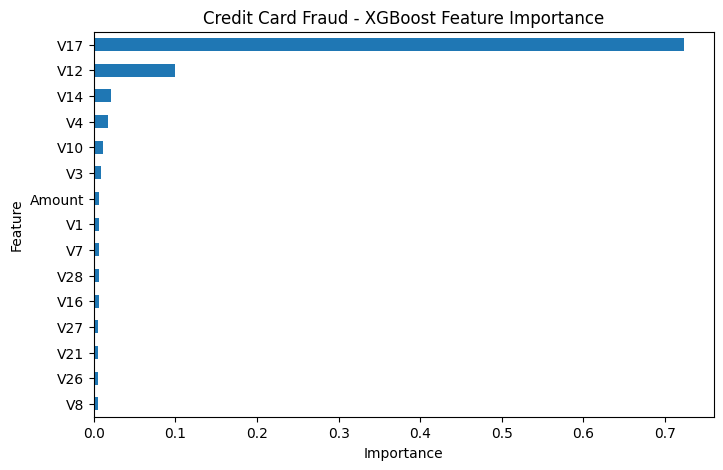

,importance
V17,0.723470
V12,0.098951
V14,0.021419
V4,0.017404
V10,0.011156
V3,0.008372
Amount,0.006742
V1,0.006711
V7,0.006553
V28,0.006461


In [81]:
# Use the cleaned credit card modelling dataframe from Section 9 when available
if "credit_model_df" not in globals():
    credit_target = credit_info["target"] if "credit_info" in globals() else "Class"
    v_features = [f"V{i}" for i in range(1, 29) if f"V{i}" in credit_df.columns]
    credit_base_feature_cols = ["Time"] + v_features + ["Amount"]
    credit_model_df = credit_df[credit_base_feature_cols + [credit_target]].copy()

X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = preprocess_for_model(credit_model_df, credit_info["target"])
credit_results, credit_models = train_and_evaluate_models(
    X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, "Credit Card Fraud"
)
display(credit_results)
plot_confusion_matrices(credit_models, X_test, X_test_scaled, y_test, "Credit Card Fraud")

for model_name, obj in credit_models.items():
    plot_feature_importance(obj["model"], X_train.columns, "Credit Card Fraud", model_name, top_n=15)


### 1.10 Credit Card Fraud Baseline Model Evaluation

From the confusion matrices, Logistic Regression has the highest recall. It correctly identifies 90 fraud cases while missing 8, so it is the strongest model for catching fraud in the baseline run. XGBoost follows with 79 true positives and 19 false negatives, while Random Forest catches 74 fraud cases and misses 24.

Precision tells a different story. Random Forest has the cleanest fraud predictions, with only 3 false positives while correctly identifying 74 fraud cases. XGBoost also keeps false positives low with 5. Logistic Regression creates many more false positives, with 1,386 normal transactions flagged as fraud.

Accuracy does not add much here because the data is heavily imbalanced. The real trade-off is between catching more fraud and avoiding too many false alarms. Based on the baseline run, Logistic Regression is better for recall, Random Forest is better for precision, and XGBoost gives a more balanced middle point. Later threshold tuning and a cost-based score can make that comparison fairer than using the default 0.5 decision threshold only.

### 1.11 Credit Card Fraud Imbalance-Handling Experiments

The baseline results show a clear trade-off. Logistic Regression catches the most fraud cases, but it also creates many false alarms. Random Forest and XGBoost are more conservative, with much better precision but lower recall. The next experiment tests whether imbalance-handling methods can improve that trade-off.

Two approaches are compared here. Class weighting changes how strongly the model penalizes mistakes on fraud cases. SMOTE creates synthetic fraud examples inside the training set, giving the model more minority-class patterns to learn from. SMOTE is only applied after the train-test split so the test set stays untouched.

In [82]:
# Extra imports for imbalance experiments
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.base import clone
from importlib.metadata import version

try:
    import sklearn
    import imblearn

    print("scikit-learn version:", version("scikit-learn"))
    print("imbalanced-learn version:", version("imbalanced-learn"))

    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE

except Exception as exc:
    raise ImportError(
        "The SMOTE experiments need compatible versions of scikit-learn and imbalanced-learn. "
        "In Colab, try running this in a separate cell, then restart the runtime: "
        '!pip install -q "numpy<2.1" "scikit-learn==1.6.1" "imbalanced-learn==0.13.0"'
    ) from exc


scikit-learn version: 1.6.1
imbalanced-learn version: 0.14.1


#### 1.11.1 Experiment setup

The same stratified train-test split from the baseline run is reused. That keeps the comparison fair because each model is tested on the same fraud and non-fraud cases. Scaling is kept inside the Logistic Regression pipelines, while tree-based models use the original feature scale.

In [83]:
# Reuse the conservative credit card feature set from Section 9
X_imbalance = credit_model_df.drop(columns=[credit_target])
y_imbalance = credit_model_df[credit_target]

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imbalance,
    y_imbalance,
    test_size=0.2,
    random_state=42,
    stratify=y_imbalance
)

imbalance_split_check = pd.DataFrame({
    "Dataset part": ["Training set", "Test set"],
    "Rows": [len(y_train_imb), len(y_test_imb)],
    "Fraud count": [int((y_train_imb == 1).sum()), int((y_test_imb == 1).sum())],
    "Fraud percent": [(y_train_imb == 1).mean() * 100, (y_test_imb == 1).mean() * 100]
})

display(imbalance_split_check)


,Dataset part,Rows,Fraud count,Fraud percent
0,Training set,227845,394,0.172925
1,Test set,56962,98,0.172045


#### 1.11.2 Models tested

The same three model families are tested with different imbalance-handling choices. Logistic Regression is tested with class weights and with SMOTE. Random Forest is tested with class weights and with SMOTE. XGBoost is tested with the original setup, with `scale_pos_weight`, and with SMOTE.

The SMOTE models use the official `imbalanced-learn` implementation. SMOTE stays inside the training pipeline, so synthetic fraud examples are created from the training set only. The test set is left in its original imbalanced form.

In [84]:
# Model variants for imbalance-handling comparison
credit_scale_pos_weight = (y_train_imb == 0).sum() / (y_train_imb == 1).sum()

# A small preview of what SMOTE does to the training split.
# Scaling is used before SMOTE because SMOTE relies on nearest-neighbour distances.
smote_preview_scaler = StandardScaler()
X_train_imb_scaled_preview = pd.DataFrame(
    smote_preview_scaler.fit_transform(X_train_imb),
    columns=X_train_imb.columns
)

X_train_smote_preview, y_train_smote_preview = SMOTE(random_state=42).fit_resample(
    X_train_imb_scaled_preview,
    y_train_imb
)

smote_training_rows = len(y_train_smote_preview)
smote_training_fraud_percent = (pd.Series(y_train_smote_preview) == 1).mean() * 100

smote_preview_summary = pd.DataFrame({
    "Training version": ["Original training split", "After SMOTE"],
    "Rows": [len(y_train_imb), smote_training_rows],
    "Fraud count": [int((y_train_imb == 1).sum()), int((pd.Series(y_train_smote_preview) == 1).sum())],
    "Fraud percent": [(y_train_imb == 1).mean() * 100, smote_training_fraud_percent]
})

display(smote_preview_summary)

imbalance_model_variants = {
    "LogReg class_weight": SklearnPipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),

    "LogReg SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "RandomForest class_weight": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "RandomForest SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost baseline": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost scale_pos_weight": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=credit_scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

list(imbalance_model_variants.keys())


,Training version,Rows,Fraud count,Fraud percent
0,Original training split,227845,394,0.172925
1,After SMOTE,454902,227451,50.000000


['LogReg class_weight',
 'LogReg SMOTE',
 'RandomForest class_weight',
 'RandomForest SMOTE',
 'XGBoost baseline',
 'XGBoost scale_pos_weight',
 'XGBoost SMOTE']

#### 1.11.3 Training and evaluation table

The table keeps the default decision threshold of 0.5 for now. That separates the model-training comparison from the later threshold-tuning step. The SMOTE rows need careful reading because their training data has been balanced, while the test set still keeps the real fraud ratio.

In [85]:
# Train and evaluate the imbalance-handling model variants
credit_imbalance_rows = []
credit_imbalance_models = {}

for model_name, model in imbalance_model_variants.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train_imb, y_train_imb)

    y_pred = fitted_model.predict(X_test_imb)

    if hasattr(fitted_model, "predict_proba"):
        y_prob = fitted_model.predict_proba(X_test_imb)[:, 1]
    else:
        y_prob = None

    tn, fp, fn, tp = confusion_matrix(y_test_imb, y_pred).ravel()
    used_smote = "SMOTE" in model_name

    credit_imbalance_rows.append({
        "model": model_name,
        "training_rows_used": smote_training_rows if used_smote else len(y_train_imb),
        "training_fraud_percent": round(smote_training_fraud_percent if used_smote else (y_train_imb == 1).mean() * 100, 4),
        "accuracy": accuracy_score(y_test_imb, y_pred),
        "precision": precision_score(y_test_imb, y_pred, zero_division=0),
        "recall": recall_score(y_test_imb, y_pred, zero_division=0),
        "f1": f1_score(y_test_imb, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test_imb, y_prob) if y_prob is not None else np.nan,
        "pr_auc": average_precision_score(y_test_imb, y_prob) if y_prob is not None else np.nan,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "predicted_fraud_count": int((y_pred == 1).sum())
    })

    credit_imbalance_models[model_name] = {
        "model": fitted_model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "used_smote": used_smote
    }

credit_imbalance_results = pd.DataFrame(credit_imbalance_rows)
credit_imbalance_results = credit_imbalance_results.sort_values(
    by=["f1", "pr_auc"],
    ascending=False
).reset_index(drop=True)

display(credit_imbalance_results)


,model,training_rows_used,training_fraud_percent,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,predicted_fraud_count
0,XGBoost baseline,227845,0.1729,0.999561,0.901099,0.836735,0.867725,0.977750,0.876141,56855,9,16,82,91
1,XGBoost scale_pos_weight,227845,0.1729,0.999526,0.881720,0.836735,0.858639,0.975484,0.875963,56853,11,16,82,93
2,RandomForest SMOTE,454902,50.0000,0.999491,0.870968,0.826531,0.848168,0.975422,0.871804,56852,12,17,81,93
3,RandomForest class_weight,227845,0.1729,0.999526,0.961039,0.755102,0.845714,0.957189,0.858928,56861,3,24,74,77
4,XGBoost SMOTE,454902,50.0000,0.998894,0.625899,0.887755,0.734177,0.979973,0.866763,56812,52,11,87,139
5,LogReg class_weight,227845,0.1729,0.975528,0.060976,0.918367,0.114358,0.972083,0.718971,55478,1386,8,90,1476
6,LogReg SMOTE,454902,50.0000,0.974106,0.057803,0.918367,0.108761,0.970843,0.724469,55397,1467,8,90,1557


#### 1.11.4 Confusion matrix comparison

The confusion matrices show the trade-off in a more direct way than the metric table. A model with fewer false negatives catches more fraud, while a model with fewer false positives avoids blocking more genuine transactions. For fraud detection, the stronger model depends on how costly missed fraud is compared with false alarms.

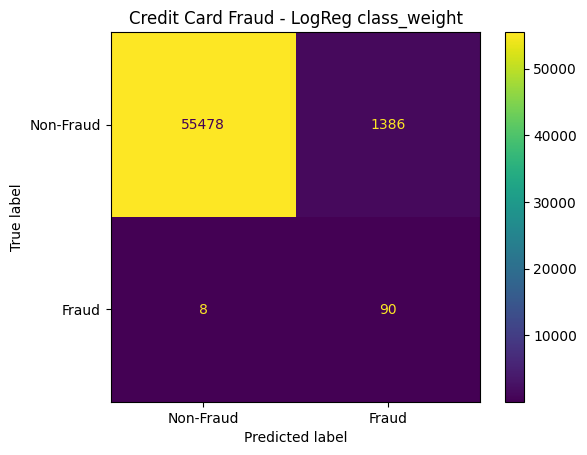

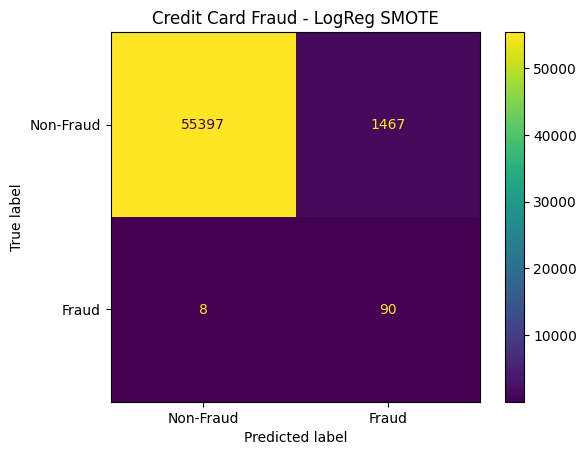

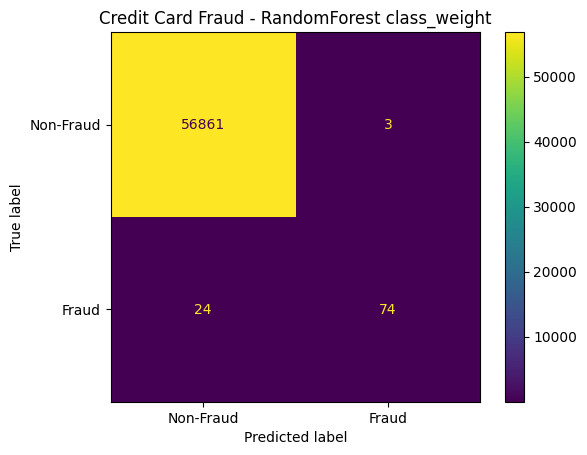

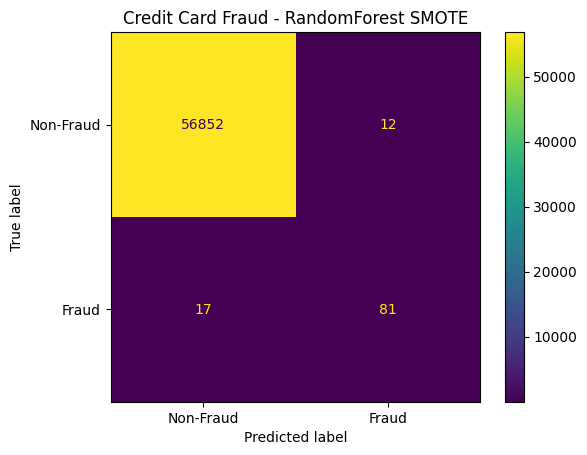

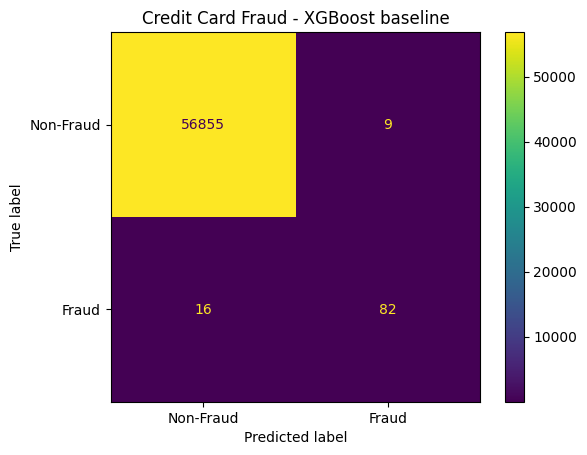

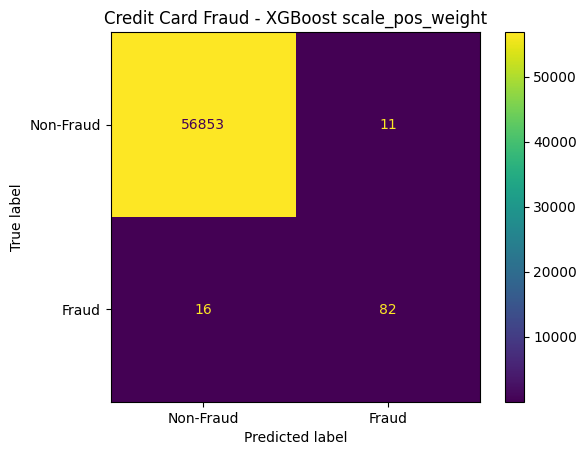

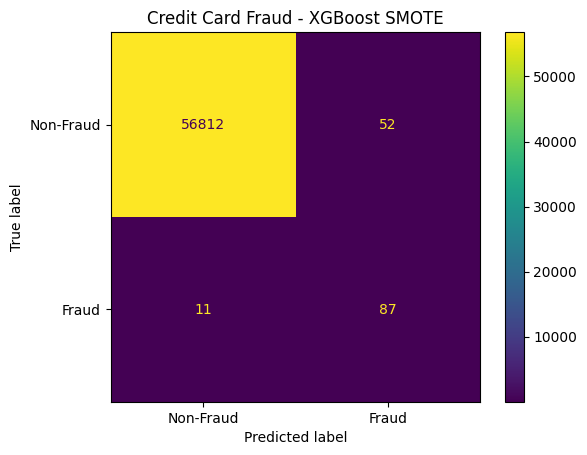

In [86]:
# Confusion matrices for the imbalance-handling experiments
for model_name, obj in credit_imbalance_models.items():
    cm = confusion_matrix(y_test_imb, obj["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
    disp.plot(values_format="d")
    plt.title(f"Credit Card Fraud - {model_name}")
    plt.show()


#### 1.11.5 Precision-recall curve comparison

The precision-recall curves use the predicted probabilities instead of only the 0.5 threshold. That will help show whether a model has useful ranking ability even when the default fraud cutoff is not ideal.

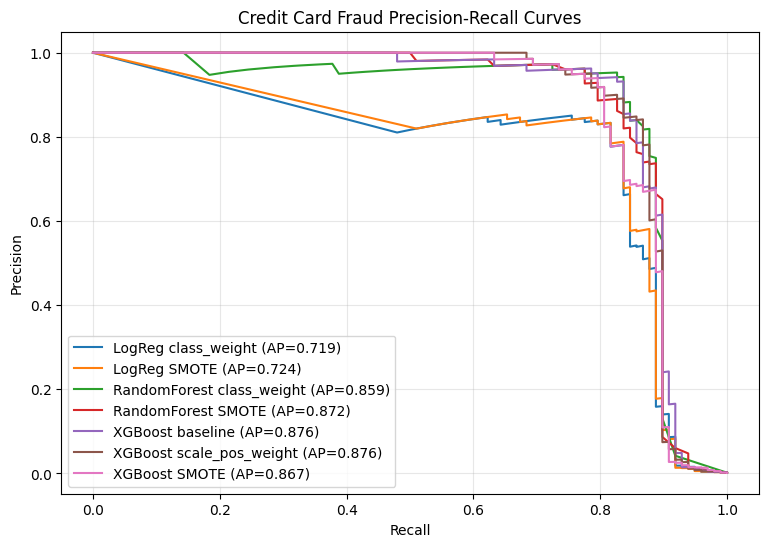

In [87]:
# Precision-recall curves for the imbalance-handling experiments
plt.figure(figsize=(9, 6))

for model_name, obj in credit_imbalance_models.items():
    y_prob = obj["y_prob"]
    if y_prob is None:
        continue

    precision, recall, _ = precision_recall_curve(y_test_imb, y_prob)
    pr_auc_value = average_precision_score(y_test_imb, y_prob)
    plt.plot(recall, precision, label=f"{model_name} (AP={pr_auc_value:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Credit Card Fraud Precision-Recall Curves")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()


#### 1.11.6 Imbalance-handling findings before refinement

At the default 0.5 threshold, XGBoost baseline gives the strongest balance before tuning. It catches 82 of the 98 fraud cases in the test set, misses 16, and only flags 9 normal transactions as fraud. Its F1-score and PR-AUC make it the strongest early candidate.

Logistic Regression with class weights and SMOTE catches many fraud cases, but the false-positive count is too high for a practical fraud detector. Those models are useful for showing the recall side of the trade-off, but they are not strong final candidates without heavy threshold control.

Random Forest with SMOTE and XGBoost with imbalance handling give more usable trade-offs. The stronger candidates going into refinement are therefore the XGBoost baseline family and the Random Forest SMOTE family, since they either keep precision high or reduce missed fraud without creating an extreme number of false alarms.


### 1.12 Credit Card Fraud Model Refinement and Hyperparameter Tuning

The imbalance experiments narrowed the model search. Logistic Regression is not tuned further here because its recall is high but the false-positive count is far too large. The stronger candidates are the models that either kept a good F1/PR-AUC balance or caught more fraud without completely losing precision.

Hyperparameter tuning is done before threshold tuning so the cutoff analysis is based on stronger model versions. The search uses average precision as the main scoring metric because the fraud class is rare and the probability ranking matters more than accuracy.

#### 1.12.1 Candidate models selected for tuning

The selected candidates come from the imbalance-handling results. XGBoost baseline is the main model to beat. XGBoost with `scale_pos_weight` tests whether weighting the rare fraud class improves the same model family. Random Forest with SMOTE is kept because it performed close to XGBoost while using a different learning approach. XGBoost with SMOTE is kept as the higher-recall candidate, even though its false-positive count is larger.


In [88]:
# Candidate models from the imbalance-handling experiment
refinement_candidates = [
    "XGBoost baseline",
    "XGBoost scale_pos_weight",
    "RandomForest SMOTE",
    "XGBoost SMOTE"
]

section11_candidate_results = credit_imbalance_results[
    credit_imbalance_results["model"].isin(refinement_candidates)
].copy()

section11_candidate_results = section11_candidate_results.sort_values(
    by=["f1", "pr_auc"],
    ascending=False
).reset_index(drop=True)

display(section11_candidate_results)


,model,training_rows_used,training_fraud_percent,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,predicted_fraud_count
0,XGBoost baseline,227845,0.1729,0.999561,0.901099,0.836735,0.867725,0.977750,0.876141,56855,9,16,82,91
1,XGBoost scale_pos_weight,227845,0.1729,0.999526,0.881720,0.836735,0.858639,0.975484,0.875963,56853,11,16,82,93
2,RandomForest SMOTE,454902,50.0000,0.999491,0.870968,0.826531,0.848168,0.975422,0.871804,56852,12,17,81,93
3,XGBoost SMOTE,454902,50.0000,0.998894,0.625899,0.887755,0.734177,0.979973,0.866763,56812,52,11,87,139


#### 1.12.2 Tuning setup

The search space is kept controlled instead of very large. A bigger search would train many more model versions, but the earlier results already narrowed the useful candidates. The main check here is whether moderate tuning improves the strongest models or only shifts the same precision-recall trade-off.

Average precision is used as the search score because the fraud class is rare. A model that ranks fraud cases well across thresholds is more useful than a model that only looks good at one default cutoff.


In [89]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Smaller tuning setup so the section does not take too long
XGB_TUNING_ITERATIONS = 10
SMOTE_TUNING_ITERATIONS = 5
TUNING_CV_SPLITS = 3

cv_strategy = StratifiedKFold(
    n_splits=TUNING_CV_SPLITS,
    shuffle=True,
    random_state=42
)

tuning_score = "average_precision"

#### 1.12.3 Evaluation helper

The helper function keeps the tuned-model tables consistent with the earlier model comparison. It records the usual classification metrics, the PR-AUC score, and the number of false positives and false negatives.

In [90]:
def evaluate_model_result(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    tn = ((y_test == 0) & (y_pred == 0)).sum()
    fp = ((y_test == 0) & (y_pred == 1)).sum()
    fn = ((y_test == 1) & (y_pred == 0)).sum()
    tp = ((y_test == 1) & (y_pred == 1)).sum()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
        "False Positives": fp,
        "False Negatives": fn,
        "Predicted Fraud Count": int(y_pred.sum())
    }

#### 1.12.4 XGBoost tuning searches

The XGBoost searches test tree depth, learning rate, number of trees, sampling settings, and regularization. One version keeps the normal class weighting, while the weighted version searches around the imbalance ratio through `scale_pos_weight`.


In [91]:
# Calculate imbalance ratio for XGBoost scale_pos_weight
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Non-fraud count:", negative_count)
print("Fraud count:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

# XGBoost hyperparameter search spaces
xgb_param_dist = {
    "n_estimators": [100, 150, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_lambda": [1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5]
}

xgb_tuning_candidates = {
    "XGBoost baseline tuned": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost scale_pos_weight tuned": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )
}

Non-fraud count: 227451
Fraud count: 394
scale_pos_weight: 577.2868020304569


#### 1.12.5 Run the tuning search

In [92]:
tuned_xgb_models = {}
xgb_tuning_rows = []

for model_name, model in xgb_tuning_candidates.items():
    print(f"\nTuning: {model_name}")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=xgb_param_dist,
        n_iter=XGB_TUNING_ITERATIONS,
        scoring=tuning_score,
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        verbose=2
    )

    search.fit(X_train, y_train)

    tuned_xgb_models[model_name] = search.best_estimator_

    result = evaluate_model_result(
        model_name,
        search.best_estimator_,
        X_test,
        y_test
    )

    result["Best CV PR-AUC"] = search.best_score_
    xgb_tuning_rows.append(result)

xgb_tuning_results = pd.DataFrame(xgb_tuning_rows)
xgb_tuning_results.sort_values("PR-AUC", ascending=False)


Tuning: XGBoost baseline tuned
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Tuning: XGBoost scale_pos_weight tuned
Fitting 3 folds for each of 10 candidates, totalling 30 fits


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,False Positives,False Negatives,Predicted Fraud Count,Best CV PR-AUC
0,XGBoost baseline tuned,0.999579,0.920455,0.826531,0.870968,0.978786,0.871707,7,17,88,0.847738
1,XGBoost scale_pos_weight tuned,0.999368,0.792453,0.857143,0.823529,0.983998,0.867933,22,14,106,0.841849


#### 1.12.6 XGBoost best parameters

In [93]:
xgb_best_params = []

for model_name, model in tuned_xgb_models.items():
    xgb_best_params.append({
        "Model": model_name,
        "Best Parameters": model.get_params()
    })

pd.DataFrame(xgb_best_params)

,Model,Best Parameters
0,XGBoost baseline tuned,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, ..."
1,XGBoost scale_pos_weight tuned,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, ..."


#### 1.12.7 SMOTE model tuning searches

The SMOTE searches keep resampling inside the training pipeline. Scaling is applied before SMOTE because synthetic examples are created using nearest-neighbour distances. The test set is still left in its original imbalanced form.


In [94]:
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42,
    k_neighbors=5
)

rf_smote_pipeline = ImbPipeline([
    ("smote", smote),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

xgb_smote_pipeline = ImbPipeline([
    ("smote", smote),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

rf_smote_param_dist = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

xgb_smote_param_dist = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3],
    "model__reg_lambda": [1, 2, 5]
}

smote_tuning_candidates = {
    "Random Forest SMOTE tuned": {
        "pipeline": rf_smote_pipeline,
        "params": rf_smote_param_dist
    },
    "XGBoost SMOTE tuned": {
        "pipeline": xgb_smote_pipeline,
        "params": xgb_smote_param_dist
    }
}

#### 1.12.8 Run the tuning search

In [95]:
tuned_smote_models = {}
smote_tuning_rows = []

for model_name, setup in smote_tuning_candidates.items():
    print(f"\nTuning: {model_name}")

    search = RandomizedSearchCV(
        estimator=setup["pipeline"],
        param_distributions=setup["params"],
        n_iter=SMOTE_TUNING_ITERATIONS,
        scoring=tuning_score,
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        verbose=2
    )

    search.fit(X_train, y_train)

    tuned_smote_models[model_name] = search.best_estimator_

    result = evaluate_model_result(
        model_name,
        search.best_estimator_,
        X_test,
        y_test
    )

    result["Best CV PR-AUC"] = search.best_score_
    smote_tuning_rows.append(result)

smote_tuning_results = pd.DataFrame(smote_tuning_rows)
smote_tuning_results.sort_values("PR-AUC", ascending=False)


Tuning: Random Forest SMOTE tuned
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Tuning: XGBoost SMOTE tuned
Fitting 3 folds for each of 5 candidates, totalling 15 fits


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,False Positives,False Negatives,Predicted Fraud Count,Best CV PR-AUC
0,Random Forest SMOTE tuned,0.999473,0.826923,0.877551,0.851485,0.980466,0.874774,18,12,104,0.851433
1,XGBoost SMOTE tuned,0.998648,0.569536,0.877551,0.690763,0.977351,0.843216,65,12,151,0.805530


#### 1.12.9 Combined tuned-model results

In [96]:
all_tuned_results = pd.concat(
    [xgb_tuning_results, smote_tuning_results],
    ignore_index=True
)

all_tuned_results.sort_values("PR-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,False Positives,False Negatives,Predicted Fraud Count,Best CV PR-AUC
2,Random Forest SMOTE tuned,0.999473,0.826923,0.877551,0.851485,0.980466,0.874774,18,12,104,0.851433
0,XGBoost baseline tuned,0.999579,0.920455,0.826531,0.870968,0.978786,0.871707,7,17,88,0.847738
1,XGBoost scale_pos_weight tuned,0.999368,0.792453,0.857143,0.823529,0.983998,0.867933,22,14,106,0.841849
3,XGBoost SMOTE tuned,0.998648,0.569536,0.877551,0.690763,0.977351,0.843216,65,12,151,0.805530


#### 1.12.10 Best tuned models by metric

In [97]:
best_tuned_by_prauc = all_tuned_results.sort_values("PR-AUC", ascending=False).iloc[0]
best_tuned_by_f1 = all_tuned_results.sort_values("F1", ascending=False).iloc[0]
best_tuned_by_recall = all_tuned_results.sort_values("Recall", ascending=False).iloc[0]

print("Best by PR-AUC:")
print(best_tuned_by_prauc[["Model", "PR-AUC", "Precision", "Recall", "F1", "False Positives", "False Negatives"]])

print("\nBest by F1:")
print(best_tuned_by_f1[["Model", "PR-AUC", "Precision", "Recall", "F1", "False Positives", "False Negatives"]])

print("\nBest by Recall:")
print(best_tuned_by_recall[["Model", "PR-AUC", "Precision", "Recall", "F1", "False Positives", "False Negatives"]])

Best by PR-AUC:
Model              Random Forest SMOTE tuned
PR-AUC                              0.874774
Precision                           0.826923
Recall                              0.877551
F1                                  0.851485
False Positives                           18
False Negatives                           12
Name: 2, dtype: object

Best by F1:
Model              XGBoost baseline tuned
PR-AUC                           0.871707
Precision                        0.920455
Recall                           0.826531
F1                               0.870968
False Positives                         7
False Negatives                        17
Name: 0, dtype: object

Best by Recall:
Model              XGBoost SMOTE tuned
PR-AUC                        0.843216
Precision                     0.569536
Recall                        0.877551
F1                            0.690763
False Positives                     65
False Negatives                     12
Name: 3, dtype: object


#### 1.12.11 Tuned parameter review

The tuned parameter dictionaries are kept in separate tables because they are too large for the main metric comparison. The metric tables matter more for the analysis than listing every setting inside the model object.


In [98]:
# Store tuned models in one dictionary for later comparison
credit_refinement_models = {}

for model_name, model in tuned_xgb_models.items():
    credit_refinement_models[model_name] = model

for model_name, model in tuned_smote_models.items():
    credit_refinement_models[model_name] = model

# Display a smaller parameter summary instead of the full estimator dictionaries
param_summary_rows = []

for model_name, model in credit_refinement_models.items():
    params = model.get_params()
    row = {"Model": model_name}

    for key in [
        "n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree",
        "min_child_weight", "gamma", "reg_lambda", "reg_alpha",
        "model__n_estimators", "model__max_depth", "model__min_samples_split",
        "model__min_samples_leaf", "model__max_features", "model__learning_rate"
    ]:
        if key in params:
            row[key] = params[key]

    param_summary_rows.append(row)

credit_refinement_param_summary = pd.DataFrame(param_summary_rows)
display(credit_refinement_param_summary)


,Model,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_lambda,reg_alpha,model__n_estimators,model__max_depth,model__min_samples_split,model__min_samples_leaf,model__max_features,model__learning_rate
0,XGBoost baseline tuned,300.0,5.0,0.05,1.0,1.0,1.0,0.1,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,XGBoost scale_pos_weight tuned,300.0,4.0,0.10,1.0,0.8,3.0,0.1,5.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN
2,Random Forest SMOTE tuned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,16.0,2.0,1.0,log2,NaN
3,XGBoost SMOTE tuned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,4.0,NaN,NaN,NaN,0.03


#### 1.12.12 Train-test gap check

The train-test comparison checks whether tuning made the models too fitted to the training data. A large gap does not make the model useless, but it does warn against making the models more complex just to chase higher training scores.


In [99]:
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

def check_train_test_gap(model_name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Train PR-AUC": average_precision_score(y_train, train_proba),
        "Test PR-AUC": average_precision_score(y_test, test_proba),
        "Train F1": f1_score(y_train, train_pred, zero_division=0),
        "Test F1": f1_score(y_test, test_pred, zero_division=0),
        "Train Precision": precision_score(y_train, train_pred, zero_division=0),
        "Test Precision": precision_score(y_test, test_pred, zero_division=0),
        "Train Recall": recall_score(y_train, train_pred, zero_division=0),
        "Test Recall": recall_score(y_test, test_pred, zero_division=0),
    }

# Only the two strongest tuned candidates are checked here.
overfit_checks = []

overfit_checks.append(
    check_train_test_gap(
        "XGBoost baseline tuned",
        tuned_xgb_models["XGBoost baseline tuned"],
        X_train,
        y_train,
        X_test,
        y_test
    )
)

overfit_checks.append(
    check_train_test_gap(
        "Random Forest SMOTE tuned",
        tuned_smote_models["Random Forest SMOTE tuned"],
        X_train,
        y_train,
        X_test,
        y_test
    )
)

credit_overfit_check = pd.DataFrame(overfit_checks)
display(credit_overfit_check)


,Model,Train PR-AUC,Test PR-AUC,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall
0,XGBoost baseline tuned,0.999791,0.871707,0.988447,0.870968,1.000000,0.920455,0.977157,0.826531
1,Random Forest SMOTE tuned,0.997483,0.874774,0.978065,0.851485,0.994751,0.826923,0.961929,0.877551


#### 1.12.13 Hyperparameter-tuning results before recall-focused refinement

The tuning results do not give one model that wins every metric. Since missed fraud is the more serious error, the false-negative count is treated as a main decision point rather than a small detail beside F1-score.

The tuned XGBoost baseline gives the cleanest prediction behaviour. It has strong precision and only a small number of false positives, but it still misses 17 fraud cases. Random Forest with SMOTE catches more fraud cases and lowers missed fraud to 12, although it accepts more false positives.

XGBoost with `scale_pos_weight` improves attention toward the fraud class, but it does not clearly beat the two strongest candidates. XGBoost with SMOTE catches fraud well but creates too many false positives compared with Random Forest SMOTE. The next refinement therefore focuses on whether recall can be improved directly without letting false positives grow too much.


### 1.13 Credit Card Fraud Recall-Focused Refinement

The previous tuning used average precision, which is a good ranking metric for imbalanced data. The fraud detection goal also needs a more direct check on missed fraud. A model with a slightly lower F1-score may still be useful if it reduces false negatives without creating an unreasonable number of false positives.

The refinement below tests a small recall-focused search. The score used here is F2, which gives recall more weight than precision. That makes the tuning stage more sensitive to missed fraud than the earlier PR-AUC search.

In [100]:
from sklearn.metrics import make_scorer, fbeta_score

# F2 gives recall more weight than precision.
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

RECALL_XGB_TUNING_ITERATIONS = 8
RECALL_SMOTE_TUNING_ITERATIONS = 4

print("Recall-focused scorer: F2")
print("XGBoost recall tuning iterations:", RECALL_XGB_TUNING_ITERATIONS)
print("SMOTE recall tuning iterations:", RECALL_SMOTE_TUNING_ITERATIONS)


Recall-focused scorer: F2
XGBoost recall tuning iterations: 8
SMOTE recall tuning iterations: 4


#### 1.13.1 Recall-focused evaluation helper

The helper below keeps the same metrics as the previous tuning tables, but adds F2 and the confusion-matrix counts. The false-negative count is kept near the main metrics because missed fraud is the main error being reduced in this refinement.

In [101]:
def evaluate_recall_model_result(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "F2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Predicted Fraud Count": int(y_pred.sum())
    }


#### 1.13.2 Recall-focused XGBoost search

The XGBoost search keeps the model controlled while testing stronger fraud weighting. The `scale_pos_weight` values move around the normal imbalance ratio instead of only using one fixed value. Larger values usually push the model toward catching more fraud, but they can also raise the false-positive count.

In [102]:
# Recall-focused XGBoost tuning
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

xgb_recall_param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_lambda": [1, 2, 5],
    "reg_alpha": [0, 0.1],
    "scale_pos_weight": [
        scale_pos_weight * 0.75,
        scale_pos_weight,
        scale_pos_weight * 1.25,
        scale_pos_weight * 1.5,
        scale_pos_weight * 2.0
    ]
}

xgb_recall_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=xgb_recall_param_dist,
    n_iter=RECALL_XGB_TUNING_ITERATIONS,
    scoring=f2_scorer,
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_recall_search.fit(X_train, y_train)

credit_recall_refinement_models = {
    "XGBoost recall-focused tuned": xgb_recall_search.best_estimator_
}

xgb_recall_result = evaluate_recall_model_result(
    "XGBoost recall-focused tuned",
    xgb_recall_search.best_estimator_,
    X_test,
    y_test
)

xgb_recall_result["Best CV F2"] = xgb_recall_search.best_score_

display(pd.DataFrame([xgb_recall_result]))
print("Best XGBoost recall-focused parameters:")
print(xgb_recall_search.best_params_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


,Model,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,False Positives,False Negatives,True Positives,Predicted Fraud Count,Best CV F2
0,XGBoost recall-focused tuned,0.996471,0.311355,0.867347,0.458221,0.639098,0.979323,0.792772,188,13,85,273,0.718093


Best XGBoost recall-focused parameters:
{'subsample': 0.9, 'scale_pos_weight': np.float64(865.9302030456854), 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


#### 1.13.3 Recall-focused SMOTE searches

The SMOTE searches test whether giving the model more synthetic fraud examples can reduce missed fraud. The sampling ratios are still limited. Full balancing may catch more fraud, but it can also push the model into flagging too many normal transactions.

In [103]:
# Recall-focused SMOTE tuning
rf_recall_smote_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=5)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

xgb_recall_smote_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=5)),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

rf_recall_smote_param_dist = {
    "smote__sampling_strategy": [0.1, 0.2, 0.3],
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

xgb_recall_smote_param_dist = {
    "smote__sampling_strategy": [0.1, 0.2, 0.3],
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3],
    "model__reg_lambda": [1, 2, 5]
}

recall_smote_candidates = {
    "Random Forest SMOTE recall-focused tuned": {
        "pipeline": rf_recall_smote_pipeline,
        "params": rf_recall_smote_param_dist
    },
    "XGBoost SMOTE recall-focused tuned": {
        "pipeline": xgb_recall_smote_pipeline,
        "params": xgb_recall_smote_param_dist
    }
}

recall_smote_rows = []
recall_smote_searches = {}

for model_name, setup in recall_smote_candidates.items():
    print(f"\nTuning: {model_name}")

    search = RandomizedSearchCV(
        estimator=setup["pipeline"],
        param_distributions=setup["params"],
        n_iter=RECALL_SMOTE_TUNING_ITERATIONS,
        scoring=f2_scorer,
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        verbose=2
    )

    search.fit(X_train, y_train)

    recall_smote_searches[model_name] = search
    credit_recall_refinement_models[model_name] = search.best_estimator_

    result = evaluate_recall_model_result(
        model_name,
        search.best_estimator_,
        X_test,
        y_test
    )
    result["Best CV F2"] = search.best_score_
    recall_smote_rows.append(result)

recall_smote_results = pd.DataFrame(recall_smote_rows)
display(recall_smote_results.sort_values(["False Negatives", "F2"], ascending=[True, False]))



Tuning: Random Forest SMOTE recall-focused tuned
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Tuning: XGBoost SMOTE recall-focused tuned
Fitting 3 folds for each of 4 candidates, totalling 12 fits


,Model,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,False Positives,False Negatives,True Positives,Predicted Fraud Count,Best CV F2
0,Random Forest SMOTE recall-focused tuned,0.999491,0.834951,0.877551,0.855721,0.868687,0.975050,0.879784,17,12,86,103,0.827196
1,XGBoost SMOTE recall-focused tuned,0.998929,0.639098,0.867347,0.735931,0.809524,0.980098,0.857958,48,13,85,133,0.817973


#### 1.13.4 Recall-focused model comparison

The table below compares the earlier tuned candidates with the new recall-focused models. The main check is whether the extra recall work actually reduces false negatives, and whether the false-positive increase stays reasonable.

In [104]:
# Compare earlier tuned models with recall-focused models
reference_model_objects = {
    "XGBoost baseline tuned": tuned_xgb_models["XGBoost baseline tuned"],
    "Random Forest SMOTE tuned": tuned_smote_models["Random Forest SMOTE tuned"],
    "XGBoost scale_pos_weight tuned": tuned_xgb_models["XGBoost scale_pos_weight tuned"]
}

recall_comparison_rows = []

for model_name, model in reference_model_objects.items():
    recall_comparison_rows.append(
        evaluate_recall_model_result(model_name, model, X_test, y_test)
    )

for model_name, model in credit_recall_refinement_models.items():
    recall_comparison_rows.append(
        evaluate_recall_model_result(model_name, model, X_test, y_test)
    )

credit_recall_comparison = pd.DataFrame(recall_comparison_rows)

credit_recall_comparison = credit_recall_comparison.sort_values(
    by=["False Negatives", "F2", "PR-AUC"],
    ascending=[True, False, False]
).reset_index(drop=True)

display(credit_recall_comparison)


,Model,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,False Positives,False Negatives,True Positives,Predicted Fraud Count
0,Random Forest SMOTE recall-focused tuned,0.999491,0.834951,0.877551,0.855721,0.868687,0.975050,0.879784,17,12,86,103
1,Random Forest SMOTE tuned,0.999473,0.826923,0.877551,0.851485,0.866935,0.980466,0.874774,18,12,86,104
2,XGBoost SMOTE recall-focused tuned,0.998929,0.639098,0.867347,0.735931,0.809524,0.980098,0.857958,48,13,85,133
3,XGBoost recall-focused tuned,0.996471,0.311355,0.867347,0.458221,0.639098,0.979323,0.792772,188,13,85,273
4,XGBoost scale_pos_weight tuned,0.999368,0.792453,0.857143,0.823529,0.843373,0.983998,0.867933,22,14,84,106
5,XGBoost baseline tuned,0.999579,0.920455,0.826531,0.870968,0.843750,0.978786,0.871707,7,17,81,88


In [105]:
def check_train_test_gap_with_f2(model_name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Train PR-AUC": average_precision_score(y_train, train_proba),
        "Test PR-AUC": average_precision_score(y_test, test_proba),
        "Train F1": f1_score(y_train, train_pred, zero_division=0),
        "Test F1": f1_score(y_test, test_pred, zero_division=0),
        "Train F2": fbeta_score(y_train, train_pred, beta=2, zero_division=0),
        "Test F2": fbeta_score(y_test, test_pred, beta=2, zero_division=0),
        "Train Precision": precision_score(y_train, train_pred, zero_division=0),
        "Test Precision": precision_score(y_test, test_pred, zero_division=0),
        "Train Recall": recall_score(y_train, train_pred, zero_division=0),
        "Test Recall": recall_score(y_test, test_pred, zero_division=0),
    }

recall_overfit_rows = []

# Retest the strongest previous candidates and the recall-focused candidates.
models_for_recall_overfit_check = {}
models_for_recall_overfit_check.update(reference_model_objects)
models_for_recall_overfit_check.update(credit_recall_refinement_models)

for model_name, model in models_for_recall_overfit_check.items():
    recall_overfit_rows.append(
        check_train_test_gap_with_f2(
            model_name,
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )
    )

credit_recall_overfit_check = pd.DataFrame(recall_overfit_rows)
display(credit_recall_overfit_check)


,Model,Train PR-AUC,Test PR-AUC,Train F1,Test F1,Train F2,Test F2,Train Precision,Test Precision,Train Recall,Test Recall
0,XGBoost baseline tuned,0.999791,0.871707,0.988447,0.870968,0.981642,0.843750,1.000000,0.920455,0.977157,0.826531
1,Random Forest SMOTE tuned,0.997483,0.874774,0.978065,0.851485,0.968319,0.866935,0.994751,0.826923,0.961929,0.877551
2,XGBoost scale_pos_weight tuned,0.996655,0.867933,0.943713,0.823529,0.976698,0.843373,0.893424,0.792453,1.000000,0.857143
3,XGBoost recall-focused tuned,0.939086,0.792772,0.556497,0.458221,0.758276,0.639098,0.385519,0.311355,1.000000,0.867347
4,Random Forest SMOTE recall-focused tuned,0.994051,0.879784,0.950820,0.855721,0.954430,0.868687,0.944862,0.834951,0.956853,0.877551
5,XGBoost SMOTE recall-focused tuned,0.928003,0.857958,0.826790,0.735931,0.874023,0.809524,0.758475,0.639098,0.908629,0.867347


#### 1.13.6 Recall-focused refinement results

The recall-focused refinement makes Random Forest with SMOTE the strongest candidate before threshold tuning. The recall-focused Random Forest SMOTE model keeps missed fraud at 12 cases, improves precision slightly compared with the earlier Random Forest SMOTE version, and reduces false positives from 18 to 17. Its PR-AUC also reaches about 0.880, which is the strongest result in the recall-focused comparison.

The tuned XGBoost baseline remains the cleaner precision-focused model, with only 7 false positives. The problem is that it misses 17 fraud cases, so it is not the best fit when false negatives carry the larger penalty. XGBoost SMOTE recall-focused has a smaller train-test gap, but it creates 48 false positives and has much weaker precision. A smaller gap does not make that model better if the practical error trade-off is worse.

Based on the recall-focused results, Random Forest SMOTE recall-focused tuned is carried forward as the main fraud-detection candidate. The XGBoost baseline tuned model remains useful as the conservative comparison because it shows what is gained and lost when the model is made stricter.


### 1.14.1 Amount-Based Z Threshold Optimization

The final classifier produces a fraud probability. A threshold is then needed to turn that probability into a class decision:

\[
\hat{y}_i(t) =
\begin{cases}
1, & P(y_i = 1 \mid x_i) \geq t \\
0, & P(y_i = 1 \mid x_i) < t
\end{cases}
\]

The threshold is selected using the same amount-based rule used in the online-payment analysis:

\[
t^* = \arg\min_t \left[FP(t) + \hat{Z}FN(t)\right]
\]

subject to:

\[
FPR(t) \leq \alpha
\]

Here, \(\hat{Z}\) estimates how much worse a missed fraud case is than one false alarm. In this credit-card dataset, \(\hat{Z}\) is estimated from the fraud transaction amounts in the training data.


#### 1.14.2 Configuration and Z estimation

The credit-card data includes an `Amount` column. That allows the false-negative side of the problem to be tied to transaction size.

The estimated Z value is calculated from fraud amounts in the training data. The false-positive side still needs a unit cost because the dataset does not contain a real review or customer-friction cost. That value is kept as a single setting so the assumption stays visible.


In [106]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
except Exception as exc:
    raise ImportError(
        "SMOTE requires imbalanced-learn. Install a compatible imbalanced-learn/scikit-learn pair before running this section."
    ) from exc

# Shared optimization settings, matching the online-payment optimization structure.
MAX_FALSE_POSITIVE_RATE = 0.05
ASSUMED_FALSE_POSITIVE_COST = 10.0
Z_AMOUNT_STATISTIC = "mean"  # "mean" matches the online-payment version; "median" can be tested later.

amount_col = "Amount"
if amount_col not in credit_model_df.columns:
    raise KeyError("The credit-card modelling dataframe needs an Amount column for amount-based Z estimation.")

def calculate_z_from_amount(amount_data, y_data=None, assumed_false_positive_cost=10.0, positive_label=1, statistic="mean"):
    amounts = pd.Series(amount_data).astype(float).reset_index(drop=True)

    if y_data is not None:
        labels = pd.Series(y_data).reset_index(drop=True)
        fraud_amounts = amounts[labels == positive_label]
    else:
        fraud_amounts = amounts

    fraud_amounts = fraud_amounts.dropna()

    if len(fraud_amounts) == 0:
        raise ValueError("No fraud amounts were available to estimate Z.")

    if assumed_false_positive_cost <= 0:
        raise ValueError("assumed_false_positive_cost must be greater than 0.")

    if statistic == "mean":
        estimated_false_negative_cost = fraud_amounts.mean()
    elif statistic == "median":
        estimated_false_negative_cost = fraud_amounts.median()
    else:
        raise ValueError("statistic must be either 'mean' or 'median'.")

    estimated_z = estimated_false_negative_cost / assumed_false_positive_cost

    return {
        "estimated_z": float(estimated_z),
        "estimated_false_negative_cost": float(estimated_false_negative_cost),
        "assumed_false_positive_cost": float(assumed_false_positive_cost),
        "fraud_amount_count": int(len(fraud_amounts)),
        "statistic": statistic
    }

#### 1.14.3 Optimization helper functions

The helper functions calculate the classification metrics, false-positive rate, missed fraud amount, and amount-based Z score for each threshold. A threshold is counted as feasible only when its false-positive rate stays within the selected limit.


In [107]:
def predict_positive_score(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X_data)
        return (raw_scores - raw_scores.min()) / max(raw_scores.max() - raw_scores.min(), 1e-12)
    raise TypeError("The model must provide predict_proba or decision_function.")


def evaluate_at_threshold_amount_z(y_true, y_score, threshold, z, amount_values=None):
    y_true_arr = np.asarray(y_true).astype(int)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_arr, y_pred).ravel()
    fpr = fp / max(fp + tn, 1)
    cost_score = fp + (z * fn)

    if amount_values is not None:
        amount_arr = np.asarray(pd.Series(amount_values).astype(float))
        missed_amount = float(amount_arr[(y_true_arr == 1) & (y_pred == 0)].sum())
    else:
        missed_amount = np.nan

    precision = precision_score(y_true_arr, y_pred, zero_division=0)
    recall = recall_score(y_true_arr, y_pred, zero_division=0)
    f1 = f1_score(y_true_arr, y_pred, zero_division=0)
    f2 = fbeta_score(y_true_arr, y_pred, beta=2, zero_division=0)

    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(y_true_arr, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "F2": f2,
        "ROC-AUC": roc_auc_score(y_true_arr, y_score),
        "PR-AUC": average_precision_score(y_true_arr, y_score),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "True Positives": int(tp),
        "True Negatives": int(tn),
        "FPR": fpr,
        "Predicted Fraud Count": int(y_pred.sum()),
        "Amount Missed by FN": missed_amount,
        "Amount-Based Z Score": float(cost_score),
        "Feasible FPR": bool(fpr <= MAX_FALSE_POSITIVE_RATE)
    }


def optimize_threshold_amount_z(y_true, y_score, z, amount_values=None, max_fpr=0.05, threshold_values=None):
    if threshold_values is None:
        threshold_values = np.round(np.arange(0.01, 1.00, 0.01), 2)

    rows = []
    for threshold in threshold_values:
        row = evaluate_at_threshold_amount_z(
            y_true=y_true,
            y_score=y_score,
            threshold=threshold,
            z=z,
            amount_values=amount_values
        )
        rows.append(row)

    threshold_table = pd.DataFrame(rows)
    feasible_table = threshold_table[threshold_table["FPR"] <= max_fpr].copy()

    if len(feasible_table) > 0:
        best_row = (
            feasible_table
            .sort_values(
                by=["Amount-Based Z Score", "False Negatives", "False Positives", "F2"],
                ascending=[True, True, True, False]
            )
            .iloc[0]
            .to_dict()
        )
    else:
        best_row = (
            threshold_table
            .sort_values(
                by=["FPR", "Amount-Based Z Score", "False Negatives"],
                ascending=[True, True, True]
            )
            .iloc[0]
            .to_dict()
        )

    return best_row, threshold_table

#### 1.14.4 Train/validation/test split for amount-based optimization

The data is split into training, validation, and test parts. The training set fits the models. The validation set selects the threshold. The test set is kept separate for the final performance check.


In [108]:
# Rebuild the credit-card modelling data in case earlier cells were not rerun.
if "credit_model_df" not in globals():
    credit_target = credit_info["target"] if "credit_info" in globals() else "Class"
    v_features = [f"V{i}" for i in range(1, 29) if f"V{i}" in credit_df.columns]
    credit_base_feature_cols = ["Time"] + v_features + ["Amount"]
    credit_model_df = credit_df[credit_base_feature_cols + [credit_target]].copy()

X_amount = credit_model_df.drop(columns=[credit_target]).copy()
y_amount = credit_model_df[credit_target].copy()

X_train_amount_full, X_test_amount, y_train_amount_full, y_test_amount = train_test_split(
    X_amount,
    y_amount,
    test_size=0.20,
    random_state=42,
    stratify=y_amount
)

X_train_amount, X_valid_amount, y_train_amount, y_valid_amount = train_test_split(
    X_train_amount_full,
    y_train_amount_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_amount_full
)

z_estimation = calculate_z_from_amount(
    amount_data=X_train_amount[amount_col],
    y_data=y_train_amount,
    assumed_false_positive_cost=ASSUMED_FALSE_POSITIVE_COST,
    statistic=Z_AMOUNT_STATISTIC
)

ESTIMATED_Z = z_estimation["estimated_z"]

amount_optimization_split_summary = pd.DataFrame({
    "Dataset part": ["Training", "Validation", "Test"],
    "Rows": [len(y_train_amount), len(y_valid_amount), len(y_test_amount)],
    "Fraud count": [int((y_train_amount == 1).sum()), int((y_valid_amount == 1).sum()), int((y_test_amount == 1).sum())],
    "Fraud percent": [
        (y_train_amount == 1).mean() * 100,
        (y_valid_amount == 1).mean() * 100,
        (y_test_amount == 1).mean() * 100
    ]
})

z_estimation_table = pd.DataFrame([z_estimation])

display(amount_optimization_split_summary)
display(z_estimation_table)
print("Estimated Z used in threshold optimization:", ESTIMATED_Z)
print("Maximum allowed false-positive rate:", MAX_FALSE_POSITIVE_RATE)

,Dataset part,Rows,Fraud count,Fraud percent
0,Training,170883,295,0.172633
1,Validation,56962,99,0.173800
2,Test,56962,98,0.172045


,estimated_z,estimated_false_negative_cost,assumed_false_positive_cost,fraud_amount_count,statistic
0,13.014549,130.145492,10.0,295,mean


Estimated Z used in threshold optimization: 13.014549152542372
Maximum allowed false-positive rate: 0.05


#### 1.14.5 Candidate training and threshold search

The first search uses a bounded candidate set instead of a large tuning loop. The candidates include class weighting, limited SMOTE versions, and XGBoost variants. Each candidate is tested across thresholds on the validation set using the amount-based Z objective.


In [109]:
scale_pos_weight_amount = (y_train_amount == 0).sum() / max((y_train_amount == 1).sum(), 1)

amount_z_candidate_models = {
    "LogReg class_weight": SklearnPipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),

    "RandomForest class_weight controlled": RandomForestClassifier(
        n_estimators=150,
        max_depth=16,
        min_samples_leaf=2,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "RandomForest SMOTE 0.10": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.10, random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=16,
            min_samples_leaf=2,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "RandomForest SMOTE 0.20": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.20, random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=16,
            min_samples_leaf=2,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost baseline controlled": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost scale_pos_weight controlled": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight_amount,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost SMOTE 0.10": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.10, random_state=42)),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

coarse_threshold_values = np.round(np.arange(0.01, 1.00, 0.01), 2)

amount_z_models = {}
amount_z_validation_tables = {}
amount_z_rows = []

for model_name, model in amount_z_candidate_models.items():
    print("Training:", model_name)
    fitted_model = clone(model)
    fitted_model.fit(X_train_amount, y_train_amount)

    y_valid_score = predict_positive_score(fitted_model, X_valid_amount)

    best_row, threshold_table = optimize_threshold_amount_z(
        y_true=y_valid_amount,
        y_score=y_valid_score,
        z=ESTIMATED_Z,
        amount_values=X_valid_amount[amount_col],
        max_fpr=MAX_FALSE_POSITIVE_RATE,
        threshold_values=coarse_threshold_values
    )

    best_row["Model"] = model_name
    best_row["Estimated Z"] = ESTIMATED_Z
    best_row["Optimization Stage"] = "coarse threshold search"

    amount_z_models[model_name] = fitted_model
    amount_z_validation_tables[model_name] = threshold_table.assign(Model=model_name)
    amount_z_rows.append(best_row)

amount_z_validation_results = pd.DataFrame(amount_z_rows).sort_values(
    by=["Amount-Based Z Score", "False Negatives", "False Positives", "F2"],
    ascending=[True, True, True, False]
)

amount_z_validation_results[
    [
        "Model", "Threshold", "Precision", "Recall", "F1", "F2",
        "False Positives", "False Negatives", "FPR",
        "Amount Missed by FN", "Amount-Based Z Score", "Feasible FPR"
    ]
]

Training: LogReg class_weight
Training: RandomForest class_weight controlled
Training: RandomForest SMOTE 0.10
Training: RandomForest SMOTE 0.20
Training: XGBoost baseline controlled
Training: XGBoost scale_pos_weight controlled
Training: XGBoost SMOTE 0.10


,Model,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,FPR,Amount Missed by FN,Amount-Based Z Score,Feasible FPR
4,XGBoost baseline controlled,0.13,0.860215,0.808081,0.833333,0.817996,13,19,0.000229,3140.32,260.276434,True
1,RandomForest class_weight controlled,0.11,0.692308,0.818182,0.750000,0.789474,36,18,0.000633,3139.32,270.261885,True
3,RandomForest SMOTE 0.20,0.33,0.727273,0.808081,0.765550,0.790514,30,19,0.000528,2865.15,277.276434,True
2,RandomForest SMOTE 0.10,0.30,0.720721,0.808081,0.761905,0.788955,31,19,0.000545,2865.15,278.276434,True
5,XGBoost scale_pos_weight controlled,0.83,0.787879,0.787879,0.787879,0.787879,21,21,0.000369,3142.32,294.305532,True
6,XGBoost SMOTE 0.10,0.79,0.875000,0.777778,0.823529,0.795455,11,22,0.000193,3143.32,297.320081,True
0,LogReg class_weight,0.99,0.564286,0.797980,0.661088,0.736940,61,20,0.001073,3239.31,321.290983,True


#### 1.14.6 Setup for follow-up candidates

The next cell only prepares imports and checks that the amount column and imbalance ratio are available. It does not change the model results.


In [110]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import numpy as np
import pandas as pd

# Safety check for scale_pos_weight
if "scale_pos_weight_amount" not in globals():
    negative_count = (y_train_amount == 0).sum()
    positive_count = (y_train_amount == 1).sum()
    scale_pos_weight_amount = negative_count / positive_count

print("scale_pos_weight_amount:", scale_pos_weight_amount)

# Safety check for amount column name
if "amount_col" not in globals():
    amount_col = "Amount"

print("Amount column:", amount_col)

scale_pos_weight_amount: 578.264406779661
Amount column: Amount


In [111]:
# Small extra candidate check

extra_amount_candidate_models = {
    "XGBoost baseline regularized": XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=3,
        gamma=0.1,
        reg_lambda=2,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost baseline shallow": XGBClassifier(
        n_estimators=150,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=3,
        gamma=0.1,
        reg_lambda=2,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost scale_pos_weight regularized": XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=3,
        gamma=0.1,
        reg_lambda=2,
        scale_pos_weight=scale_pos_weight_amount,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "RandomForest SMOTE 0.10 regularized": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.10, random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=4,
            min_samples_split=8,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "RandomForest SMOTE 0.20 regularized": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.20, random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=4,
            min_samples_split=8,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

extra_amount_rows = []

for model_name, model in extra_amount_candidate_models.items():
    print(f"Training extra candidate: {model_name}")

    fitted_model = clone(model)
    fitted_model.fit(X_train_amount, y_train_amount)

    y_valid_score = predict_positive_score(fitted_model, X_valid_amount)

    best_row, threshold_table = optimize_threshold_amount_z(
        y_true=y_valid_amount,
        y_score=y_valid_score,
        z=ESTIMATED_Z,
        amount_values=X_valid_amount[amount_col],
        max_fpr=MAX_FALSE_POSITIVE_RATE
    )

    best_row["Model"] = model_name
    best_row["Estimated Z"] = ESTIMATED_Z

    amount_z_models[model_name] = fitted_model
    extra_amount_rows.append(best_row)

extra_amount_z_validation_results = pd.DataFrame(extra_amount_rows)

amount_z_all_validation_results = pd.concat(
    [amount_z_validation_results, extra_amount_z_validation_results],
    ignore_index=True
).sort_values(
    by=["Amount-Based Z Score", "False Negatives", "False Positives", "F2"],
    ascending=[True, True, True, False]
)

amount_z_all_validation_results[
    [
        "Model", "Threshold", "Precision", "Recall", "F1", "F2",
        "False Positives", "False Negatives", "FPR",
        "Amount Missed by FN", "Amount-Based Z Score", "Feasible FPR"
    ]
]

Training extra candidate: XGBoost baseline regularized
Training extra candidate: XGBoost baseline shallow
Training extra candidate: XGBoost scale_pos_weight regularized
Training extra candidate: RandomForest SMOTE 0.10 regularized
Training extra candidate: RandomForest SMOTE 0.20 regularized


,Model,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,FPR,Amount Missed by FN,Amount-Based Z Score,Feasible FPR
7,XGBoost baseline regularized,0.21,0.870968,0.818182,0.843750,0.828221,12,18,0.000211,3139.32,246.261885,True
0,XGBoost baseline controlled,0.13,0.860215,0.808081,0.833333,0.817996,13,19,0.000229,3140.32,260.276434,True
8,XGBoost baseline shallow,0.18,0.842105,0.808081,0.824742,0.814664,15,19,0.000264,3139.32,262.276434,True
11,RandomForest SMOTE 0.20 regularized,0.40,0.710526,0.818182,0.760563,0.794118,33,18,0.000580,2864.15,267.261885,True
1,RandomForest class_weight controlled,0.11,0.692308,0.818182,0.750000,0.789474,36,18,0.000633,3139.32,270.261885,True
10,RandomForest SMOTE 0.10 regularized,0.30,0.692308,0.818182,0.750000,0.789474,36,18,0.000633,3139.32,270.261885,True
2,RandomForest SMOTE 0.20,0.33,0.727273,0.808081,0.765550,0.790514,30,19,0.000528,2865.15,277.276434,True
3,RandomForest SMOTE 0.10,0.30,0.720721,0.808081,0.761905,0.788955,31,19,0.000545,2865.15,278.276434,True
9,XGBoost scale_pos_weight regularized,0.85,0.586957,0.818182,0.683544,0.758427,57,18,0.001002,3139.56,291.261885,True
4,XGBoost scale_pos_weight controlled,0.83,0.787879,0.787879,0.787879,0.787879,21,21,0.000369,3142.32,294.305532,True


The extra candidate check changes the best validation model. `XGBoost baseline regularized` gives the lowest amount-based Z score in the validation table.

At threshold `0.21`, it reaches recall of about `0.818`, precision of about `0.871`, with `18` false negatives and `12` false positives. The amount missed by false negatives is about `3139.32`, and the amount-based Z score is about `246.26`.

The result is better than the earlier XGBoost baseline controlled version. The improvement is not from a bigger model. It comes from a more controlled XGBoost setup with shallower depth, slower learning, and stronger regularization.


#### 1.14.8 Local threshold refinement

After the best validation model is chosen, the threshold is checked again around the selected cutoff. The search uses smaller step sizes so the selected threshold is not limited to the first coarse grid.


In [112]:
# Select the best validation model after the first run and extra bounded check.
best_amount_validation_row = amount_z_all_validation_results.iloc[0].copy()

best_amount_model_name = best_amount_validation_row["Model"]
best_amount_model = amount_z_models[best_amount_model_name]
best_coarse_threshold = float(best_amount_validation_row["Threshold"])

print("Best validation model:", best_amount_model_name)
print("Best coarse threshold:", best_coarse_threshold)

y_valid_score_best = predict_positive_score(best_amount_model, X_valid_amount)

# Small iterative threshold refinement around the current best threshold.
# This checks nearby values without doing a huge search.
refinement_steps = [0.01, 0.002, 0.0005]
current_threshold = best_coarse_threshold
refinement_history = []

for step in refinement_steps:
    low = max(0.001, current_threshold - (10 * step))
    high = min(0.999, current_threshold + (10 * step))

    threshold_values = np.round(
        np.arange(low, high + step, step),
        6
    )

    best_row, threshold_table = optimize_threshold_amount_z(
        y_true=y_valid_amount,
        y_score=y_valid_score_best,
        z=ESTIMATED_Z,
        amount_values=X_valid_amount[amount_col],
        max_fpr=MAX_FALSE_POSITIVE_RATE,
        threshold_values=threshold_values
    )

    best_row["Model"] = best_amount_model_name
    best_row["Step Size"] = step

    refinement_history.append(best_row)
    current_threshold = float(best_row["Threshold"])

amount_z_refinement_history = pd.DataFrame(refinement_history)

best_fine_row = amount_z_refinement_history.sort_values(
    by=["Amount-Based Z Score", "False Negatives", "False Positives", "F2"],
    ascending=[True, True, True, False]
).iloc[0].copy()

best_fine_row["Model"] = best_amount_model_name
best_fine_row["Estimated Z"] = ESTIMATED_Z

amount_z_selected_validation = pd.DataFrame([best_fine_row])

display(amount_z_refinement_history[
    [
        "Model", "Step Size", "Threshold", "Precision", "Recall", "F1", "F2",
        "False Positives", "False Negatives", "FPR",
        "Amount Missed by FN", "Amount-Based Z Score", "Feasible FPR"
    ]
])

display(amount_z_selected_validation[
    [
        "Model", "Threshold", "Precision", "Recall", "F1", "F2",
        "False Positives", "False Negatives", "FPR",
        "Amount Missed by FN", "Amount-Based Z Score", "Feasible FPR"
    ]
])

Best validation model: XGBoost baseline regularized
Best coarse threshold: 0.21


,Model,Step Size,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,FPR,Amount Missed by FN,Amount-Based Z Score,Feasible FPR
0,XGBoost baseline regularized,0.0100,0.210,0.870968,0.818182,0.84375,0.828221,12,18,0.000211,3139.32,246.261885,True
1,XGBoost baseline regularized,0.0020,0.208,0.870968,0.818182,0.84375,0.828221,12,18,0.000211,3139.32,246.261885,True
2,XGBoost baseline regularized,0.0005,0.208,0.870968,0.818182,0.84375,0.828221,12,18,0.000211,3139.32,246.261885,True


,Model,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,FPR,Amount Missed by FN,Amount-Based Z Score,Feasible FPR
0,XGBoost baseline regularized,0.21,0.870968,0.818182,0.84375,0.828221,12,18,0.000211,3139.32,246.261885,True


The local threshold refinement does not improve on the coarse result. Thresholds around `0.208` and `0.21` give the same validation performance: `12` false positives, `18` false negatives, and an amount-based Z score of about `246.26`.

The selected validation threshold therefore stays at `0.21`. The result is stable within the small range tested around the cutoff.


### 1.15 Final Test Evaluation Under Amount-Based Z

The selected model and threshold are now evaluated on the held-out test set. The test set is not used to choose the threshold. It is only used to check how the validation choice performs on unseen rows.

#### 1.15.1 Test-set evaluation of the selected model


In [113]:
# Final test evaluation


final_amount_model_name = best_amount_model_name
final_amount_model = best_amount_model
final_amount_threshold = float(best_fine_row["Threshold"])

y_test_amount_score = predict_positive_score(final_amount_model, X_test_amount)

final_amount_test_metrics = evaluate_at_threshold_amount_z(
    y_true=y_test_amount,
    y_score=y_test_amount_score,
    threshold=final_amount_threshold,
    z=ESTIMATED_Z,
    amount_values=X_test_amount[amount_col]
)

final_amount_test_results = pd.DataFrame([{
    "Model": final_amount_model_name,
    "Threshold": final_amount_threshold,
    "Estimated Z": ESTIMATED_Z,
    **final_amount_test_metrics
}])

final_amount_test_results[
    [
        "Model", "Threshold", "Precision", "Recall", "F1", "F2",
        "ROC-AUC", "PR-AUC",
        "False Positives", "False Negatives", "FPR",
        "Amount Missed by FN", "Amount-Based Z Score", "Feasible FPR"
    ]
]

,Model,Threshold,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,False Positives,False Negatives,FPR,Amount Missed by FN,Amount-Based Z Score,Feasible FPR
0,XGBoost baseline regularized,0.21,0.821782,0.846939,0.834171,0.841785,0.96924,0.867066,18,15,0.000317,1832.72,213.218237,True


On the test set, the selected model is `XGBoost baseline regularized` with threshold `0.21`. It reaches recall of about `0.847` and precision of about `0.822`.

The model misses `15` fraud cases and flags `18` normal transactions as fraud. The false-positive rate is very low at about `0.000317`, so the selected threshold remains feasible under the FPR constraint. The missed fraud amount is `1832.72`, and the amount-based Z score is about `213.22`.

The validation choice holds reasonably well on the test set. Precision drops slightly compared with validation, but recall improves, and the amount-based score remains lower than the validation score.


#### 1.15.2 Realized missed-fraud amount

The table below keeps the final missed-fraud amount separate from the other metrics. That makes the cost side easier to read directly.


In [114]:
# Realized missed fraud amount on the test set

y_test_amount_pred = (y_test_amount_score >= final_amount_threshold).astype(int)

test_fn_mask = (np.asarray(y_test_amount) == 1) & (y_test_amount_pred == 0)
test_fp_mask = (np.asarray(y_test_amount) == 0) & (y_test_amount_pred == 1)

total_missed_fraud_amount = float(X_test_amount.loc[test_fn_mask, amount_col].sum())
false_positive_count = int(test_fp_mask.sum())
false_negative_count = int(test_fn_mask.sum())

realized_amount_cost_summary = pd.DataFrame([{
    "Model": final_amount_model_name,
    "Threshold": final_amount_threshold,
    "False Negatives": false_negative_count,
    "False Positives": false_positive_count,
    "Total Missed Fraud Amount": total_missed_fraud_amount,
    "Estimated Z Used": ESTIMATED_Z,
    "Amount-Based Z Score": final_amount_test_metrics["Amount-Based Z Score"],
    "FPR": final_amount_test_metrics["FPR"],
    "Feasible FPR": final_amount_test_metrics["Feasible FPR"]
}])

realized_amount_cost_summary

,Model,Threshold,False Negatives,False Positives,Total Missed Fraud Amount,Estimated Z Used,Amount-Based Z Score,FPR,Feasible FPR
0,XGBoost baseline regularized,0.21,15,18,1832.72,13.014549,213.218237,0.000317,True


The selected model misses `15` fraud cases on the test set. The combined amount of those missed fraud transactions is `1832.72`.

The false-positive count is `18`, and the false-positive rate stays within the limit. The estimated Z value used for threshold selection is about `13.01`, which means one missed fraud case is treated as roughly thirteen false alarms under the amount-estimated rule.


#### 1.15.3 Nearby threshold diagnostic

A narrow test-set check is included to see whether the selected threshold sits near a better cutoff. The diagnostic does not replace the validation-selected threshold because the test set is not used to tune the final model.


In [115]:
test_fine_min = max(0.001, final_amount_threshold - 0.03)
test_fine_max = min(0.999, final_amount_threshold + 0.03)

test_fine_thresholds = np.round(
    np.arange(test_fine_min, test_fine_max + 0.0005, 0.001),
    6
)

best_test_fine_row, test_fine_threshold_table = optimize_threshold_amount_z(
    y_true=y_test_amount,
    y_score=y_test_amount_score,
    z=ESTIMATED_Z,
    amount_values=X_test_amount[amount_col],
    max_fpr=MAX_FALSE_POSITIVE_RATE,
    threshold_values=test_fine_thresholds
)

best_test_fine_row["Model"] = final_amount_model_name
best_test_fine_row["Estimated Z"] = ESTIMATED_Z

fine_threshold_check_summary = pd.DataFrame([
    {"Source": "Validation-selected threshold", **final_amount_test_results.iloc[0].to_dict()},
    {"Source": "Best nearby test threshold", **best_test_fine_row}
])

fine_threshold_check_summary[
    [
        "Source", "Model", "Threshold", "Precision", "Recall", "F1", "F2",
        "False Positives", "False Negatives", "FPR",
        "Amount Missed by FN", "Amount-Based Z Score", "Feasible FPR"
    ]
]

,Source,Model,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives,FPR,Amount Missed by FN,Amount-Based Z Score,Feasible FPR
0,Validation-selected threshold,XGBoost baseline regularized,0.21,0.821782,0.846939,0.834171,0.841785,18,15,0.000317,1832.72,213.218237,True
1,Best nearby test threshold,XGBoost baseline regularized,0.18,0.815534,0.857143,0.835821,0.848485,19,14,0.000334,1831.72,201.203688,True


The nearby test check finds that threshold `0.18` would reduce false negatives from `15` to `14` and raise false positives from `18` to `19`. The amount-based Z score would fall from about `213.22` to about `201.20`.

That result suggests the final threshold is close to a better operating point, but the better cutoff was found from the test set. For the main result, the validation-selected threshold `0.21` remains the correct reported threshold. The nearby check is kept as evidence that a future validation run could test a slightly lower cutoff.


### 1.16 Low-Importance Feature Drop Check

#### 1.16.1 Feature importance and reduced-feature test

The selected XGBoost model is checked for feature importance. The lowest-importance features are removed in a small follow-up test, then the same model type is retrained and evaluated again. The reduced version is only better if it lowers the amount-based objective without making false positives unreasonable.


In [116]:
# Low-importance feature drop test


def extract_model_importance(model, feature_names):
    fitted = model

    if hasattr(model, "named_steps"):
        if "model" in model.named_steps:
            fitted = model.named_steps["model"]
        else:
            fitted = list(model.named_steps.values())[-1]

    if hasattr(fitted, "feature_importances_"):
        values = fitted.feature_importances_
    elif hasattr(fitted, "coef_"):
        values = np.abs(fitted.coef_).ravel()
    else:
        return pd.DataFrame(columns=["Feature", "Importance"])

    return pd.DataFrame({
        "Feature": list(feature_names),
        "Importance": values
    }).sort_values("Importance", ascending=False)


amount_model_importance = extract_model_importance(
    final_amount_model,
    X_train_amount.columns
)

if len(amount_model_importance) == 0:
    print("Feature importance was not available for the selected model.")

    feature_drop_comparison = final_amount_test_results.copy()
    feature_drop_comparison["Feature Set"] = "All features"
    feature_drop_comparison["Feature Count"] = X_train_amount.shape[1]
    feature_drop_comparison["Dropped Feature Count"] = 0

else:
    display(amount_model_importance)

    # Drop only the lowest 10% of features by importance.

    low_importance_cutoff = amount_model_importance["Importance"].quantile(0.10)

    reduced_feature_list = amount_model_importance[
        amount_model_importance["Importance"] > low_importance_cutoff
    ]["Feature"].tolist()

    if len(reduced_feature_list) < 15:
        reduced_feature_list = amount_model_importance.head(15)["Feature"].tolist()

    dropped_low_importance_features = [
        col for col in X_train_amount.columns
        if col not in reduced_feature_list
    ]

    print("Dropped features:")
    print(dropped_low_importance_features)

    reduced_amount_model = clone(final_amount_model)
    reduced_amount_model.fit(
        X_train_amount[reduced_feature_list],
        y_train_amount
    )

    y_valid_reduced_score = predict_positive_score(
        reduced_amount_model,
        X_valid_amount[reduced_feature_list]
    )

    best_reduced_row, reduced_threshold_table = optimize_threshold_amount_z(
        y_true=y_valid_amount,
        y_score=y_valid_reduced_score,
        z=ESTIMATED_Z,
        amount_values=X_valid_amount[amount_col],
        max_fpr=MAX_FALSE_POSITIVE_RATE
    )

    reduced_threshold = float(best_reduced_row["Threshold"])

    y_test_reduced_score = predict_positive_score(
        reduced_amount_model,
        X_test_amount[reduced_feature_list]
    )

    reduced_test_metrics = evaluate_at_threshold_amount_z(
        y_true=y_test_amount,
        y_score=y_test_reduced_score,
        threshold=reduced_threshold,
        z=ESTIMATED_Z,
        amount_values=X_test_amount[amount_col]
    )

    reduced_feature_test_result = pd.DataFrame([{
        "Model": final_amount_model_name + " reduced features",
        "Threshold": reduced_threshold,
        "Estimated Z": ESTIMATED_Z,
        **reduced_test_metrics,
        "Feature Set": "Dropped lowest 10% importance",
        "Feature Count": len(reduced_feature_list),
        "Dropped Feature Count": len(dropped_low_importance_features)
    }])

    full_feature_test_result = final_amount_test_results.copy()
    full_feature_test_result["Feature Set"] = "All features"
    full_feature_test_result["Feature Count"] = X_train_amount.shape[1]
    full_feature_test_result["Dropped Feature Count"] = 0

    feature_drop_comparison = pd.concat(
        [full_feature_test_result, reduced_feature_test_result],
        ignore_index=True,
        sort=False
    )

feature_drop_comparison[
    [
        "Feature Set", "Model", "Feature Count", "Dropped Feature Count",
        "Threshold", "Precision", "Recall", "F1", "F2",
        "ROC-AUC", "PR-AUC",
        "False Positives", "False Negatives", "FPR",
        "Amount Missed by FN", "Amount-Based Z Score", "Feasible FPR"
    ]
]

,Feature,Importance
12,V12,0.328533
10,V10,0.235493
14,V14,0.192065
17,V17,0.042349
4,V4,0.020653
7,V7,0.011093
6,V6,0.009752
11,V11,0.009102
21,V21,0.008694
13,V13,0.008444


Dropped features:
['V1', 'V15', 'V25']


,Feature Set,Model,Feature Count,Dropped Feature Count,Threshold,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,False Positives,False Negatives,FPR,Amount Missed by FN,Amount-Based Z Score,Feasible FPR
0,All features,XGBoost baseline regularized,30,0,0.21,0.821782,0.846939,0.834171,0.841785,0.969240,0.867066,18,15,0.000317,1832.72,213.218237,True
1,Dropped lowest 10% importance,XGBoost baseline regularized reduced features,27,3,0.12,0.758929,0.867347,0.809524,0.843254,0.973288,0.872005,27,13,0.000475,1830.72,196.189139,True


The feature importance ranking is strongly concentrated in a few anonymized variables. `V12`, `V10`, and `V14` have the largest importance values, followed by `V17`. `Amount` appears much lower in the ranking, which means the transaction amount is more useful for the cost objective than as a main prediction feature.

The reduced-feature test removes `V1`, `V15`, and `V25`, the lowest-importance features from this run. The reduced model catches more fraud on the test set: false negatives fall from `15` to `13`. The trade-off is that false positives rise from `18` to `27`, and precision falls from about `0.822` to about `0.759`.

Under the amount-based objective, the reduced-feature model performs better. Its amount-based Z score falls from about `213.22` to about `196.19`, and the false-positive rate remains feasible. The reduced model is therefore a strong final candidate, although the larger false-positive count still needs to be mentioned.


### 1.17 Final Model Selection and Credit Card Fraud Conclusion

The final summary table brings together the validation results, test results, threshold diagnostic, and feature-drop comparison.


In [117]:
summary_objects = {
    "All validation results": "amount_z_all_validation_results",
    "Threshold refinement history": "amount_z_refinement_history",
    "Selected validation threshold": "amount_z_selected_validation",
    "Final test results": "final_amount_test_results",
    "Realized amount summary": "realized_amount_cost_summary",
    "Nearby test threshold diagnostic": "fine_threshold_check_summary",
    "Feature importance table": "amount_model_importance",
    "Feature drop comparison": "feature_drop_comparison"
}

for label, var_name in summary_objects.items():
    print("\n" + label)
    if var_name in globals():
        display(globals()[var_name])
    else:
        print(f"{var_name} has not been created yet.")


All validation results


,Threshold,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,False Positives,False Negatives,True Positives,True Negatives,FPR,Predicted Fraud Count,Amount Missed by FN,Amount-Based Z Score,Feasible FPR,Model,Estimated Z,Optimization Stage
7,0.21,0.999473,0.870968,0.818182,0.843750,0.828221,0.979691,0.825146,12,18,81,56851,0.000211,93,3139.32,246.261885,True,XGBoost baseline regularized,13.014549,NaN
0,0.13,0.999438,0.860215,0.808081,0.833333,0.817996,0.977138,0.827893,13,19,80,56850,0.000229,93,3140.32,260.276434,True,XGBoost baseline controlled,13.014549,coarse threshold search
8,0.18,0.999403,0.842105,0.808081,0.824742,0.814664,0.977250,0.798596,15,19,80,56848,0.000264,95,3139.32,262.276434,True,XGBoost baseline shallow,13.014549,NaN
11,0.40,0.999105,0.710526,0.818182,0.760563,0.794118,0.973183,0.794728,33,18,81,56830,0.000580,114,2864.15,267.261885,True,RandomForest SMOTE 0.20 regularized,13.014549,NaN
1,0.11,0.999052,0.692308,0.818182,0.750000,0.789474,0.954307,0.802669,36,18,81,56827,0.000633,117,3139.32,270.261885,True,RandomForest class_weight controlled,13.014549,coarse threshold search
10,0.30,0.999052,0.692308,0.818182,0.750000,0.789474,0.978829,0.813319,36,18,81,56827,0.000633,117,3139.32,270.261885,True,RandomForest SMOTE 0.10 regularized,13.014549,NaN
2,0.33,0.999140,0.727273,0.808081,0.765550,0.790514,0.968846,0.814711,30,19,80,56833,0.000528,110,2865.15,277.276434,True,RandomForest SMOTE 0.20,13.014549,coarse threshold search
3,0.30,0.999122,0.720721,0.808081,0.761905,0.788955,0.973986,0.818262,31,19,80,56832,0.000545,111,2865.15,278.276434,True,RandomForest SMOTE 0.10,13.014549,coarse threshold search
9,0.85,0.998683,0.586957,0.818182,0.683544,0.758427,0.973079,0.722092,57,18,81,56806,0.001002,138,3139.56,291.261885,True,XGBoost scale_pos_weight regularized,13.014549,NaN
4,0.83,0.999263,0.787879,0.787879,0.787879,0.787879,0.972556,0.756298,21,21,78,56842,0.000369,99,3142.32,294.305532,True,XGBoost scale_pos_weight controlled,13.014549,coarse threshold search



Threshold refinement history


,Threshold,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,False Positives,False Negatives,True Positives,True Negatives,FPR,Predicted Fraud Count,Amount Missed by FN,Amount-Based Z Score,Feasible FPR,Model,Step Size
0,0.210,0.999473,0.870968,0.818182,0.84375,0.828221,0.979691,0.825146,12,18,81,56851,0.000211,93,3139.32,246.261885,True,XGBoost baseline regularized,0.0100
1,0.208,0.999473,0.870968,0.818182,0.84375,0.828221,0.979691,0.825146,12,18,81,56851,0.000211,93,3139.32,246.261885,True,XGBoost baseline regularized,0.0020
2,0.208,0.999473,0.870968,0.818182,0.84375,0.828221,0.979691,0.825146,12,18,81,56851,0.000211,93,3139.32,246.261885,True,XGBoost baseline regularized,0.0005



Selected validation threshold


...

,Source,Model,Threshold,Estimated Z,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,False Positives,False Negatives,True Positives,True Negatives,FPR,Predicted Fraud Count,Amount Missed by FN,Amount-Based Z Score,Feasible FPR
0,Validation-selected threshold,XGBoost baseline regularized,0.21,13.014549,0.999421,0.821782,0.846939,0.834171,0.841785,0.96924,0.867066,18,15,83,56846,0.000317,101,1832.72,213.218237,True
1,Best nearby test threshold,XGBoost baseline regularized,0.18,13.014549,0.999421,0.815534,0.857143,0.835821,0.848485,0.96924,0.867066,19,14,84,56845,0.000334,103,1831.72,201.203688,True



Feature importance table


,Feature,Importance
12,V12,0.328533
10,V10,0.235493
14,V14,0.192065
17,V17,0.042349
4,V4,0.020653
7,V7,0.011093
6,V6,0.009752
11,V11,0.009102
21,V21,0.008694
13,V13,0.008444



Feature drop comparison


,Model,Threshold,Estimated Z,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC,...,True Positives,True Negatives,FPR,Predicted Fraud Count,Amount Missed by FN,Amount-Based Z Score,Feasible FPR,Feature Set,Feature Count,Dropped Feature Count
0,XGBoost baseline regularized,0.21,13.014549,0.999421,0.821782,0.846939,0.834171,0.841785,0.969240,0.867066,...,83,56846,0.000317,101,1832.72,213.218237,True,All features,30,0
1,XGBoost baseline regularized reduced features,0.12,13.014549,0.999298,0.758929,0.867347,0.809524,0.843254,0.973288,0.872005,...,85,56837,0.000475,112,1830.72,196.189139,True,Dropped lowest 10% importance,27,3


On the test set, the full-feature version gives `15` false negatives, `18` false positives, and a missed fraud amount of `1832.72`. The amount-based Z score is about `213.22`, and the false-positive rate stays well below the allowed limit.

The low-importance feature test gives the strongest final score in this run. After dropping `V1`, `V15`, and `V25`, the reduced model reaches `13` false negatives and `27` false positives. Its amount-based Z score falls to about `196.19`, while the false-positive rate remains feasible.

The reduced-feature model is the better cost-sensitive choice from this run because it misses fewer fraud cases and lowers the amount-based objective. The cost is a higher false-positive count and lower precision. That trade-off is acceptable under the current objective because the main target is to reduce missed fraud while keeping false positives within the selected limit.

Final selected direction for the credit-card dataset:

- model family: XGBoost baseline regularized
- feature set: reduced feature set after dropping the lowest-importance features
- reported threshold from the reduced-feature validation search: `0.12`
- test false negatives: `13`
- test false positives: `27`
- test amount-based Z score: about `196.19`
